# **Approaching the Etymologies of the Odyssey**

The topic of etymology is more complex than appears at first. Between morphology and semantic changes, tracing the transformation of a word requieres philological caution. There are cases in which, even taking that minute care of the philologist, there aren't a scholar consensus regarding a word's origin. 

A programatic approach that catches all the words in a sample with some precision is a daunting task. I attempted to do this here, using the most complete etymologycal dictionary in Egnlish and creating functions to assign their etymological label to each token in the six translations of the Odyssey. 

A notorious limitation of this first approach is that most of the etymologies in this six million plus entries dictionary(based on [Wiktionary:Etymology](https://en.wiktionary.org/wiki/Wiktionary:Etymology)) still are a recursive deadend in which a eng: word leads to the same eng: word. the silver lining is that this handicap is democratic, i.e., normally distributed across the translations, so they share the downside. 

**The road map**
* Getting the Odysseys and etimologies (loading data)
* Mapping words to their etymology
* Getting the word-etymology frequencies by book
    - Show distributions with plots
* Compare etymological distributions across authors
    - Scale the frequencies to minimize the effect zise of token lenght
    - Focus on the five most important: 
        - eng: English
        - enm: Middle English
        - ang: Anglo-Saxon
        - lat: Latin
        - xno: Old Norman
        - *plus:* `grc:` Ancient Greek (because of the Odyssey)
    - Compare authors side-by-side:
        - Origins across books: Fitzgerald and Wilson
        - Zooming in selected categories: `enm`, `ang` & `lat` across books

**Future Version**

* Adding baseline: Woolf's *A Voyage Out*
* Hypothesis testing
    - ANOVA to compare multiple distributions
        * H0: There is NOT significant etymological differnece between the authors
        * H1: There is SIGNIFICANT etymological differnece between the authors


Melo's dictionary doesn't follow the expected etymological distribution of English, equal parts of **Latin**, **French** (Middle-French and Anglo-French/Anglo-Norman included), and **Germanic** (Old German, Old Norse, Anglo-Saxon included). This is because, as I mentioned above, in many cases following a word programmatically falls back to its English label. This is true of the dictionary's structure as it's true of my function. 

![English Roots](/Users/debr/English-Homer/assets/images/Origins_of_English_PieChart_2D.svg)



In [1]:
#### Other libraries
import sys
import os

import ast
from collections import Counter

import re
import nltk

import numpy as np
import pandas as pd

In [2]:
#### Visualization
sys.path.append('/Users/debr/English-Homer/functions') 
import matplotlib.pyplot as plt
import seaborn as sns

import e_chroma as chroma # My Vizualization library
import e_plots as oz      # My custom plots library

# Set custom output path
nb_id = "Etymology_Six_Modern_B"  
output_path_plots = f"./Etymology_Six_Modern/{nb_id}_plots/"
#chroma.set_output_path(output_path_plots)


# Import my functions
import e_nlp_ody as e

# Nononsense provision
import warnings
warnings.filterwarnings('ignore')


* Got some chroma in your soma, Oma!
	 »----> use chroma.save_figure(fig, 'my_plot')
Default output path: ./Homer_xplots/
*
 OZ is behind the curtain!
	 »----> use oz.<func>
	 »----> also, oz goes chroma (for styling)!

* The editor is in the house!
	 »----> use e.<func> e.g. nlp = e.NLPPipeline(language='english')

Stopwords customized:
  Added: {'five', "'", 'one', 'six', 'four', 'eight', "'and", 'ten', 'two', 'seven', 'n', 'three', 'nine'}
  Removed: {''}
  Total stopwords: 211
Punctuation customized:
  Keeping: {'', '-'}
  Additional removals: {'—', '…', "'", '-', ',\n        "\'",\n        ', '\\'}
  Punctuation to be removed: !"#$%&'()*+,,
        "'",
        -./:;<=>?@[\]^_`{|}~—…


[nltk_data] Downloading package punkt_tab to /Users/debr/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [3]:
# Etymologies
etymologypath = '/Users/debr/odysseys_en/word_ety_odysseys.tsv'

etymology_df = pd.read_csv(etymologypath, sep="\t", names=["word", "etymology"], encoding="utf-8")
etymology_df['ety_label'] = etymology_df['etymology'].str.extract(r"\['(\w{3})").astype("category")
#etymology_df.sample(6, random_state=42)

In [4]:
# Odysseys
filepath = '/Users/debr/odysseys_en/Odyssey_Six_Modern.csv'

odysseys_df = pd.read_csv(filepath, sep=",", encoding="utf-8")
odysseys_df = odysseys_df[['translator', 'book_num', 'tokens']]
odysseys_df['translator'] = odysseys_df['translator'].astype("category")
odysseys_df['tokens'] = odysseys_df['tokens'].apply(ast.literal_eval)
e.check_df(odysseys_df)

Mr righteous here has no missing values!

* df columns: Index(['translator', 'book_num', 'tokens'], dtype='object') 

* Shape: (144, 3) 

* Total memory in MB: 2.860675


## Word-to-Etymology Map

Goal: Getting etymological labels into odysseys_df

In [5]:
# Step 1. Explode tokens column 
odyssey_exploded = odysseys_df.explode("tokens")
# Merge with etymology_df to get ety_label
odyssey_exploded = odyssey_exploded\
                            .merge(etymology_df[['word', 'ety_label']], 
                            left_on='tokens', right_on='word', how='left')

# Group back by translator and book_num to form lists of ety_labels
odysseys_df['ety_labels'] = odyssey_exploded\
                            .groupby(['translator', 'book_num'],
                                      observed=True)['ety_label']\
                                    .apply(list).reset_index(drop=True)

odysseys_df['ety_label_counts'] = odysseys_df['ety_labels'].apply(lambda x: dict(Counter(x)))
odysseys_df.sample(6, random_state=42)

,translator,book_num,tokens,ety_labels,ety_label_counts
117,Wilson,22,"[odysseus, ripped, oﬀ, rags, naked, leapt, upo...","[eng, eng, eng, eng, eng, eng, ang, ang, eng, ...","{'eng': 1244, 'ang': 638, 'cym': 4, 'enm': 343..."
19,AT_Murray,20,"[odysseus, slept, room, upon, undressed, bullo...","[eng, eng, ang, enm, eng, ang, enm, ang, eng, ...","{'eng': 704, 'ang': 421, 'enm': 288, 'lat': 10..."
82,Fagles,11,"[came, ship, water, edge, hauled, launched, su...","[eng, enm, ang, enm, eng, lat, ang, ang, ang, ...","{'eng': 1452, 'enm': 525, 'ang': 726, 'lat': 1..."
97,Wilson,2,"[early, dawn, born, fingers, bloomed, odysseus...","[ang, eng, eng, fra, eng, ang, enm, eng, eng, ...","{'ang': 570, 'eng': 942, 'fra': 16, 'enm': 352..."
56,Lattimore,9,"[resourceful, odysseus, spoke, turn, answered,...","[eng, eng, ang, eng, enm, lat, eng, eng, ang, ...","{'eng': 1274, 'ang': 619, 'enm': 343, 'lat': 1..."
12,AT_Murray,13,"[thus, speak, held, peace, throughout, covered...","[enm, ang, eng, xno, eng, eng, ang, eng, enm, ...","{'enm': 318, 'ang': 404, 'eng': 778, 'xno': 22..."


## Root Frequencies 

Goal: new df with the frequencies of etymologies per book and author.

Because of the etymological distribution in the data, I suspect Melo's dictionary follows the **power law** distribution, i.e., small values are very common, while large values are extremely rare.

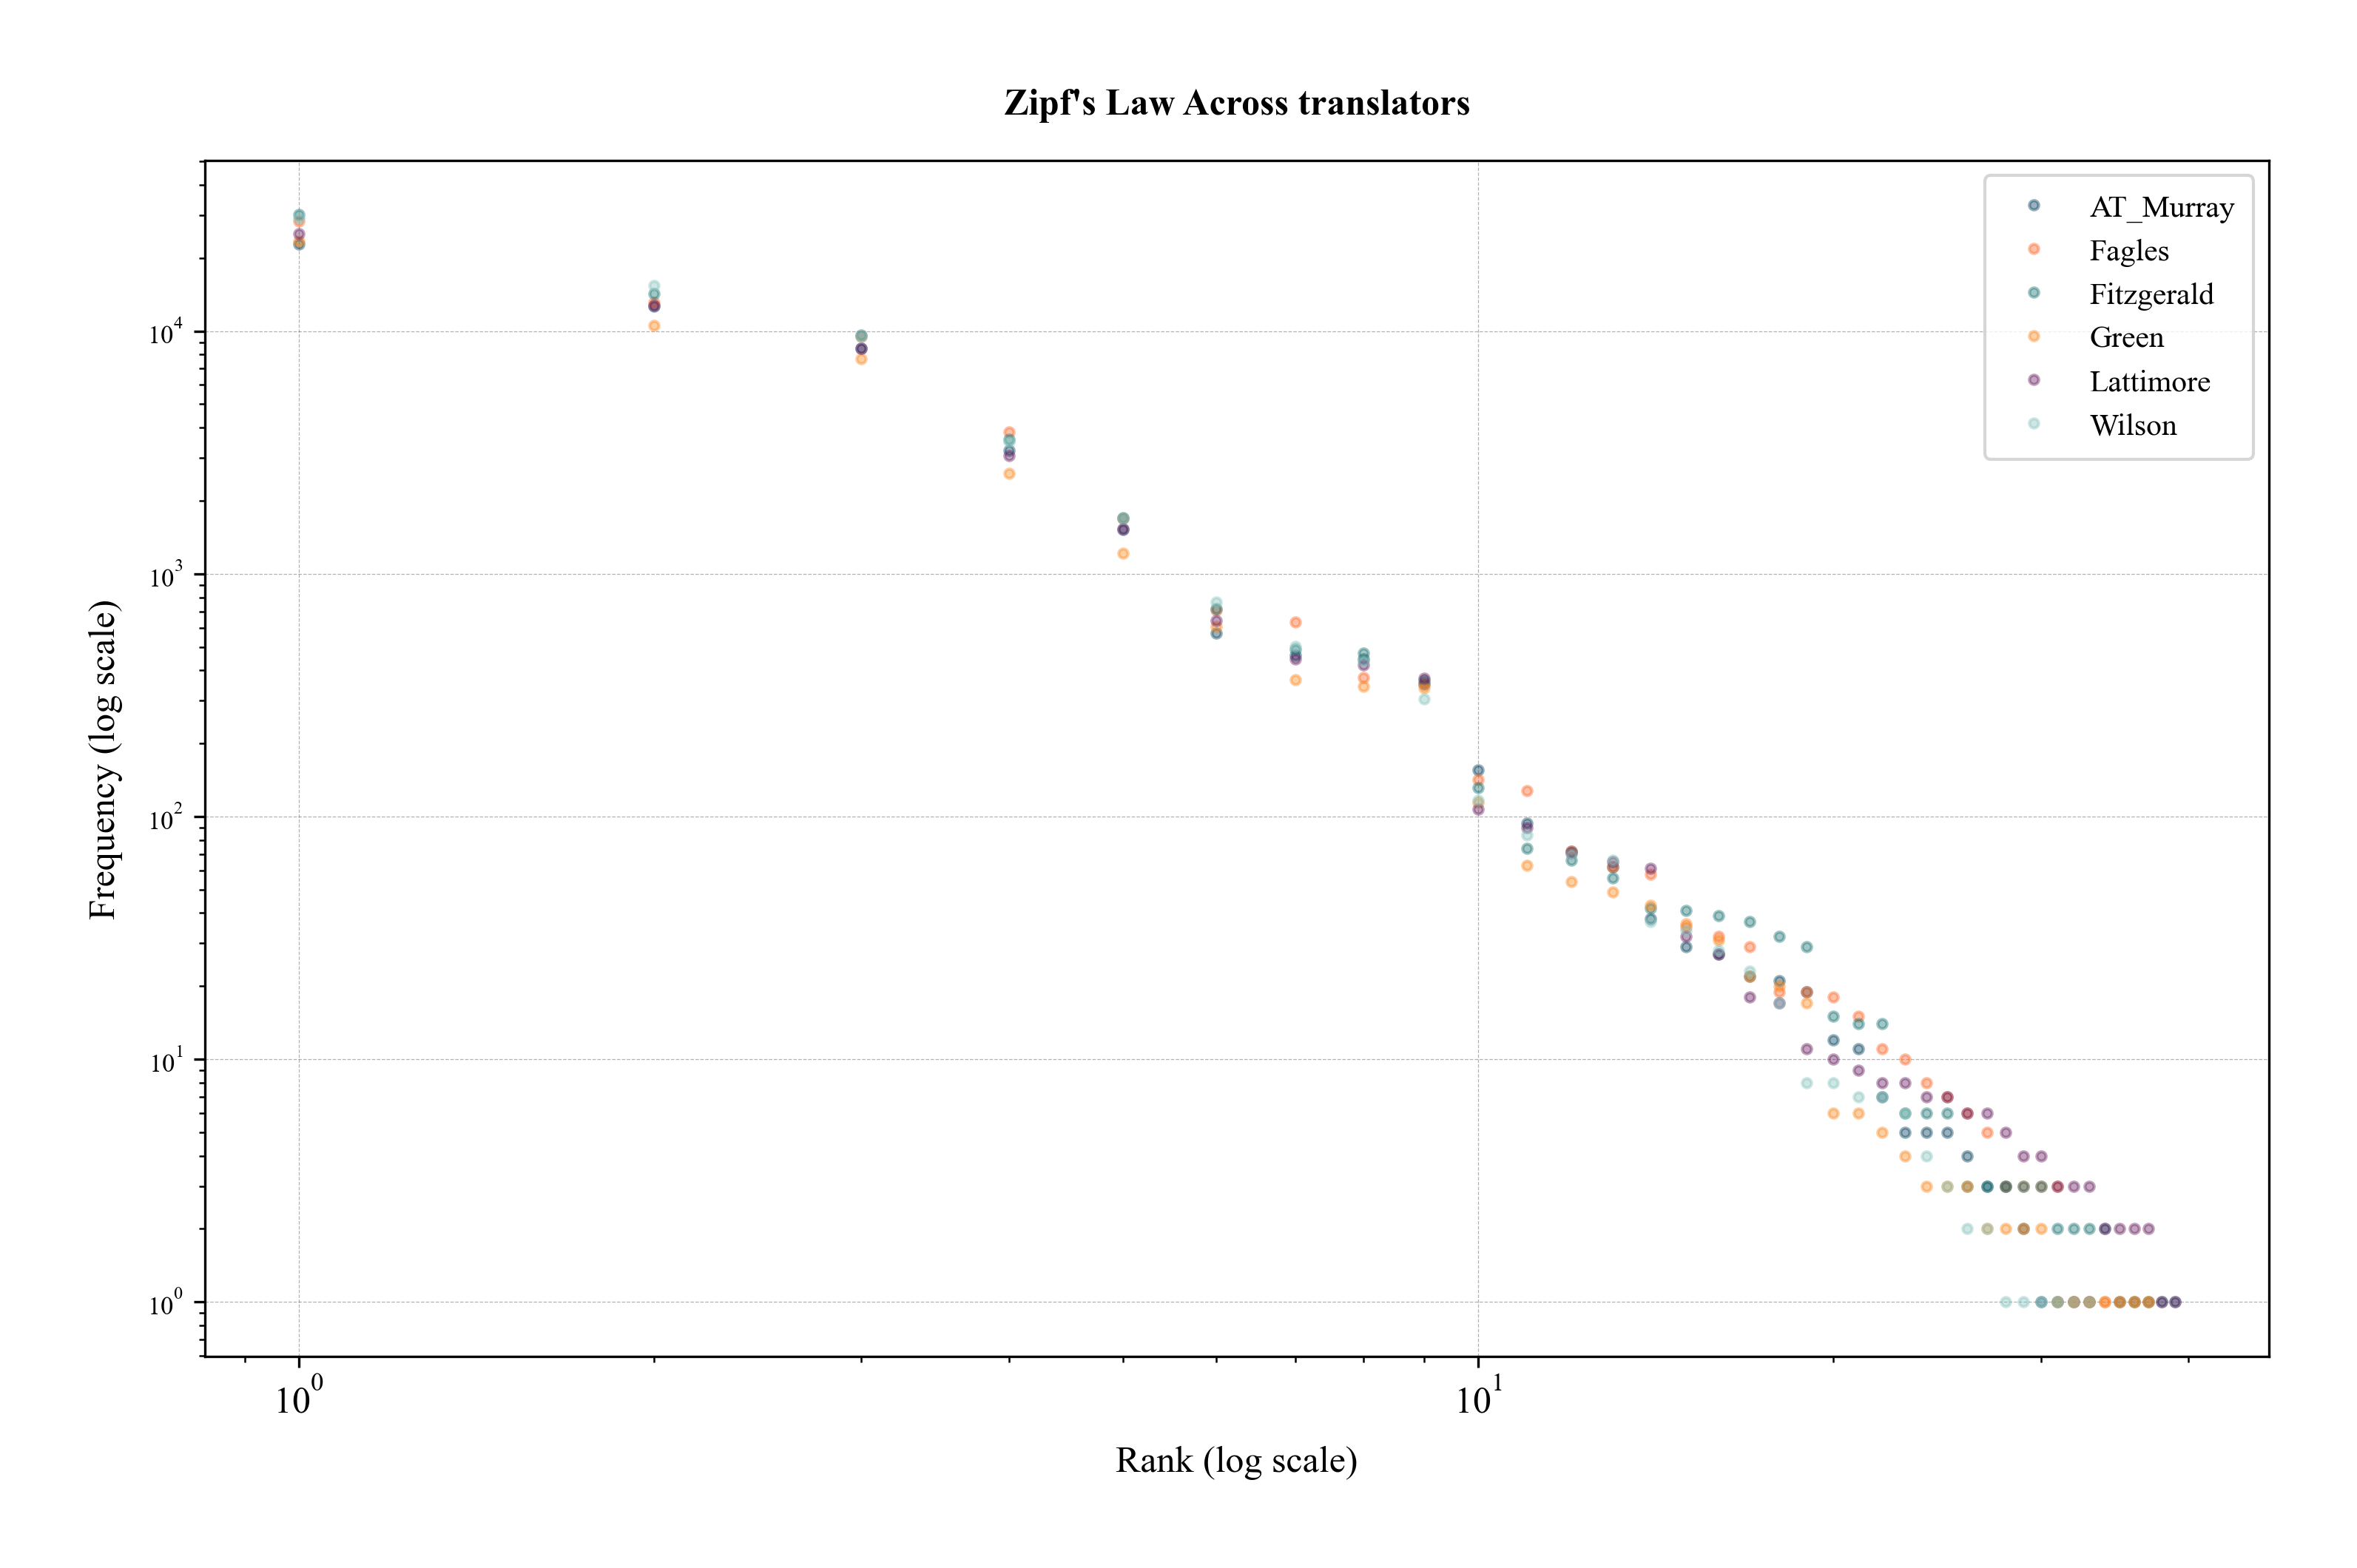

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def process_and_plot_zipfs_law(odysseys_df):
    """
    Processes the 'ety_label_counts' column to extract word frequencies,
    computes Zipf's Law distribution, and plots it.
    """
    translator_groups = odysseys_df.groupby("translator")  # Grouping by translator if an "translator" column exists
    word_freq_rank_dict = {}

    for translator, group in translator_groups:
        combined_counts = {}

        # Aggregate word frequencies across books for this translator
        for counts_dict in group["ety_label_counts"]:
            for word, count in counts_dict.items():
                combined_counts[word] = combined_counts.get(word, 0) + count

        # Convert to sorted DataFrame (descending frequency)
        df_zipf = pd.DataFrame(
            sorted(combined_counts.items(), key=lambda x: x[1], reverse=True),
            columns=["word", "frequency"]
        )
        df_zipf["rank"] = np.arange(1, len(df_zipf) + 1)
        word_freq_rank_dict[translator] = df_zipf

    # Plot the results
    for translator, df_zipf in word_freq_rank_dict.items():
        plt.loglog(df_zipf["rank"], df_zipf["frequency"], label=translator, marker=".", linestyle="None", alpha=0.4)

    plt.xlabel("Rank (log scale)")
    plt.ylabel("Frequency (log scale)")
    plt.title("Zipf's Law Across translators")
    plt.legend()
    plt.grid(True, linestyle="--", linewidth=0.3, alpha=0.3)
    plt.show()

# Example usage:
process_and_plot_zipfs_law(odysseys_df)

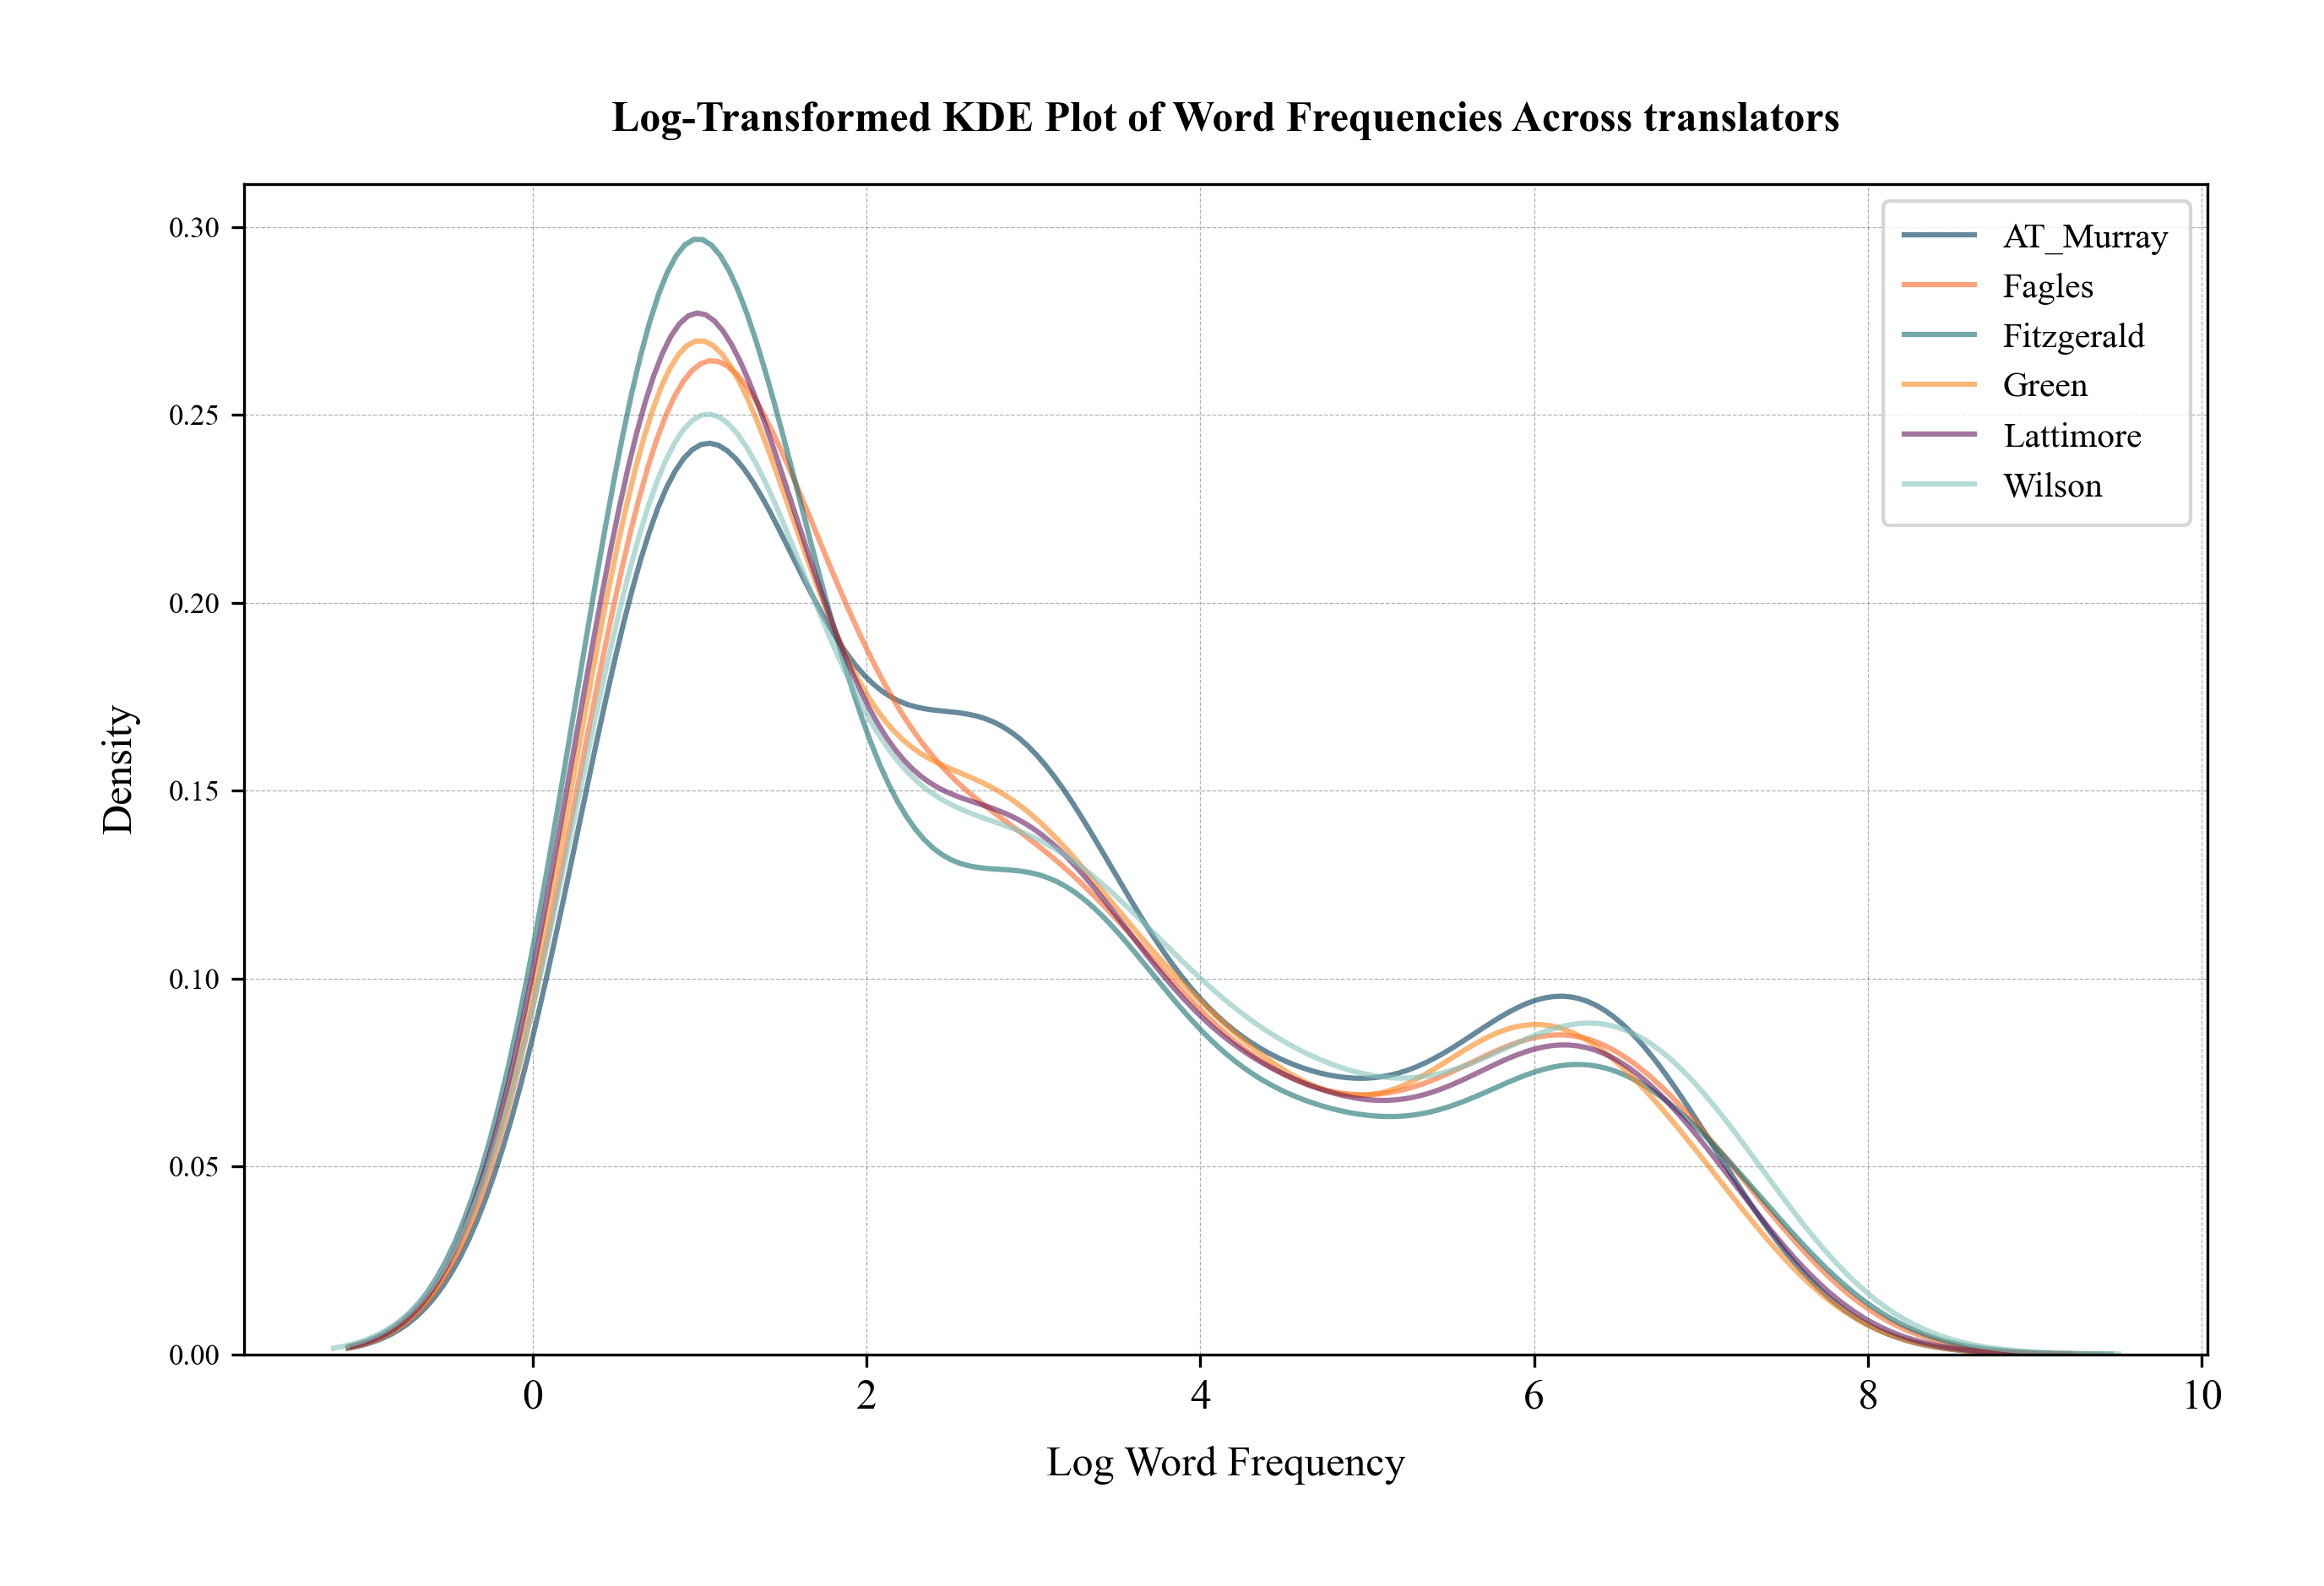

In [7]:

def plot_kde_word_frequencies(df):
    """
    Processes the 'ety_label_counts' column to extract word frequencies,
    and plots their distribution using a KDE plot.
    """
    translator_groups = df.groupby("translator")  # Grouping by translator
    plt.figure(figsize=(10, 6))

    for translator, group in translator_groups:
        all_frequencies = []

        # Aggregate word frequencies across books for this translator
        for counts_dict in group["ety_label_counts"]:
            all_frequencies.extend(counts_dict.values())  # Collect all word frequencies

        # Plot KDE if there are enough points
        if len(all_frequencies) > 1:
            sns.kdeplot(all_frequencies, label=translator, fill=True, alpha=0.4)

    plt.xlabel("Word Frequency")
    plt.ylabel("Density")
    plt.title("KDE Plot of Word Frequencies Across translators")
    plt.legend()
    plt.grid(True, linestyle="--", linewidth=0.3, alpha=0.3)
    plt.show()


def plot_log_kde_word_frequencies(df):
    translator_groups = df.groupby("translator")
    plt.figure(figsize=(10, 6))

    for translator, group in translator_groups:
        all_frequencies = []

        for counts_dict in group["ety_label_counts"]:
            all_frequencies.extend(counts_dict.values())

        # Log-transform (avoid log(0) errors)
        log_frequencies = np.log1p(all_frequencies)  # log(1 + x) to handle zero values safely

        if len(log_frequencies) > 1:
            sns.kdeplot(log_frequencies, label=translator, fill=False, alpha=0.6)

    plt.xlabel("Log Word Frequency")
    plt.ylabel("Density")
    plt.title("Log-Transformed KDE Plot of Word Frequencies Across translators")
    plt.legend()
    plt.grid(True, linestyle="--", linewidth=0.3, alpha=0.3)
    plt.show()
# Example usage:
plot_log_kde_word_frequencies(odysseys_df)

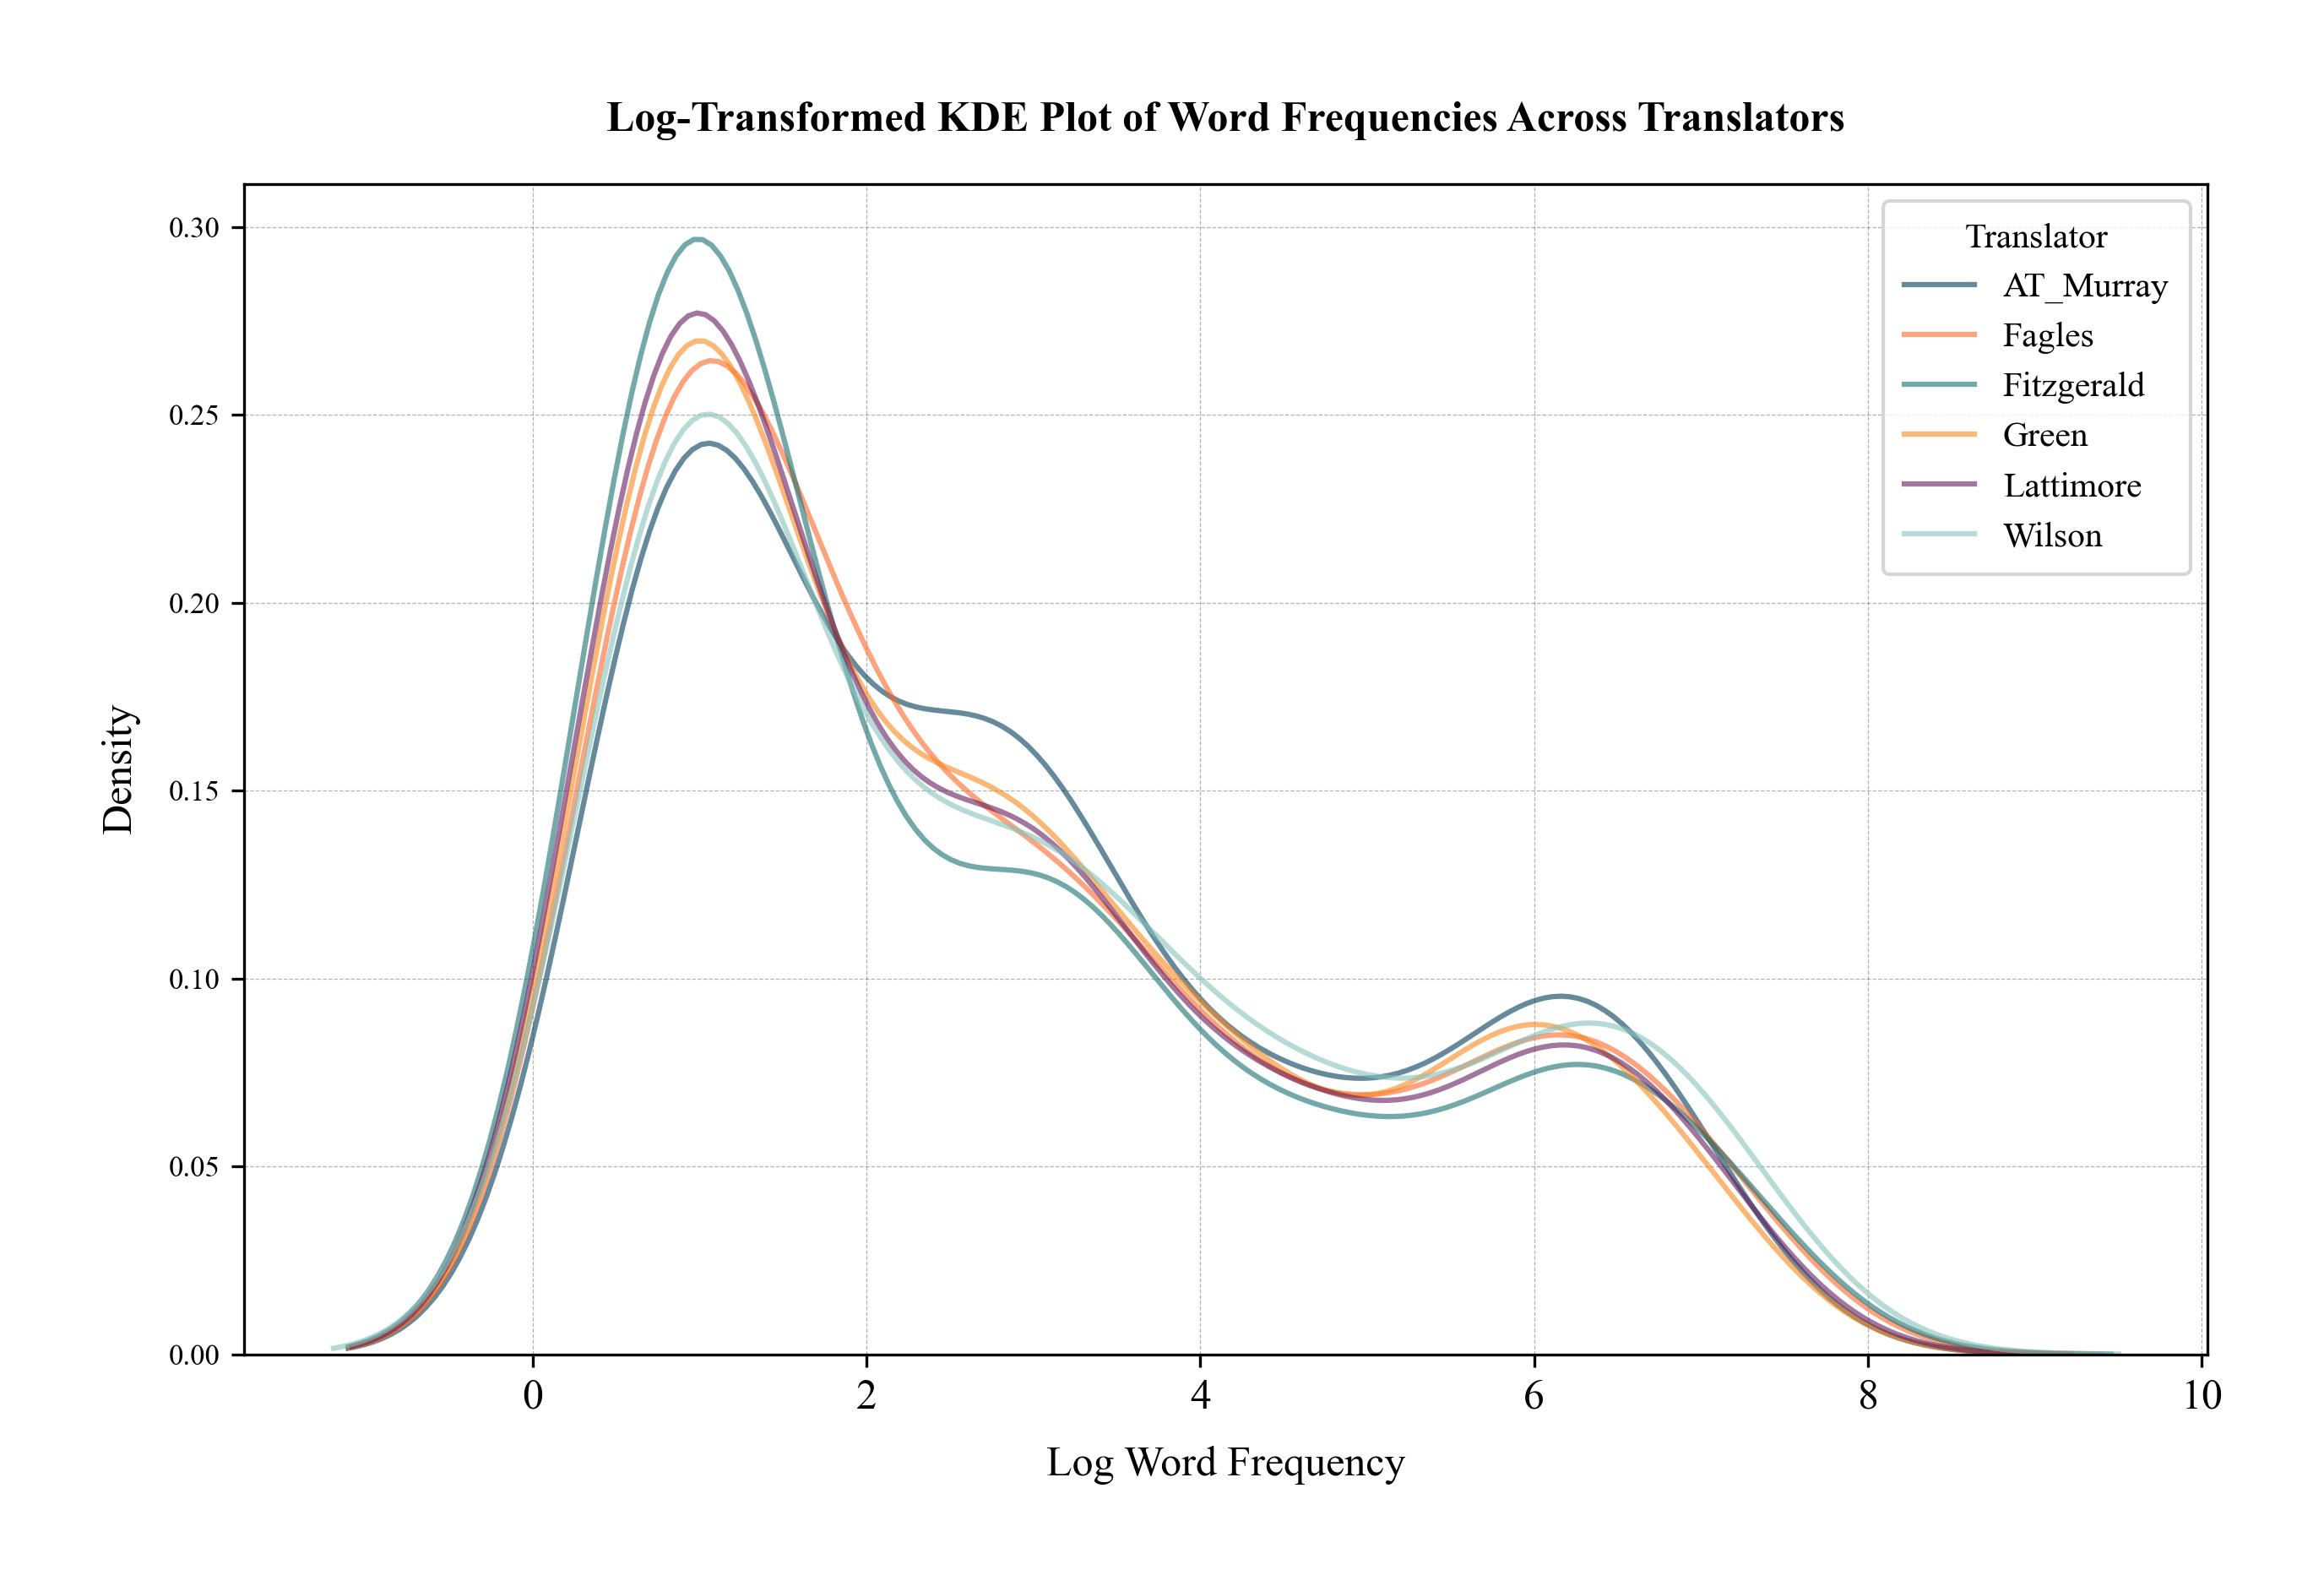


Translator: AT_Murray
  Shapiro-Wilk p-value: p = 0.00000
  Kolmogorov-Smirnov p-value: p = 0.00000
  D'Agostino K^2 p-value: p = 0.00000

Translator: Fagles
  Shapiro-Wilk p-value: p = 0.00000
  Kolmogorov-Smirnov p-value: p = 0.00000
  D'Agostino K^2 p-value: p = 0.00000

Translator: Fitzgerald
  Shapiro-Wilk p-value: p = 0.00000
  Kolmogorov-Smirnov p-value: p = 0.00000
  D'Agostino K^2 p-value: p = 0.00000

Translator: Green
  Shapiro-Wilk p-value: p = 0.00000
  Kolmogorov-Smirnov p-value: p = 0.00000
  D'Agostino K^2 p-value: p = 0.00000

Translator: Lattimore
  Shapiro-Wilk p-value: p = 0.00000
  Kolmogorov-Smirnov p-value: p = 0.00000
  D'Agostino K^2 p-value: p = 0.00000

Translator: Wilson
  Shapiro-Wilk p-value: p = 0.00000
  Kolmogorov-Smirnov p-value: p = 0.00000
  D'Agostino K^2 p-value: p = 0.00000


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import shapiro, kstest, normaltest

def analyze_word_frequencies(odysseys_df):
    translator_groups = odysseys_df.groupby("translator")
    
    plt.figure(figsize=(10, 6))
    results = {}

    for translator, group in translator_groups:
        all_frequencies = []

        for counts_dict in group["ety_label_counts"]:
            all_frequencies.extend(counts_dict.values())

        # Convert to numpy array
        all_frequencies = np.array(all_frequencies)
        all_frequencies = all_frequencies[all_frequencies > 0]  # Remove zero values

        if len(all_frequencies) > 10:  # Ensure enough data points
            log_frequencies = np.log1p(all_frequencies)  # Log transform

            # KDE Plot
            sns.kdeplot(log_frequencies, fill=False, alpha=0.6, label=translator)

            # Statistical Normality Tests
            shapiro_test = shapiro(log_frequencies)  # Shapiro-Wilk Test
            ks_test = kstest(log_frequencies, 'norm', args=(np.mean(log_frequencies), np.std(log_frequencies)))  # KS Test
            dagostino_test = normaltest(log_frequencies)  # D'Agostino K^2 Test

            results[translator] = {
                "Shapiro-Wilk p-value": shapiro_test.pvalue,
                "Kolmogorov-Smirnov p-value": ks_test.pvalue,
                "D'Agostino K^2 p-value": dagostino_test.pvalue
            }

    plt.xlabel("Log Word Frequency")
    plt.ylabel("Density")
    plt.title("Log-Transformed KDE Plot of Word Frequencies Across Translators")
    plt.legend(title="Translator")
    plt.grid(True, linestyle="--", linewidth=0.3, alpha=0.3)
    plt.show()

    # Print normality test results
    for translator, stats in results.items():
        print(f"\nTranslator: {translator}")
        for test, p_value in stats.items():
            print(f"  {test}: p = {p_value:.5f}")

# Example usage:
analyze_word_frequencies(odysseys_df)

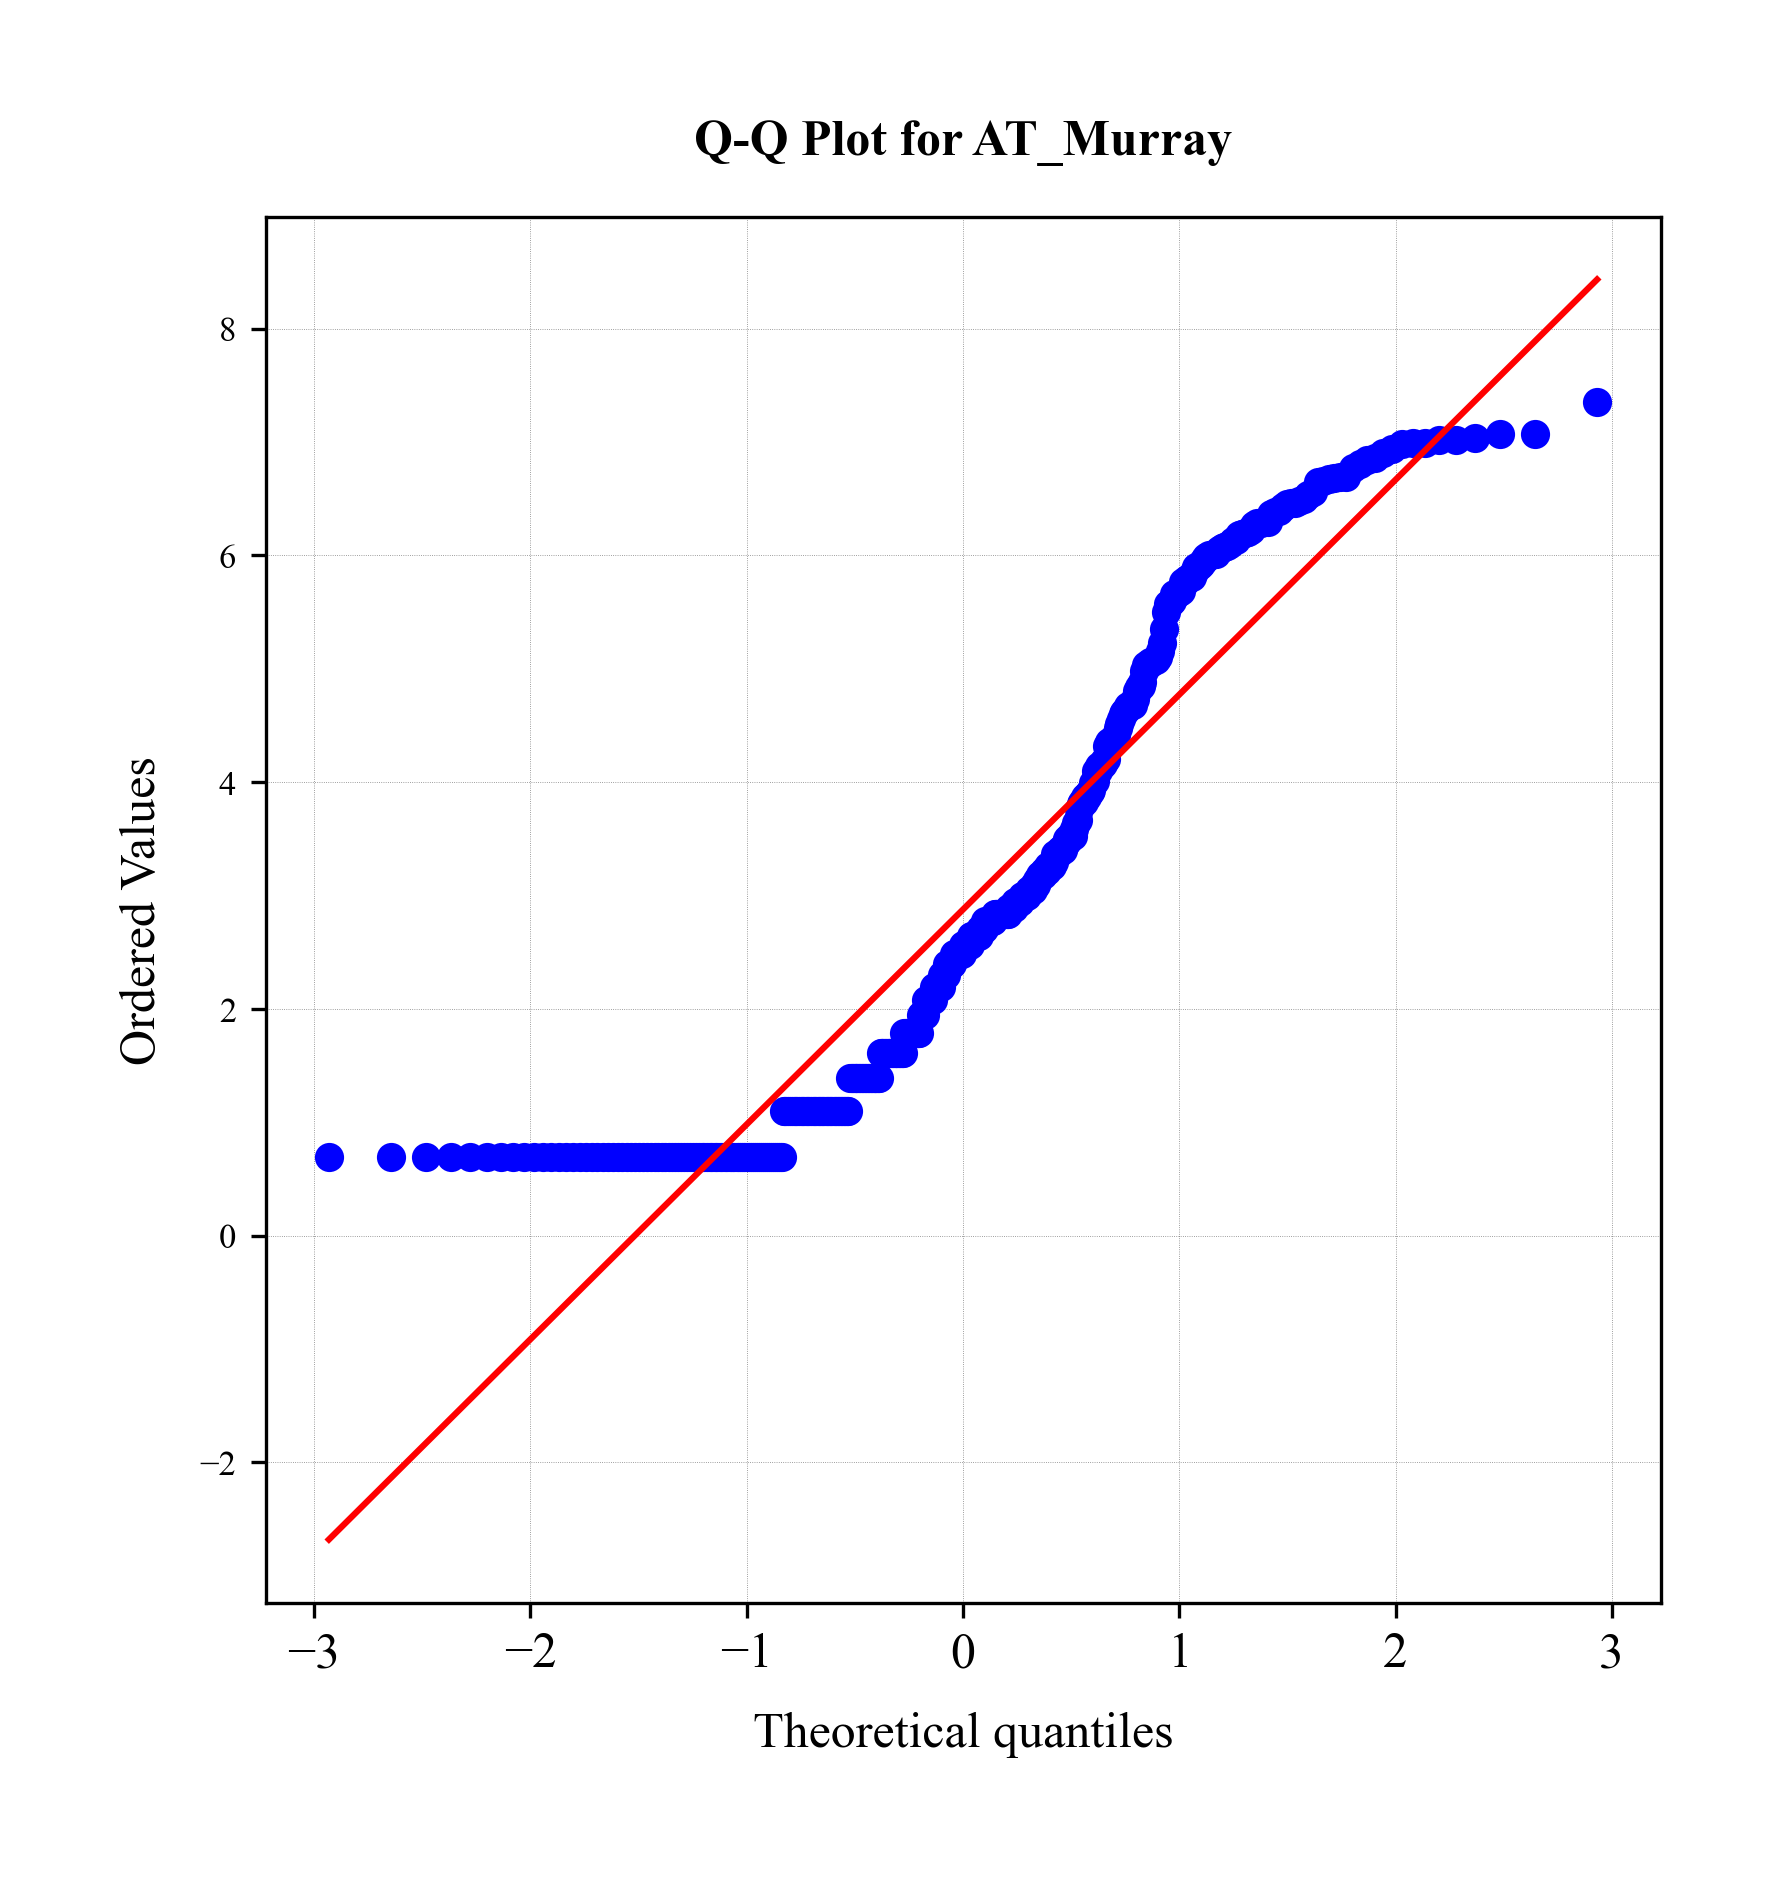

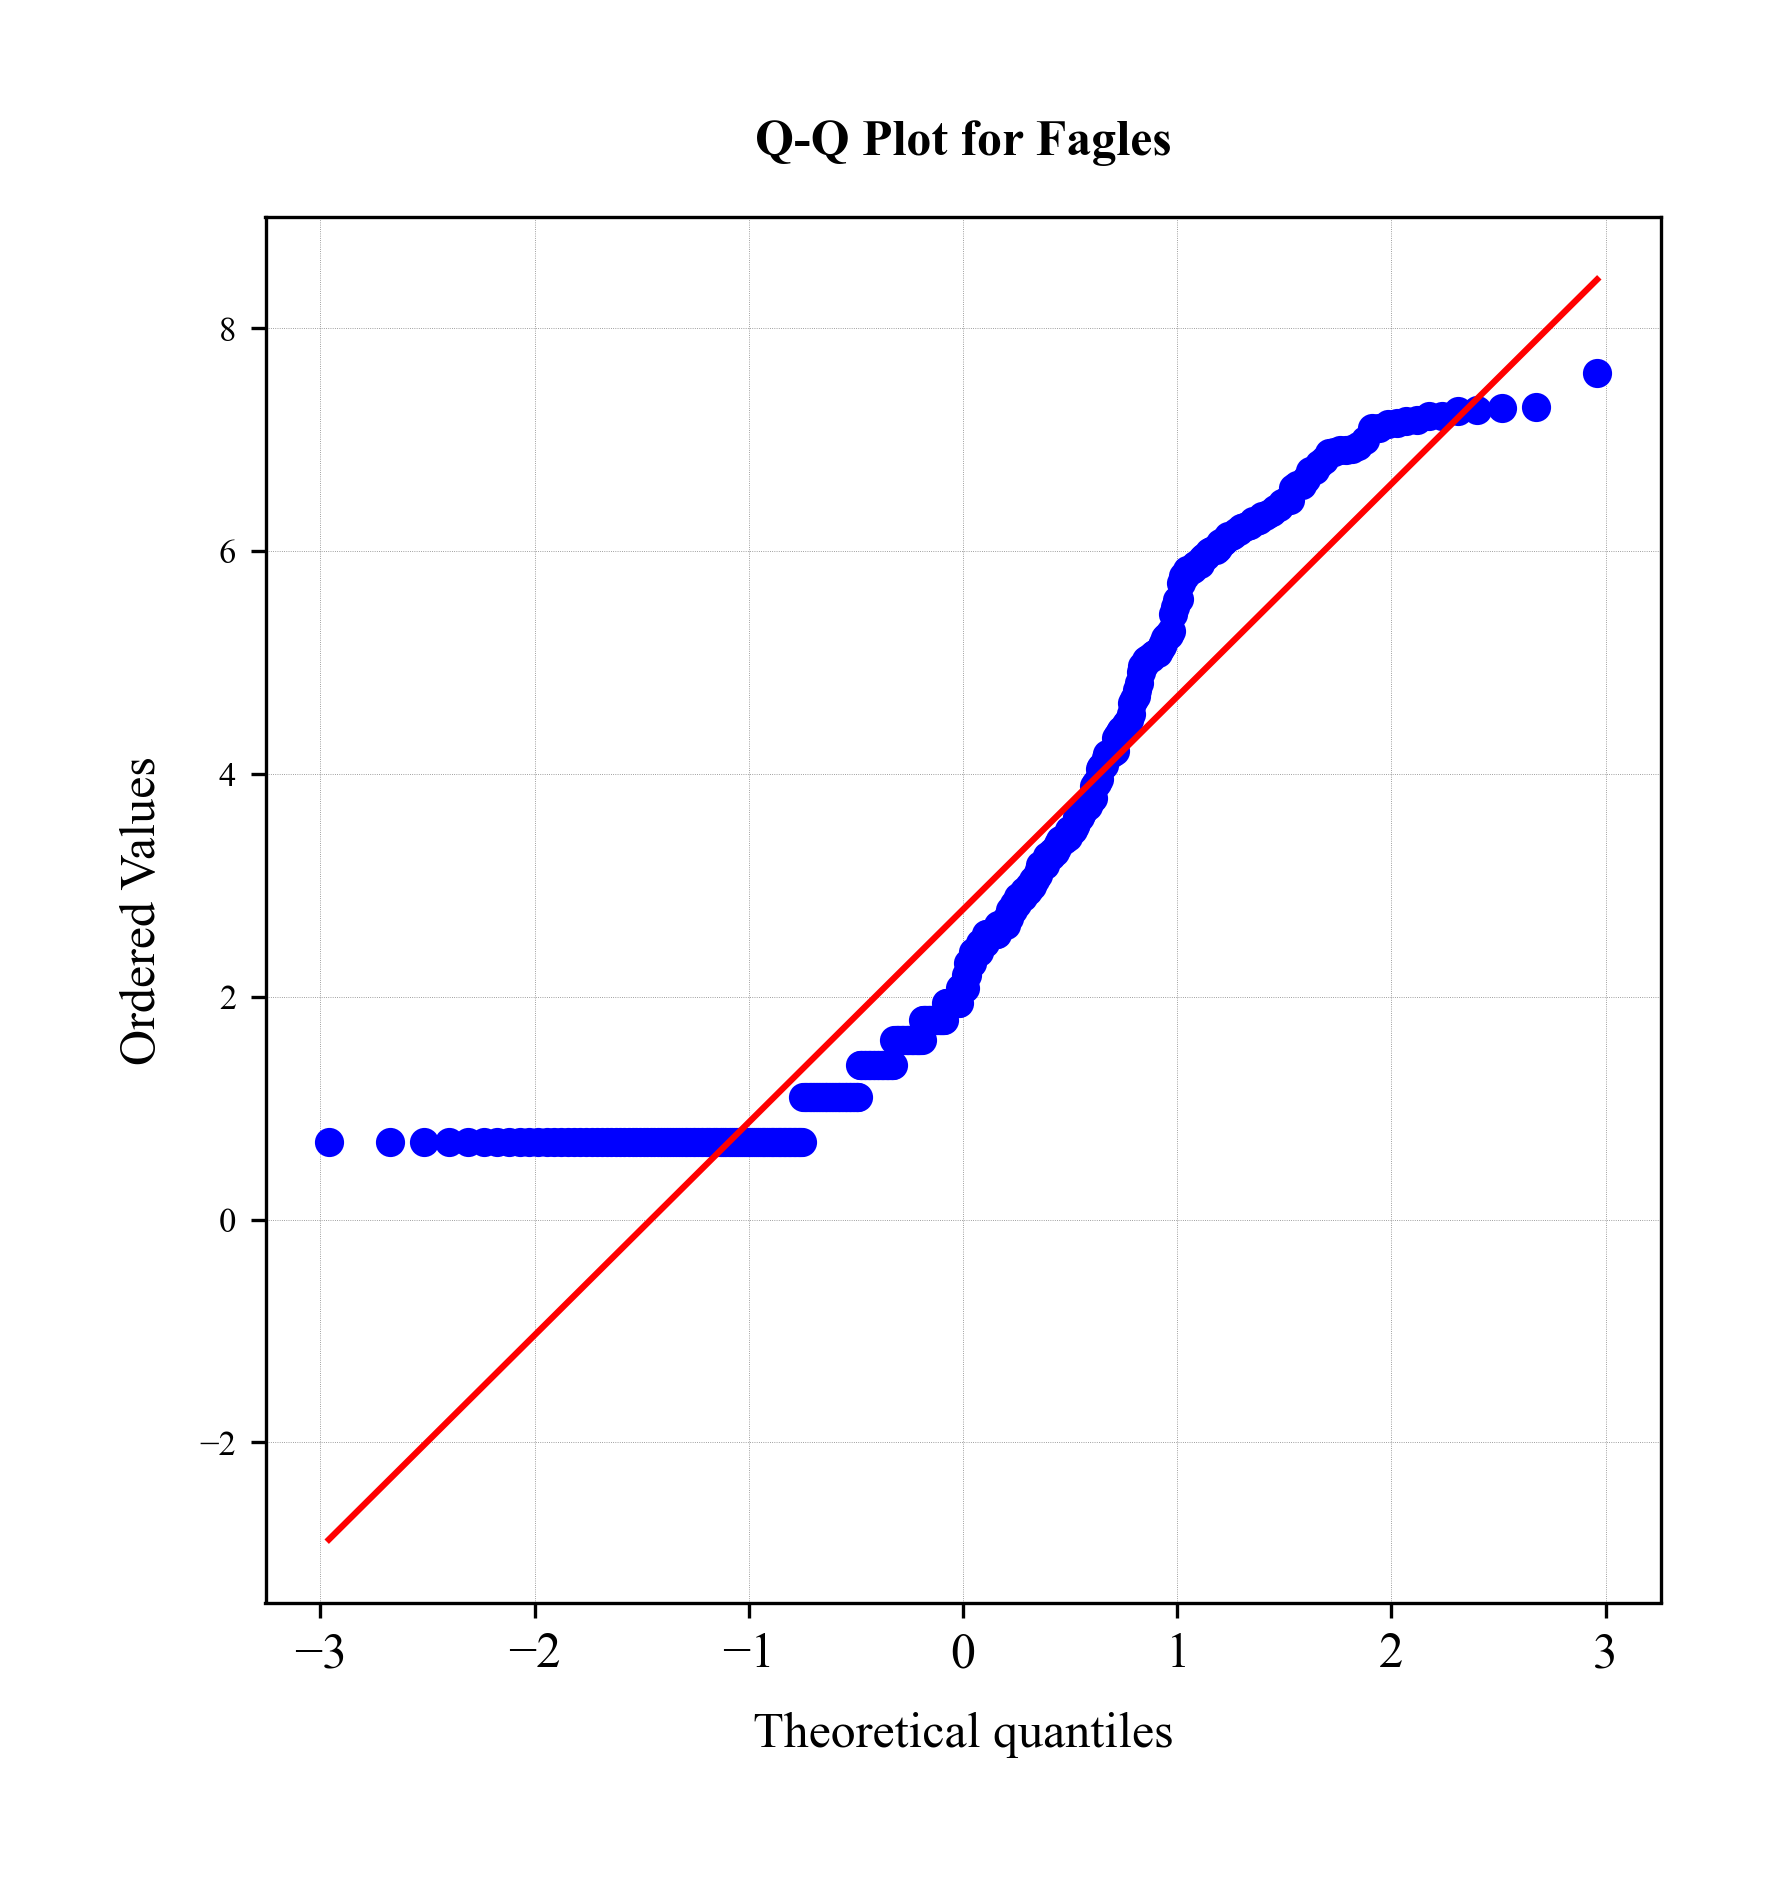

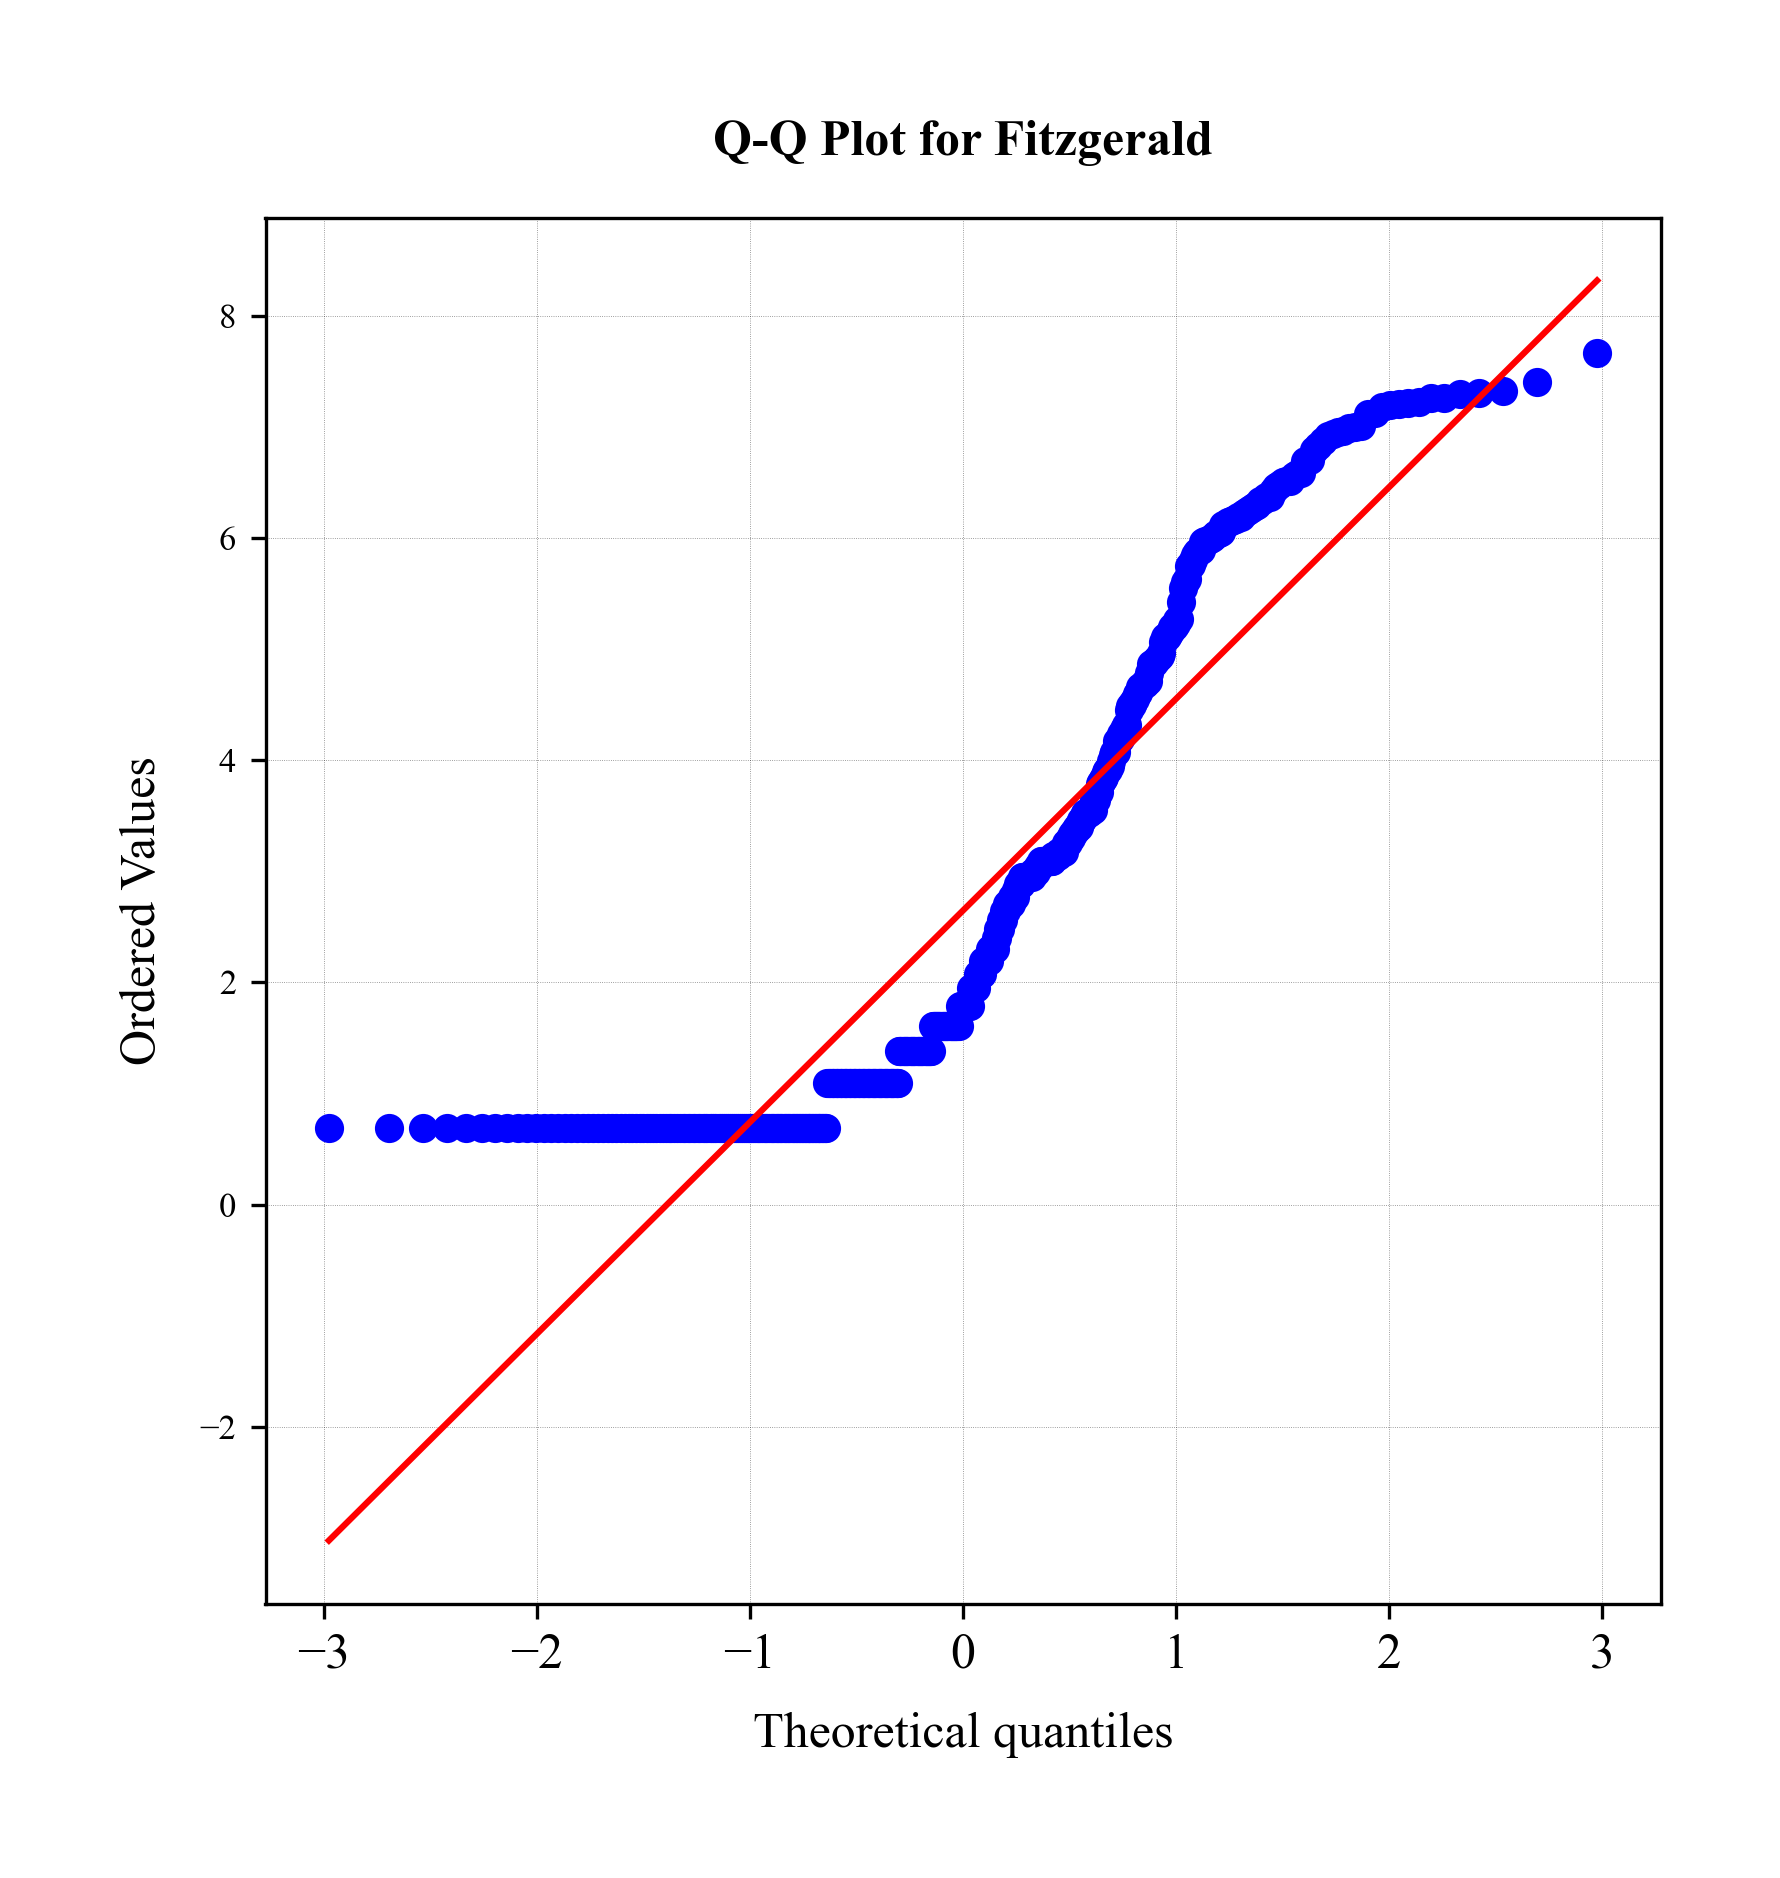

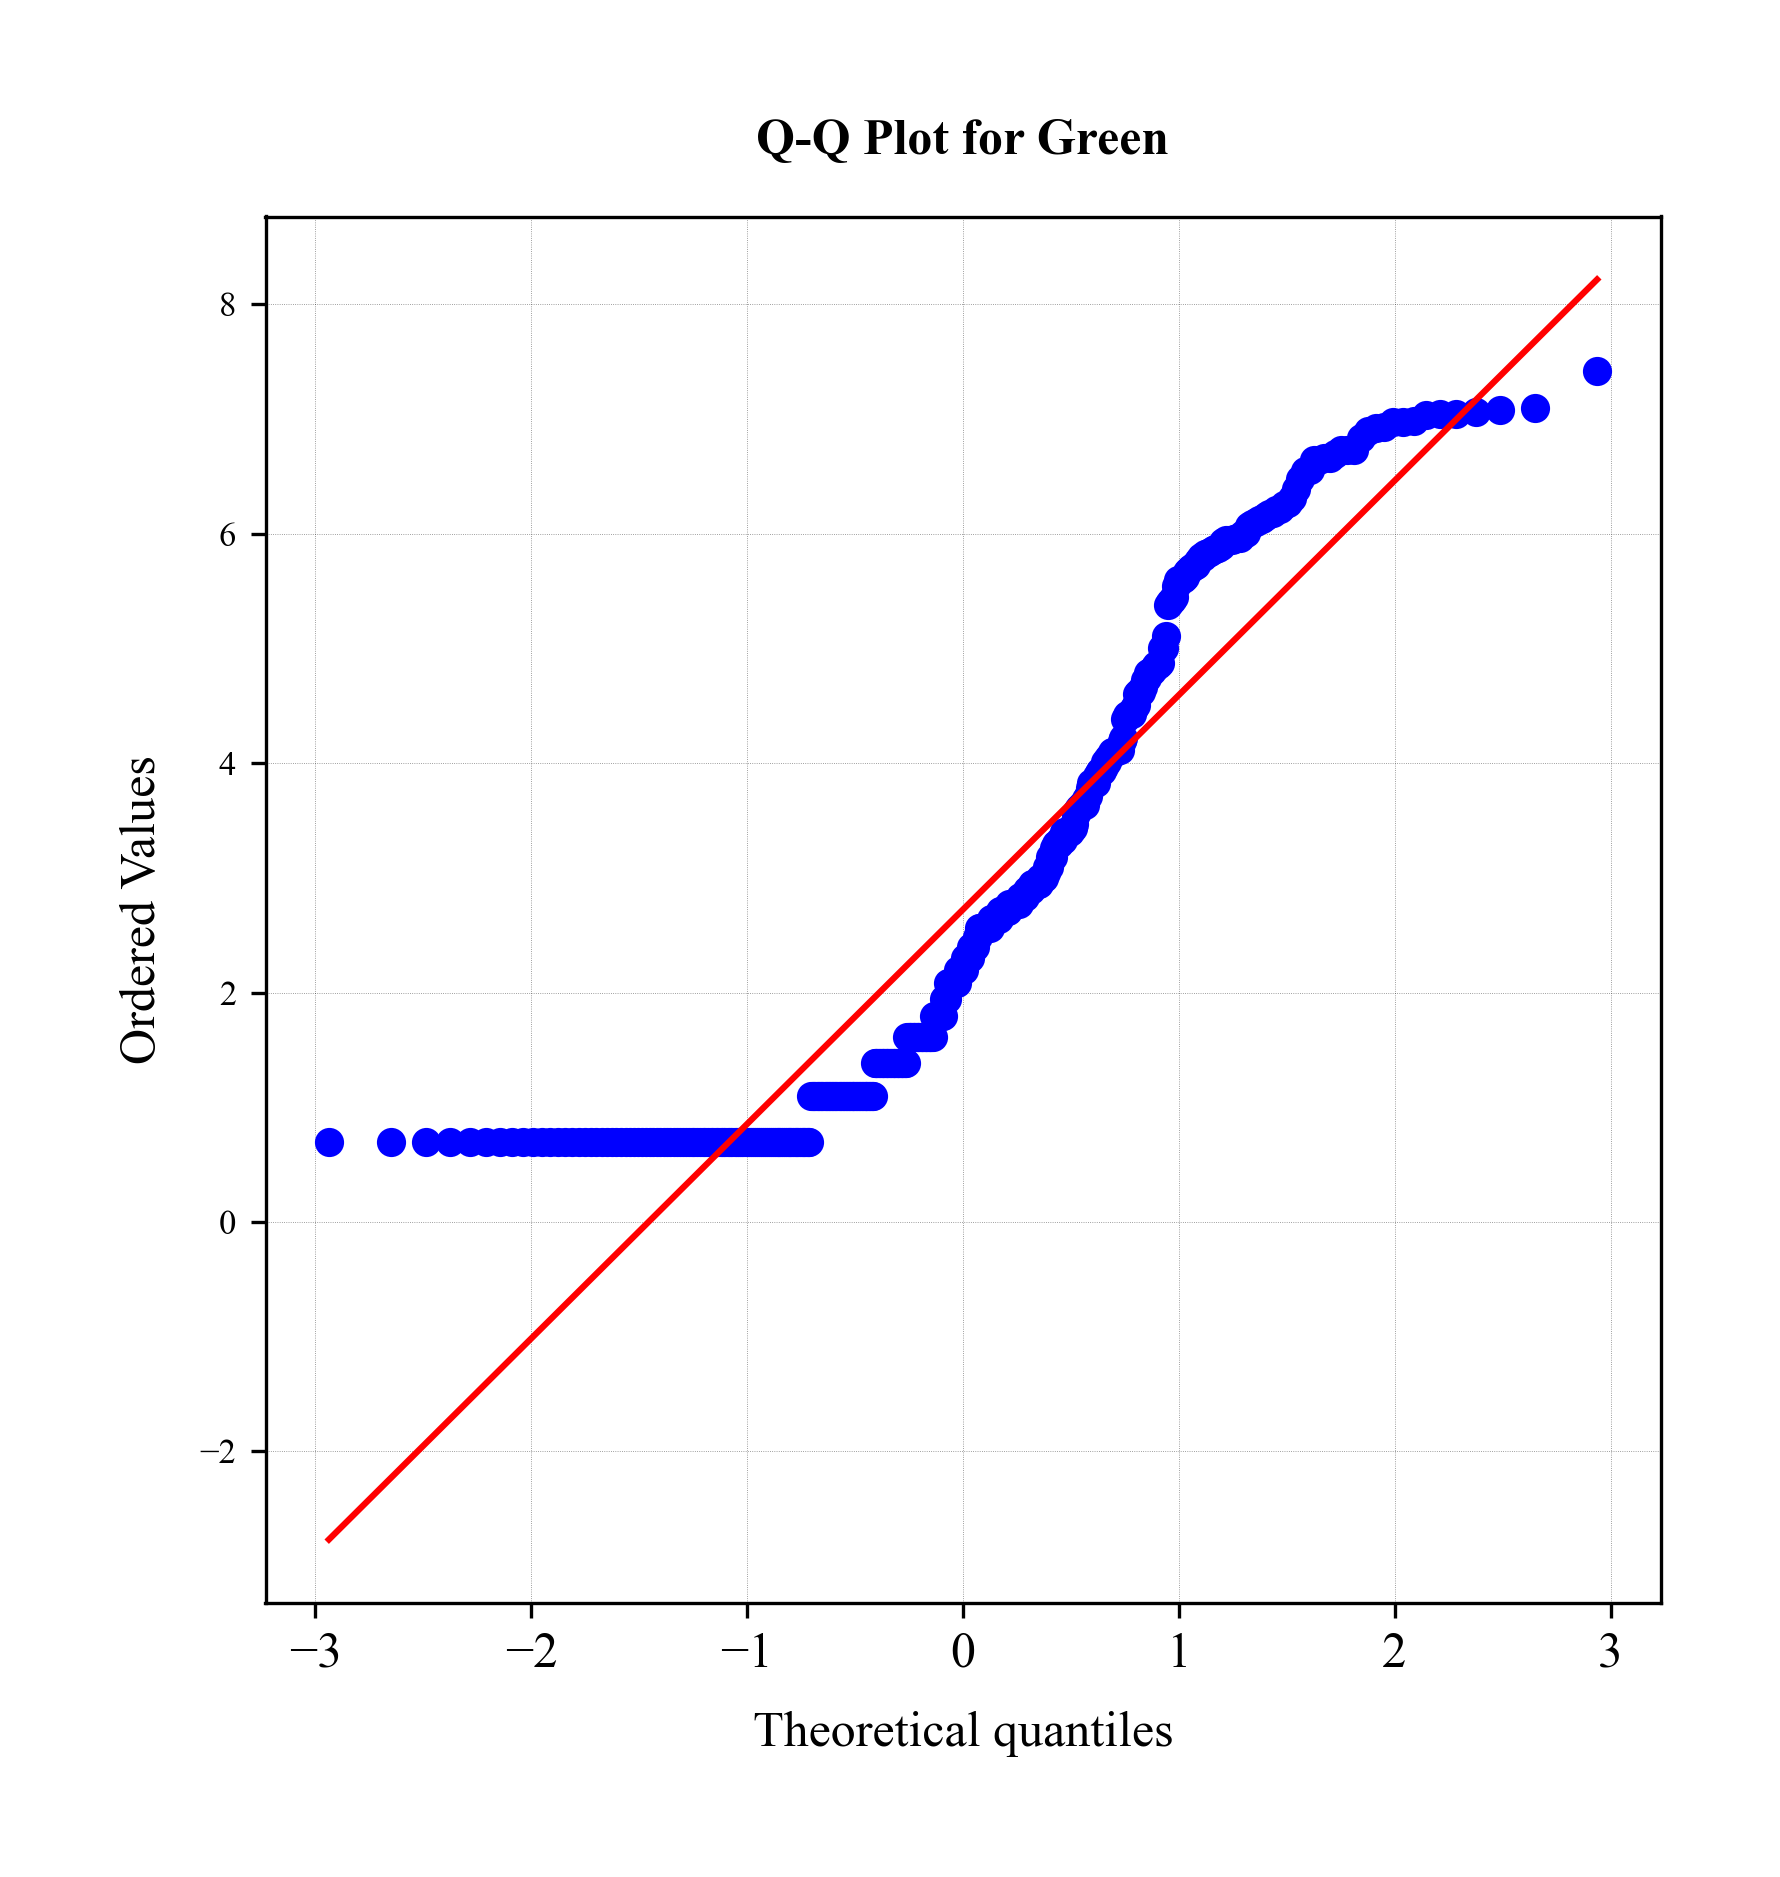

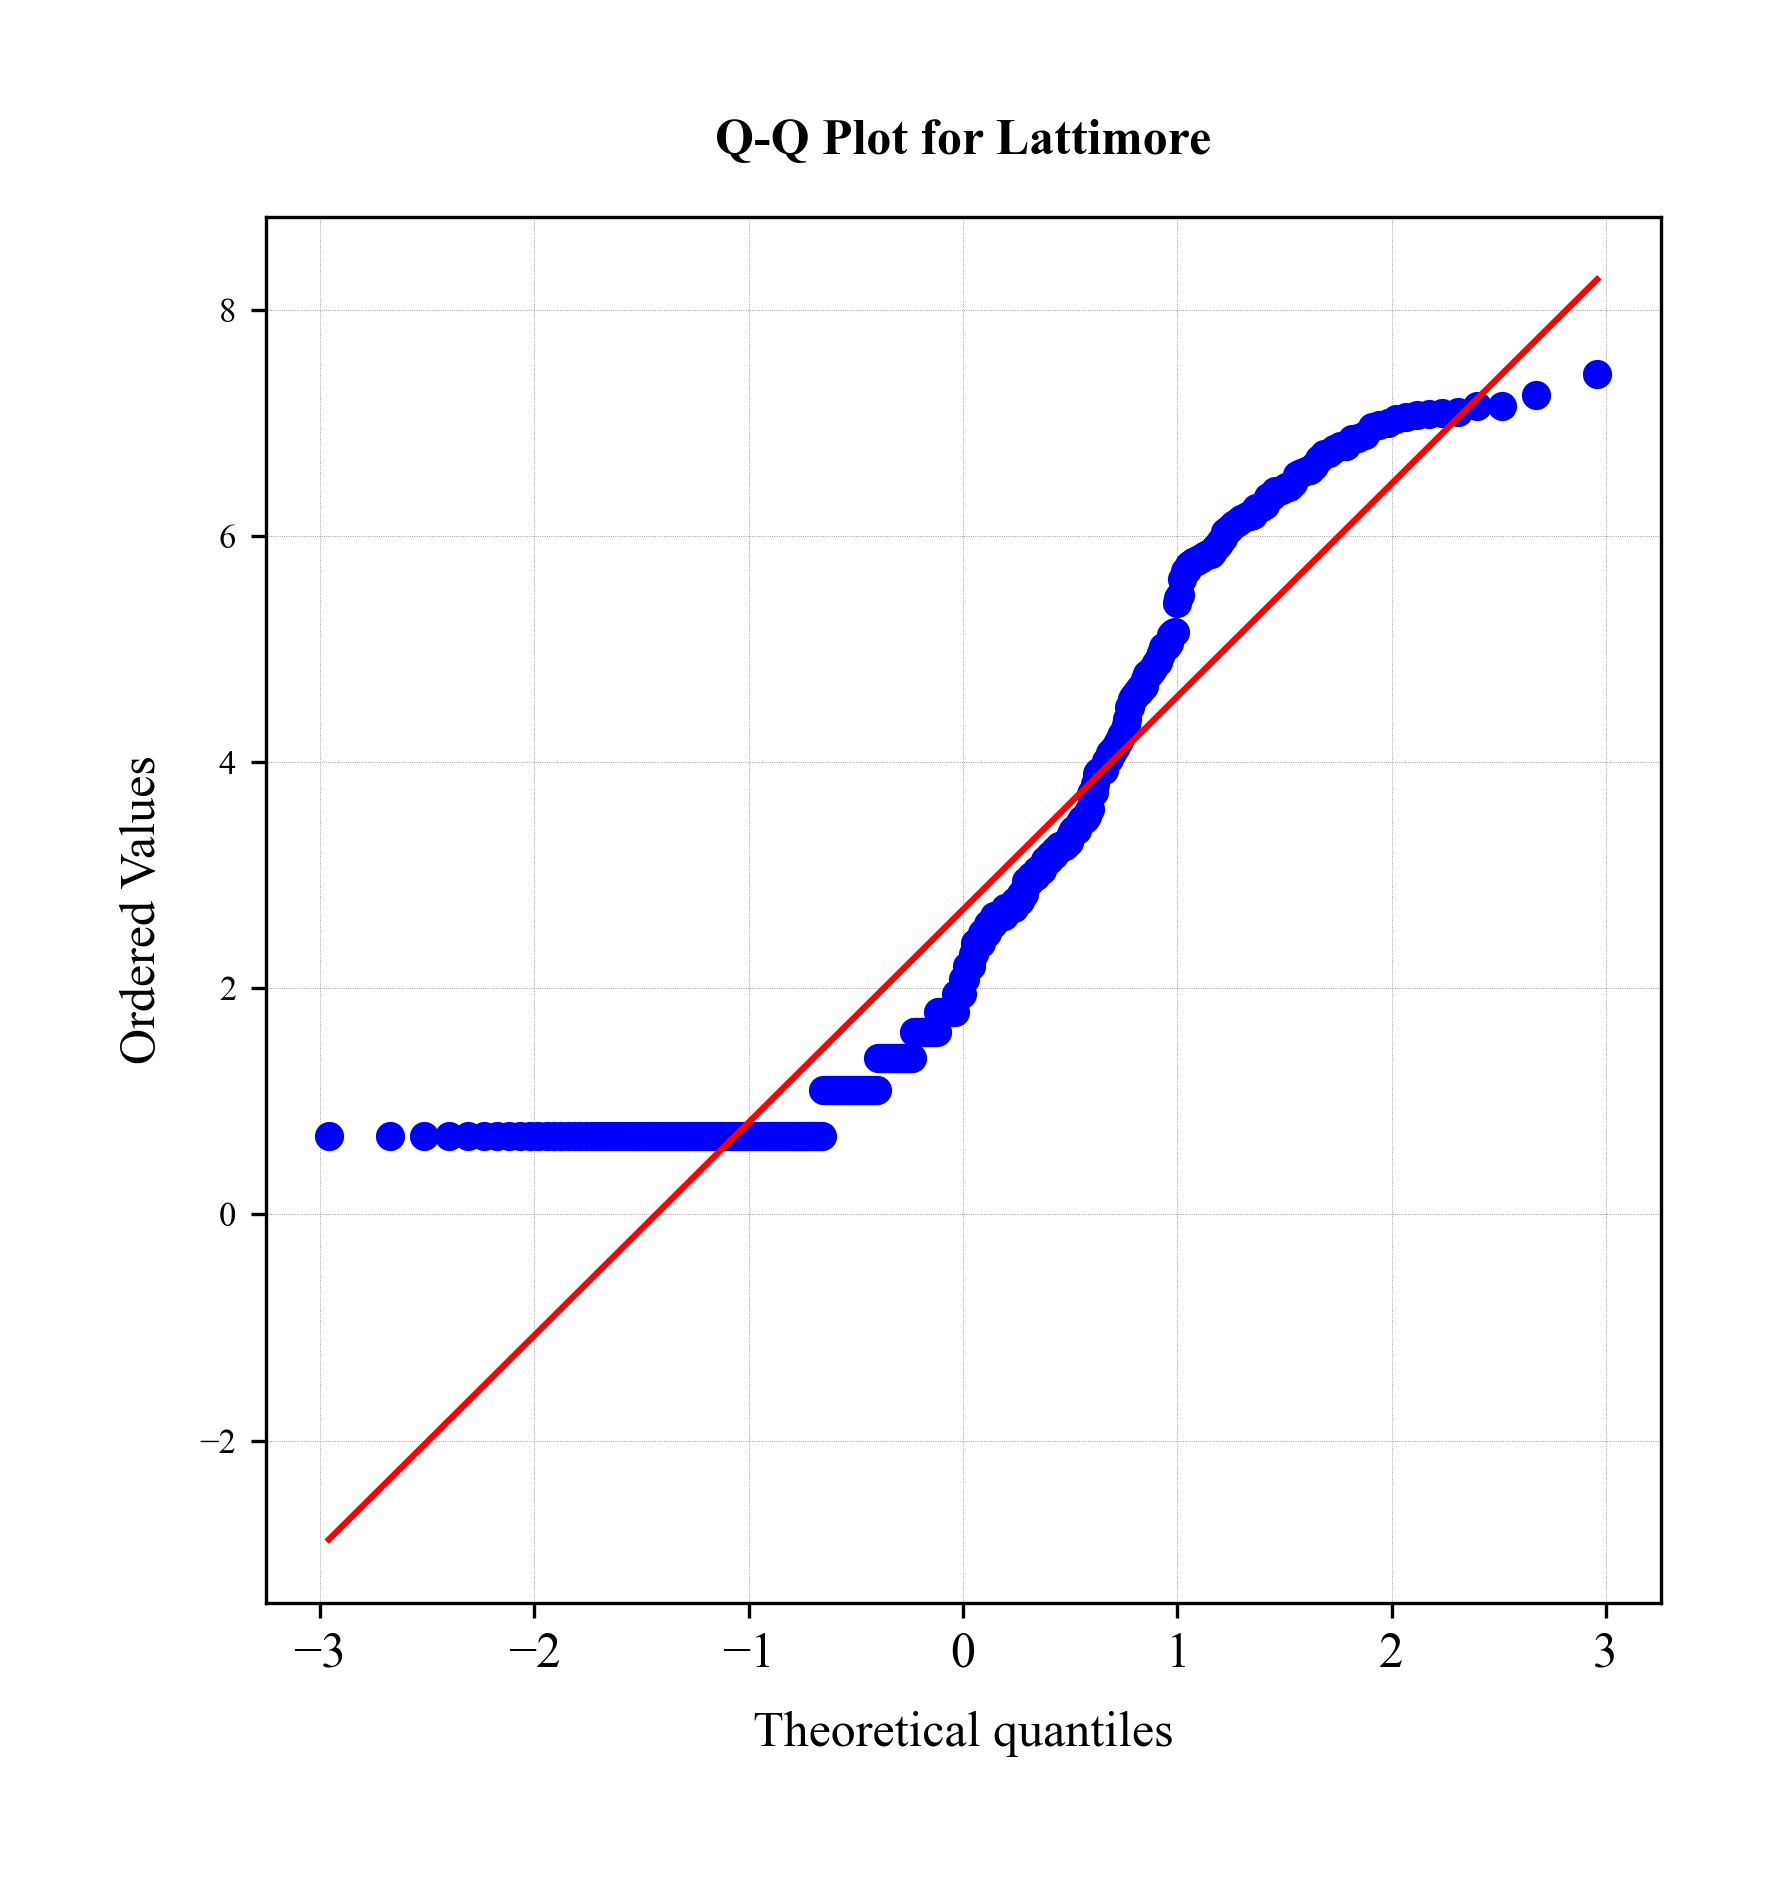

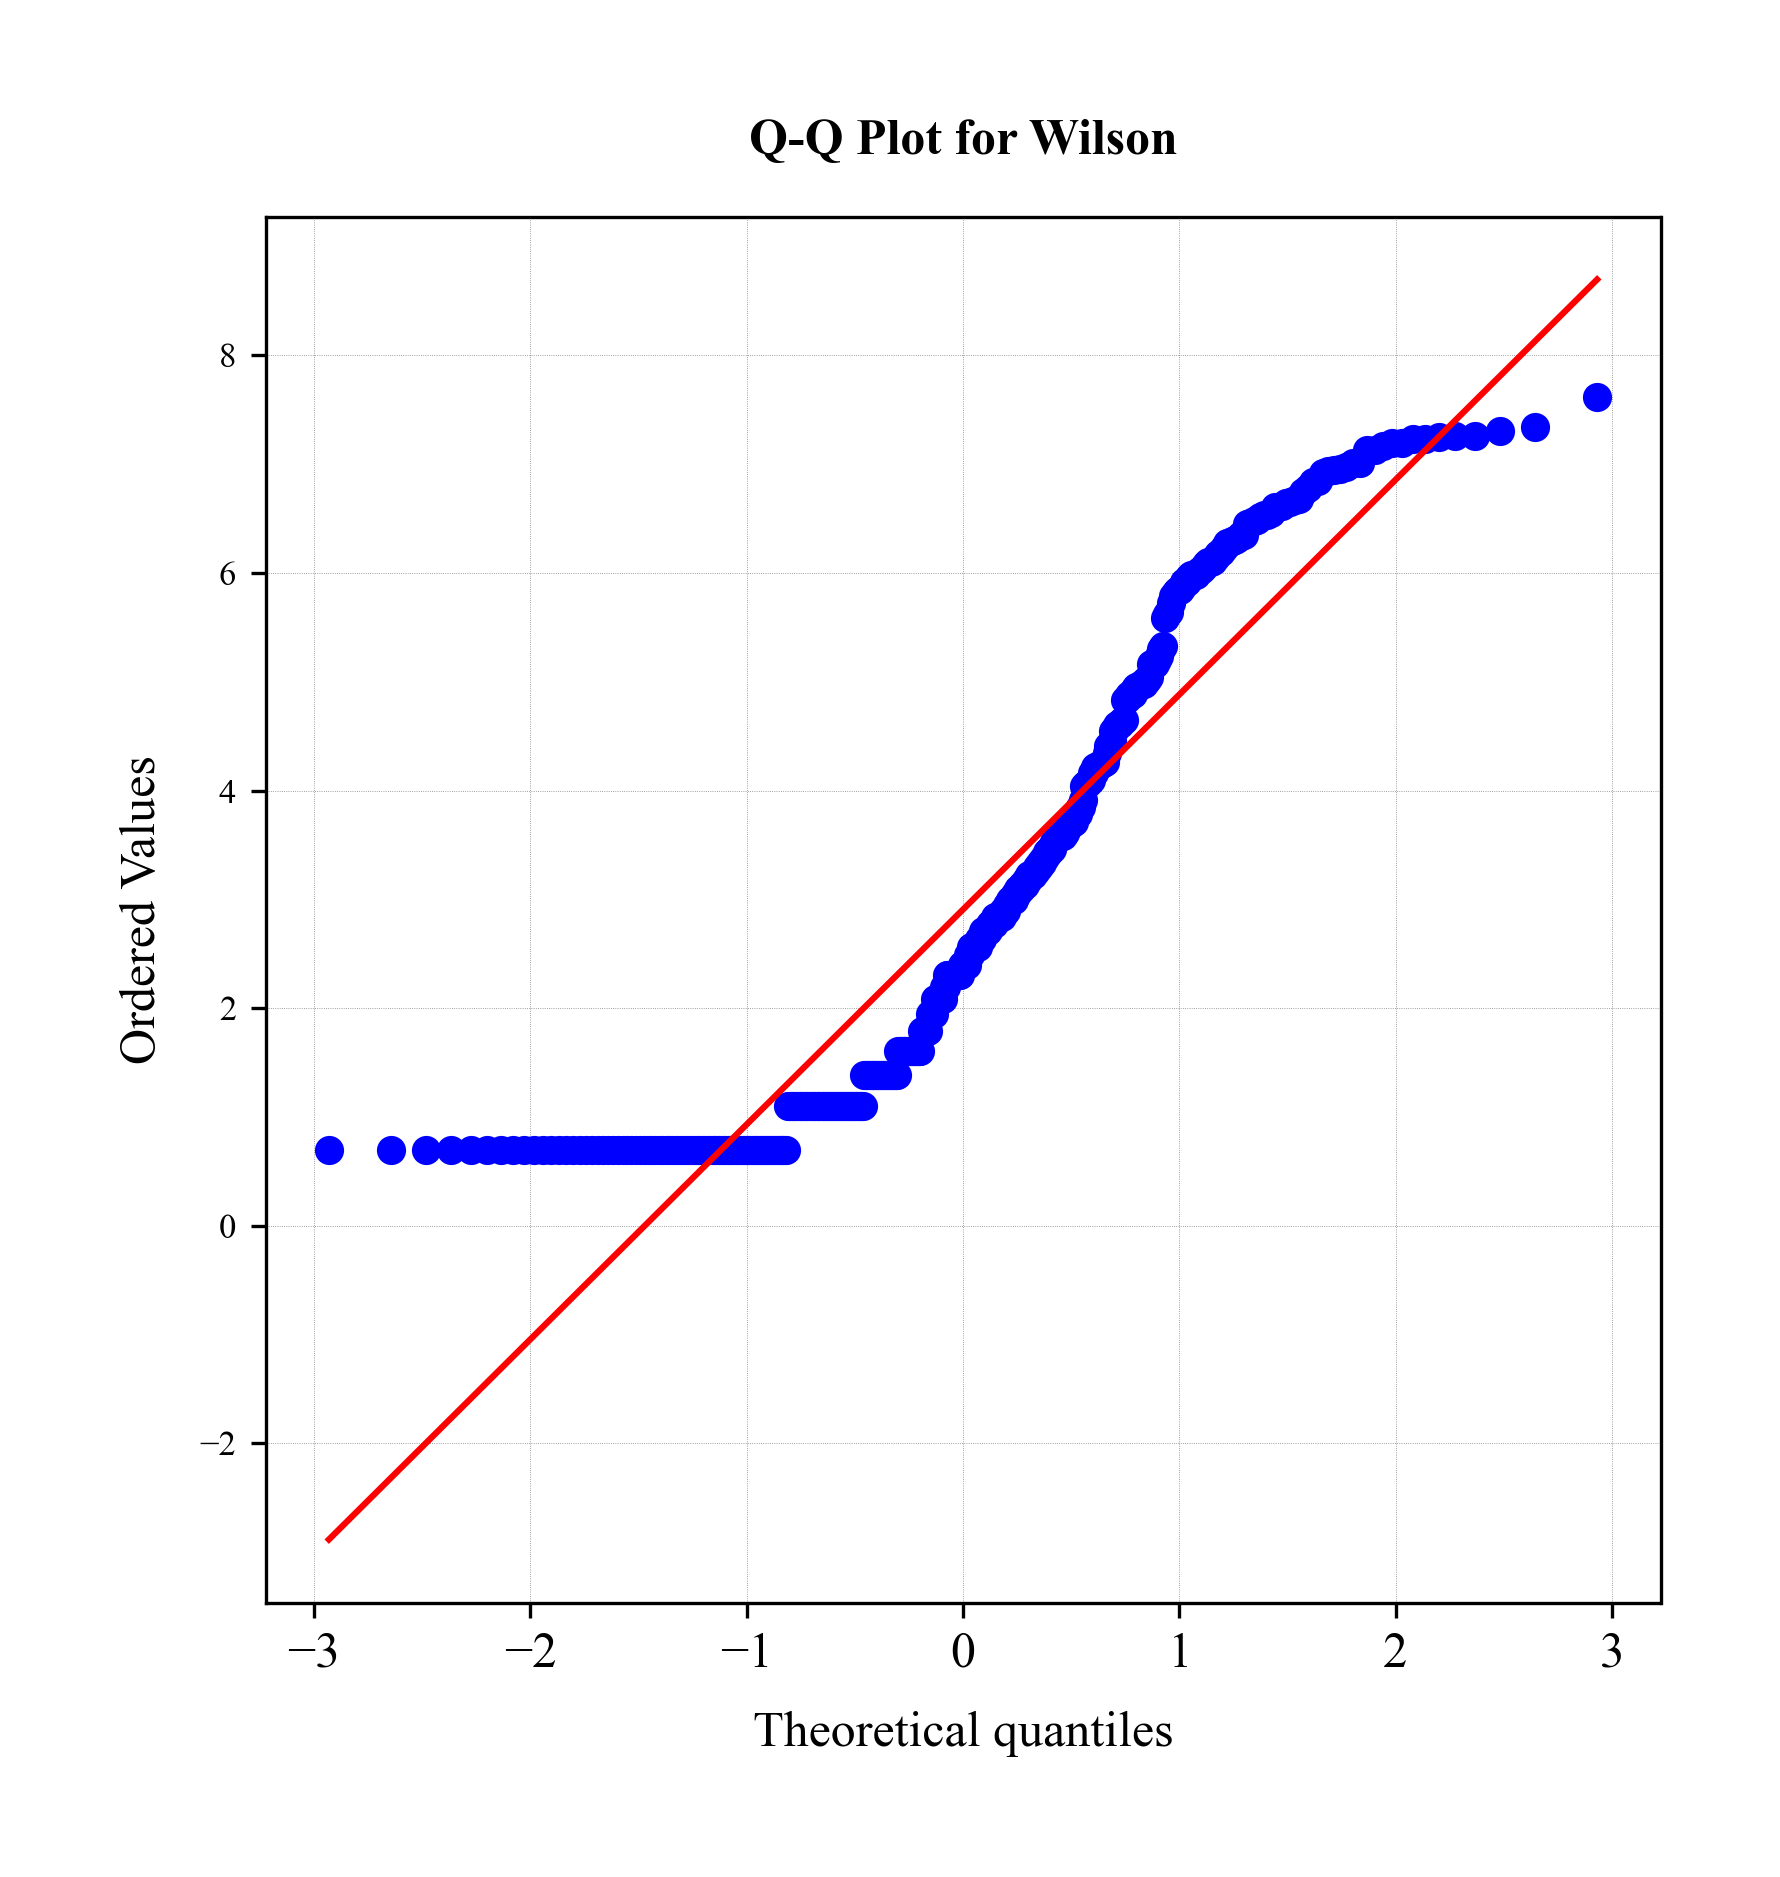


Translator: AT_Murray
  Shapiro-Wilk p-value: p = 0.00000
  Kolmogorov-Smirnov p-value: p = 0.00000
  D'Agostino K^2 p-value: p = 0.00000

Translator: Fagles
  Shapiro-Wilk p-value: p = 0.00000
  Kolmogorov-Smirnov p-value: p = 0.00000
  D'Agostino K^2 p-value: p = 0.00000

Translator: Fitzgerald
  Shapiro-Wilk p-value: p = 0.00000
  Kolmogorov-Smirnov p-value: p = 0.00000
  D'Agostino K^2 p-value: p = 0.00000

Translator: Green
  Shapiro-Wilk p-value: p = 0.00000
  Kolmogorov-Smirnov p-value: p = 0.00000
  D'Agostino K^2 p-value: p = 0.00000

Translator: Lattimore
  Shapiro-Wilk p-value: p = 0.00000
  Kolmogorov-Smirnov p-value: p = 0.00000
  D'Agostino K^2 p-value: p = 0.00000

Translator: Wilson
  Shapiro-Wilk p-value: p = 0.00000
  Kolmogorov-Smirnov p-value: p = 0.00000
  D'Agostino K^2 p-value: p = 0.00000


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, kstest, normaltest, probplot

def analyze_word_frequencies(odysseys_df):
    translator_groups = odysseys_df.groupby("translator")
    
    results = {}

    for translator, group in translator_groups:
        all_frequencies = []

        for counts_dict in group["ety_label_counts"]:
            all_frequencies.extend(counts_dict.values())

        # Convert to numpy array
        all_frequencies = np.array(all_frequencies)
        all_frequencies = all_frequencies[all_frequencies > 0]  # Remove zero values

        if len(all_frequencies) > 10:  # Ensure enough data points
            log_frequencies = np.log1p(all_frequencies)  # Log transform

            # Normality Tests
            shapiro_test = shapiro(log_frequencies)  # Shapiro-Wilk Test
            ks_test = kstest(log_frequencies, 'norm', args=(np.mean(log_frequencies), np.std(log_frequencies)))  # KS Test
            dagostino_test = normaltest(log_frequencies)  # D'Agostino K^2 Test

            results[translator] = {
                "Shapiro-Wilk p-value": shapiro_test.pvalue,
                "Kolmogorov-Smirnov p-value": ks_test.pvalue,
                "D'Agostino K^2 p-value": dagostino_test.pvalue
            }

            # Q-Q Plot
            plt.figure(figsize=(6, 6))
            probplot(log_frequencies, dist="norm", plot=plt)
            plt.title(f"Q-Q Plot for {translator}")
            plt.grid()
            plt.show()

    # Print normality test results
    for translator, stats in results.items():
        print(f"\nTranslator: {translator}")
        for test, p_value in stats.items():
            print(f"  {test}: p = {p_value:.5f}")

# Example usage:
analyze_word_frequencies(odysseys_df)

## Comparing Translations's Etymology Distribution

In [10]:
def expand_ety_label_counts(df, column='ety_label_counts'):
    # Convert list of dictionaries into a DataFrame
    ety_df = df[column].apply(pd.Series).fillna(0).astype(int)
    
    # Concatenate with original df to keep 'translator' and 'book_num'
    df_ety_freq = pd.concat([df[['translator', 'book_num']], ety_df], axis=1)
    
    return df_ety_freq

df_ety_freq = expand_ety_label_counts(odysseys_df)

df_ety_freq.head(3)

,translator,book_num,ang,grc,eng,enm,fro,lat,xno,non,...,tnq,frk,odt,nld,gla,pro,jpn,fas,afr,enn
0,AT_Murray,1,459,12,804,294,45,113,20,25,...,0,0,0,0,0,0,0,0,0,0
1,AT_Murray,2,494,15,771,285,49,125,35,11,...,0,0,0,0,0,0,0,0,0,0
2,AT_Murray,3,503,16,1032,334,59,131,20,16,...,0,0,0,0,0,0,0,0,0,0


### **Origins across books: Fitzgerald and Wilson**

These plots show no significant difference between Fitzgerald and Wilson. This trend is visible acroos all authors. It should be noted that the data has different lenght, and scaling is recommended.

<Figure size 3600x2100 with 0 Axes>

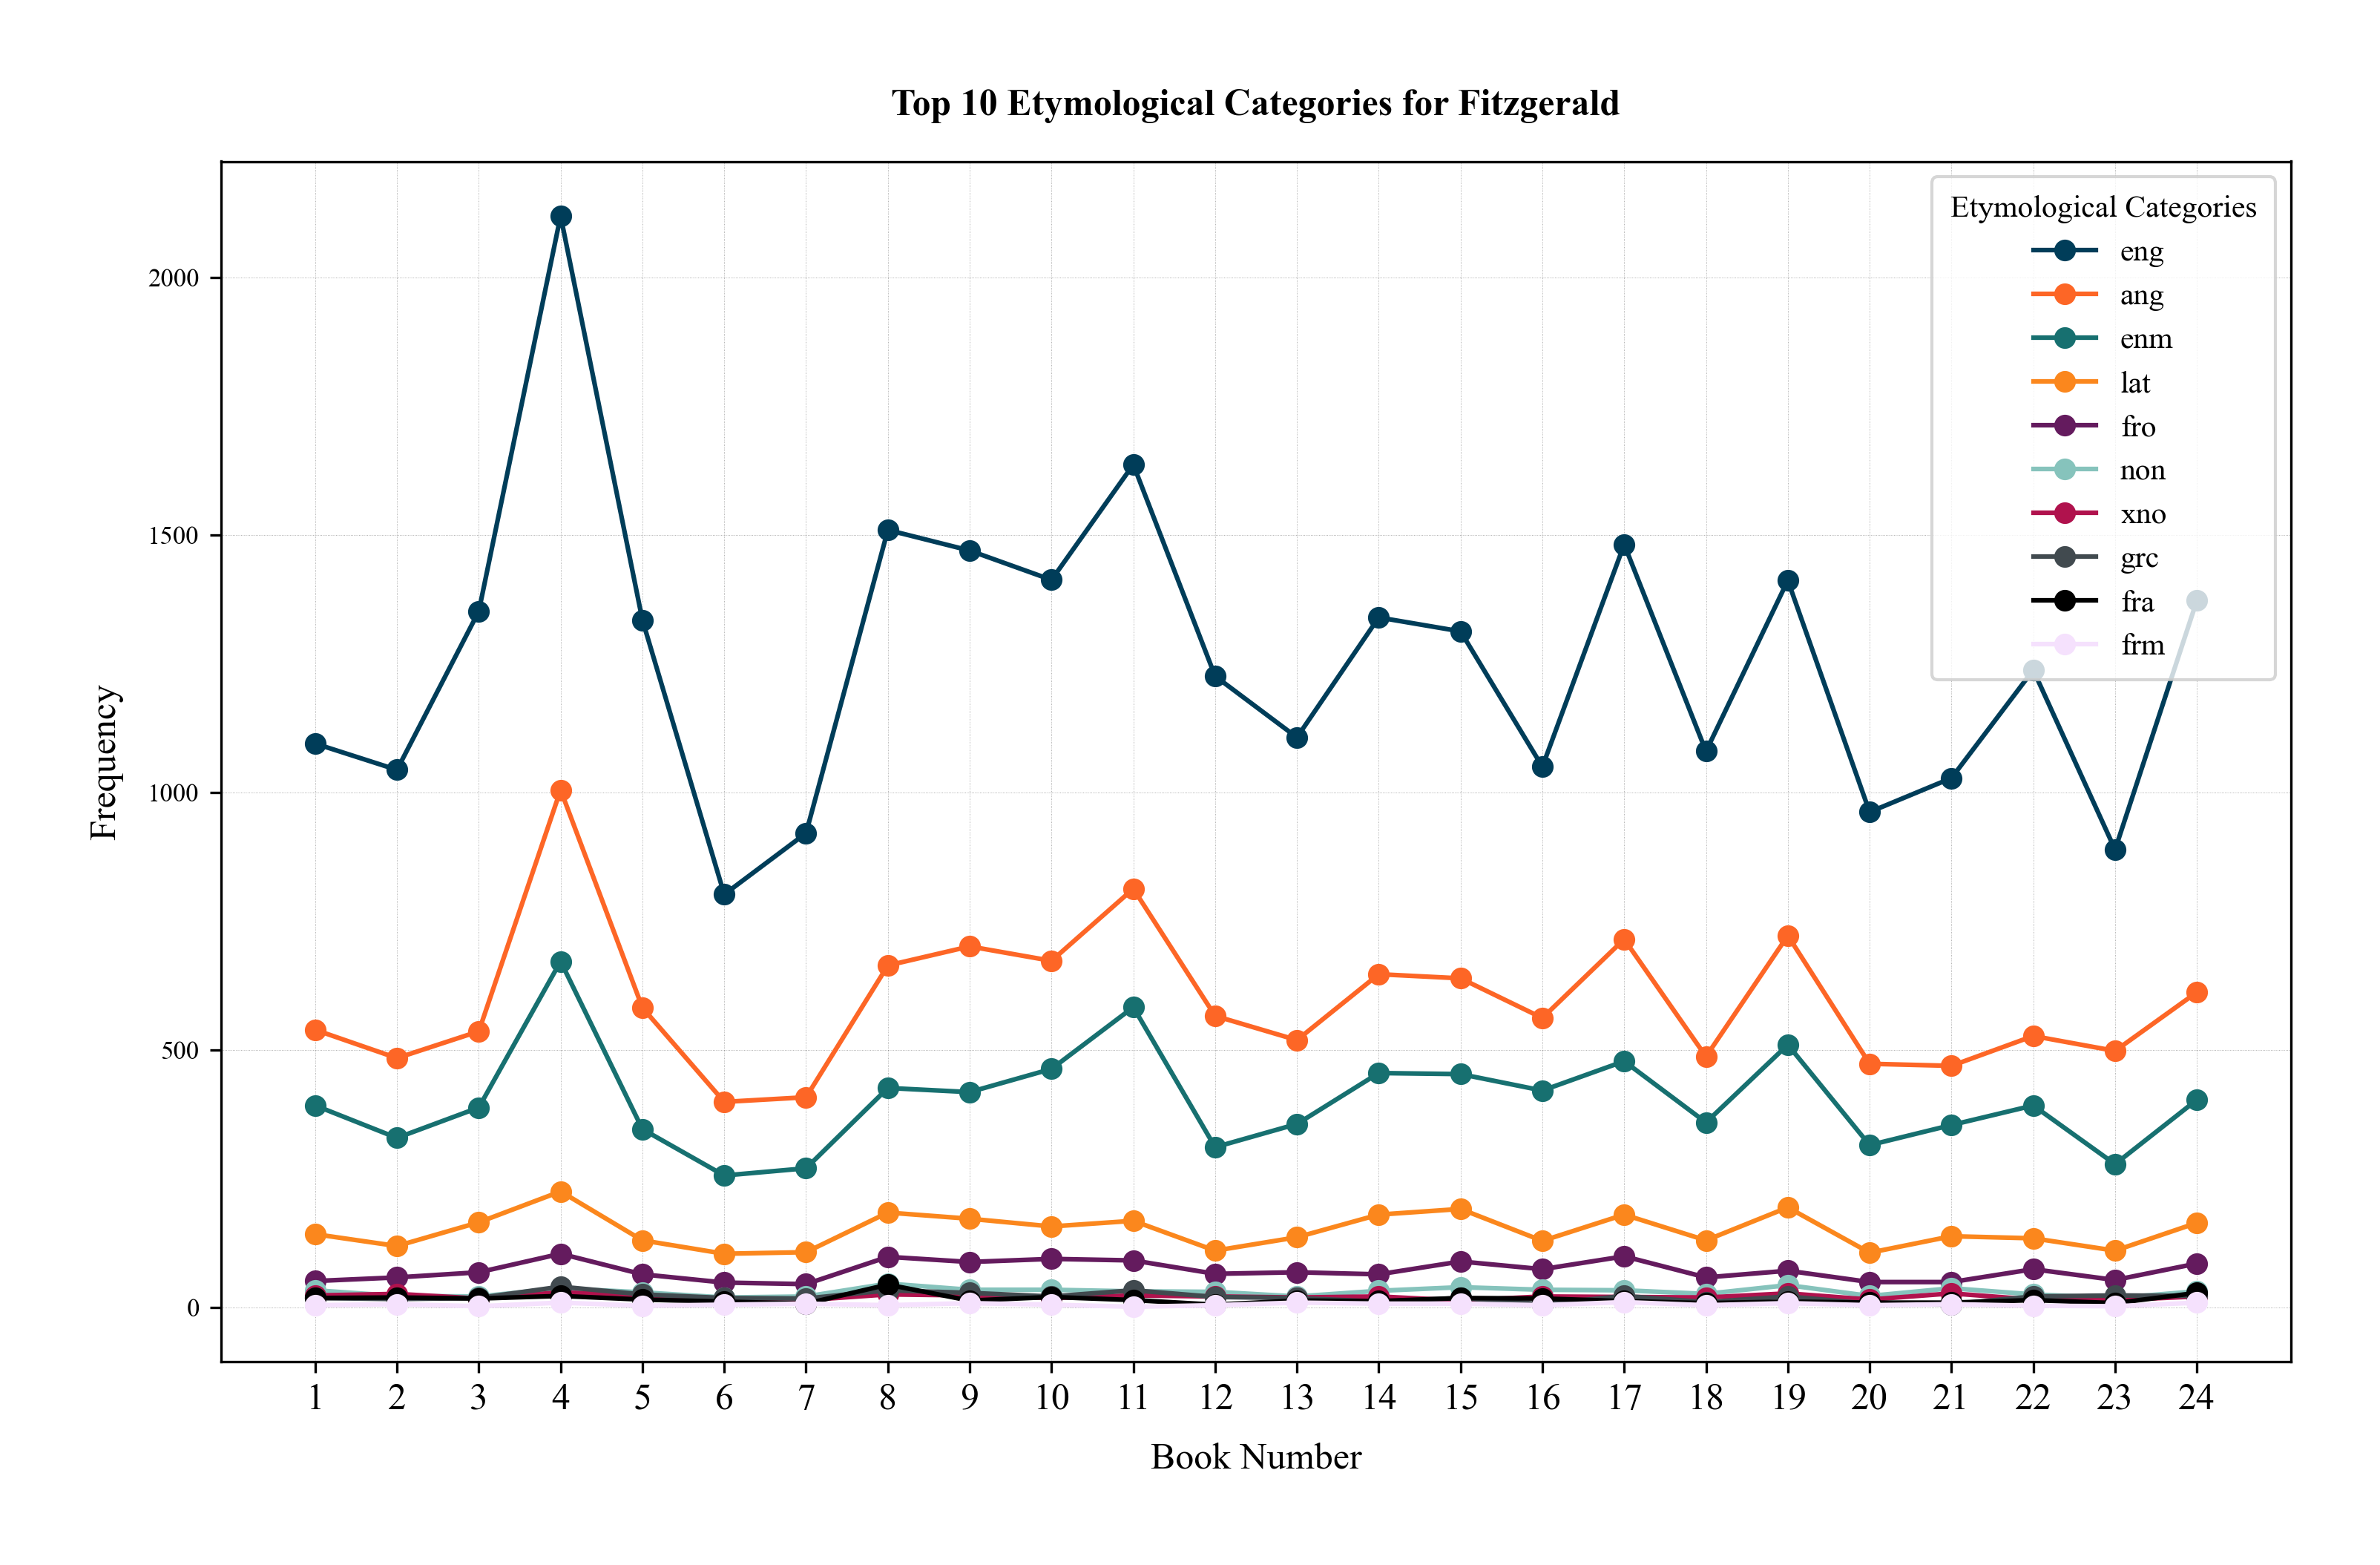

<Figure size 3600x2100 with 0 Axes>

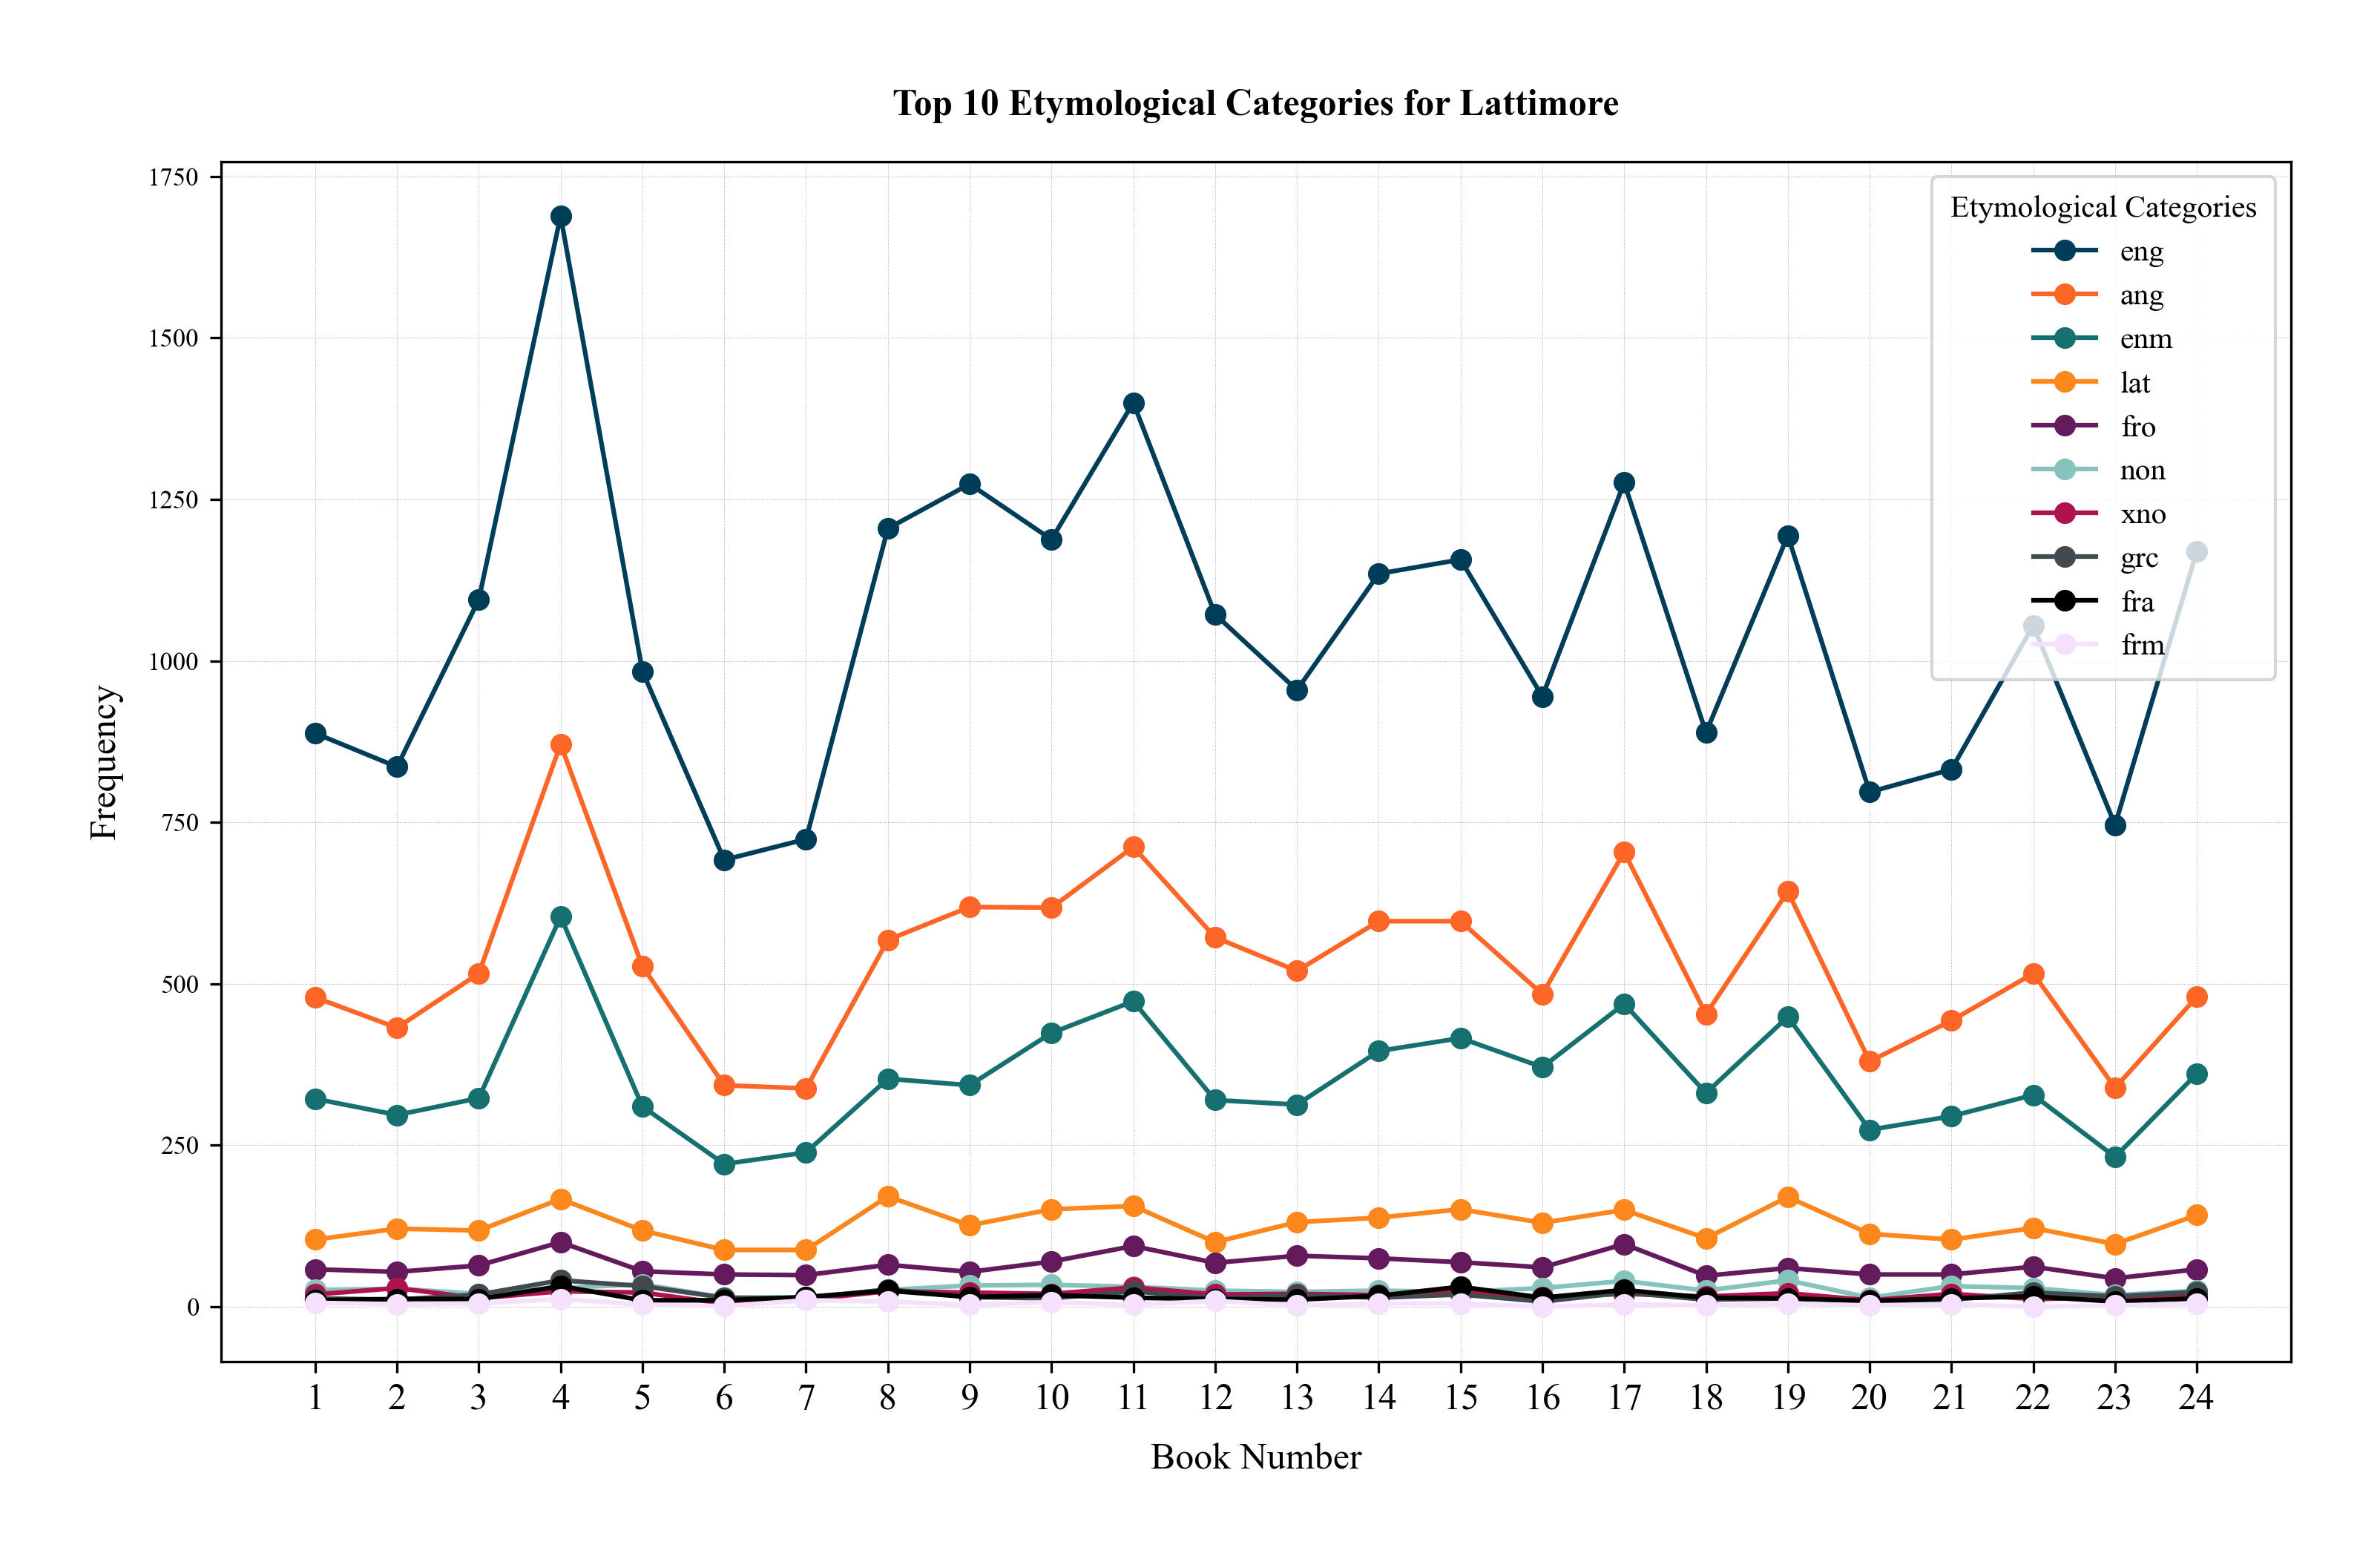

In [11]:
# Origins across books: Fitzgerald and Wilson
# Plotting Frequencies
def plot_ety_freq(df, translator=None, top_n=10):
    """
    Plot the frequencies of etymological categories for a given translator."
    """

    df = df_ety_freq[df_ety_freq['translator'] == translator]

    # Sum frequencies for each category and get the top n
    top_10_categories = df.drop(columns=['translator', 'book_num'])\
                          .sum().nlargest(top_n).index

    # Plot the top n categories over book_num
    plt.figure(figsize=(12, 7))
    df.set_index('book_num')[top_10_categories].plot(kind='line', 
                                                     figsize=(12, 7), marker='o')
    plt.title(f"Top {top_n} Etymological Categories for {translator}")
    plt.xlabel("Book Number")
    plt.ylabel("Frequency")
    plt.xticks(ticks=range(1, 25), labels=range(1, 25))
    plt.grid(alpha=0.4)
    plt.legend(title="Etymological Categories")
    plt.grid(True)
    plt.show()

# Example usage
plot_ety_freq(df_ety_freq, translator='Fitzgerald', top_n=10)
plot_ety_freq(df_ety_freq, translator='Lattimore', top_n=10)

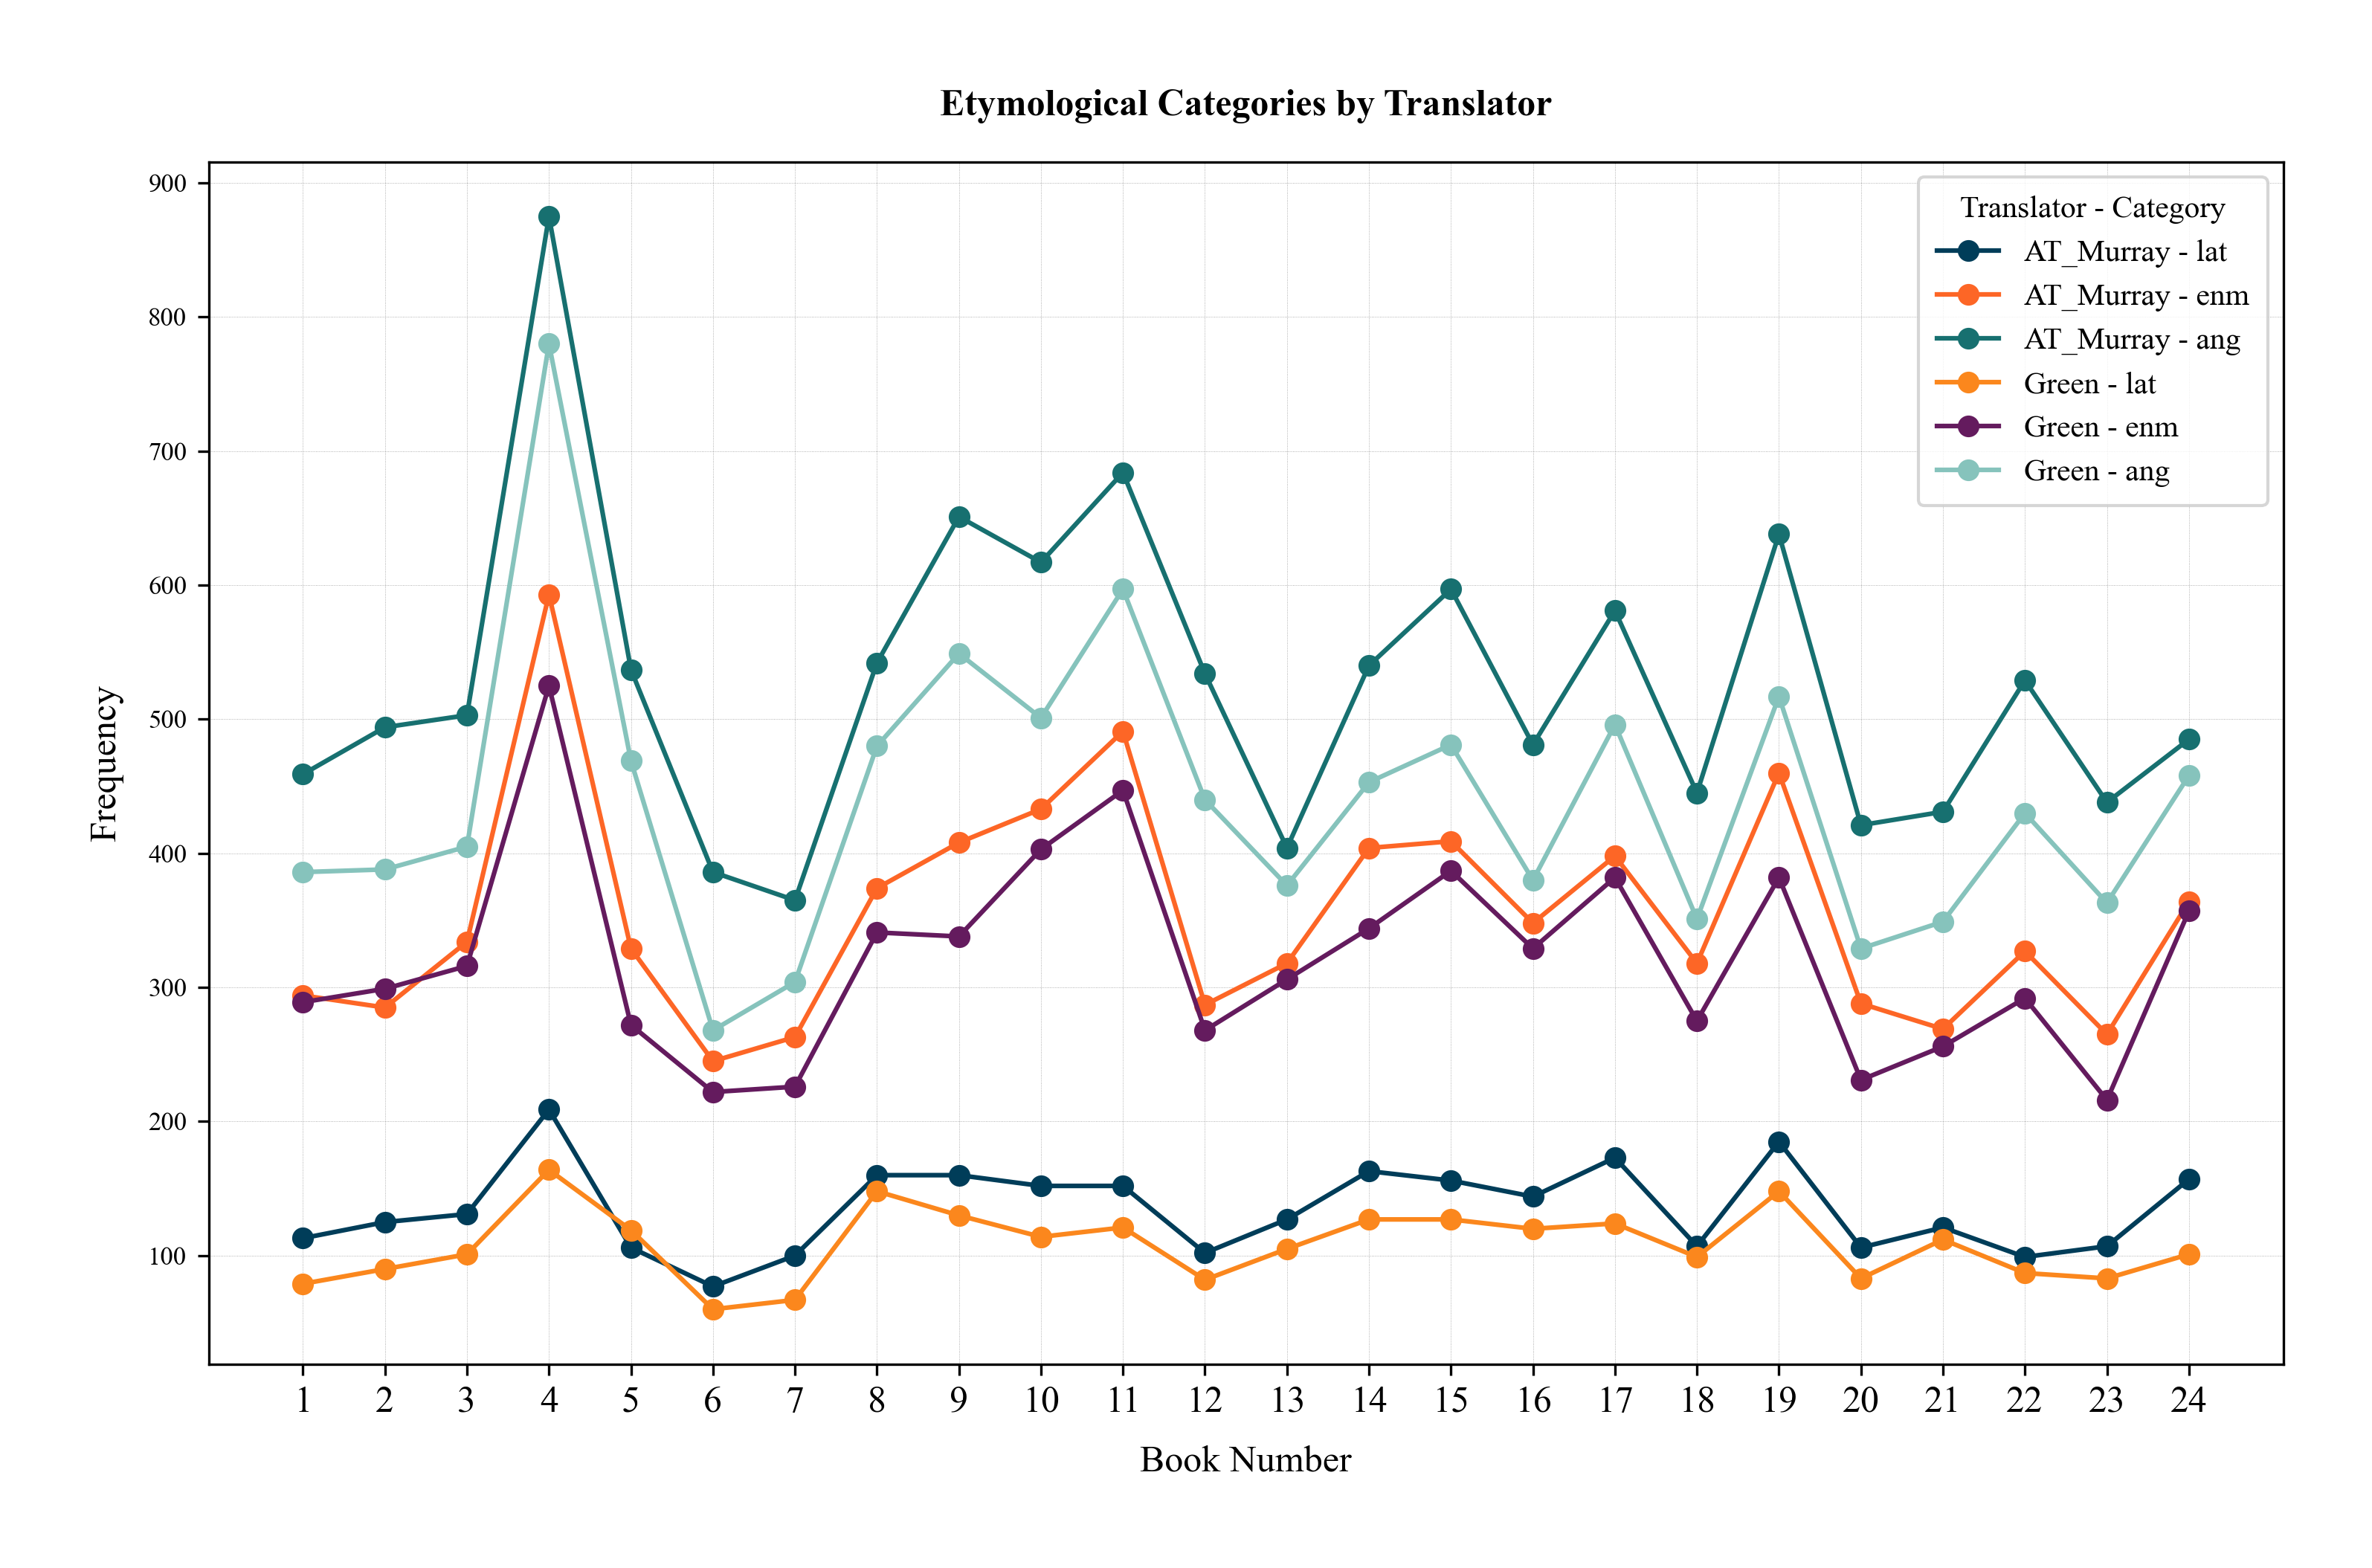

In [12]:
import matplotlib.pyplot as plt

def plot_ety_cat(df, cat=['lat', 'ang', 'enm'], translator=['all']):
    """
    Plot the frequencies of selected etymological categories across books for given translators.
    
    Parameters:
    - df: DataFrame containing etymological frequency data.
    - cat: List of categories to plot (default: ['lat', 'ang']).
    - translator: List of translators to filter (default: ['all'] for all translators).
    """

    if 'all' not in translator:
        df = df[df['translator'].isin(translator)]  # Filter by selected translators

    plt.figure(figsize=(12, 7))

    # Loop over each translator and each category separately
    for trans in df['translator'].unique():
        df_trans = df[df['translator'] == trans]  # Filter for translator

        for category in cat:
            if category in df.columns:  # Ensure the category exists
                plt.plot(
                    df_trans['book_num'], df_trans[category], 
                    marker='o', linestyle='-', label=f"{trans} - {category}"
                )

    plt.title("Etymological Categories by Translator")
    plt.xlabel("Book Number")
    plt.ylabel("Frequency")
    plt.xticks(ticks=range(1, 25), labels=range(1, 25))
    plt.legend(title="Translator - Category")  # Now legend shows both
    plt.grid(alpha=0.4)
    plt.show()

# Example usage:
plot_ety_cat(df_ety_freq, cat=['lat', 'enm', 'ang'], translator=['AT_Murray', 'Green'])

### **Hypothesis testing**


* H0: There is NOT significant etymological differnece between the authors
* H1: There is SIGNIFICANT etymological differnece between the authors

   - ANOVA to compare multiple distributions
   -  Kruskal-Wallis due to non-normality or unequal variance (a non-parametric test).       

Calculating best minimal value for power law fit



Translator: AT_Murray
Power-law alpha: 1.4402, xmin: 7.0
R (power-law vs log-normal): -17.7945, p-value: 0.0001


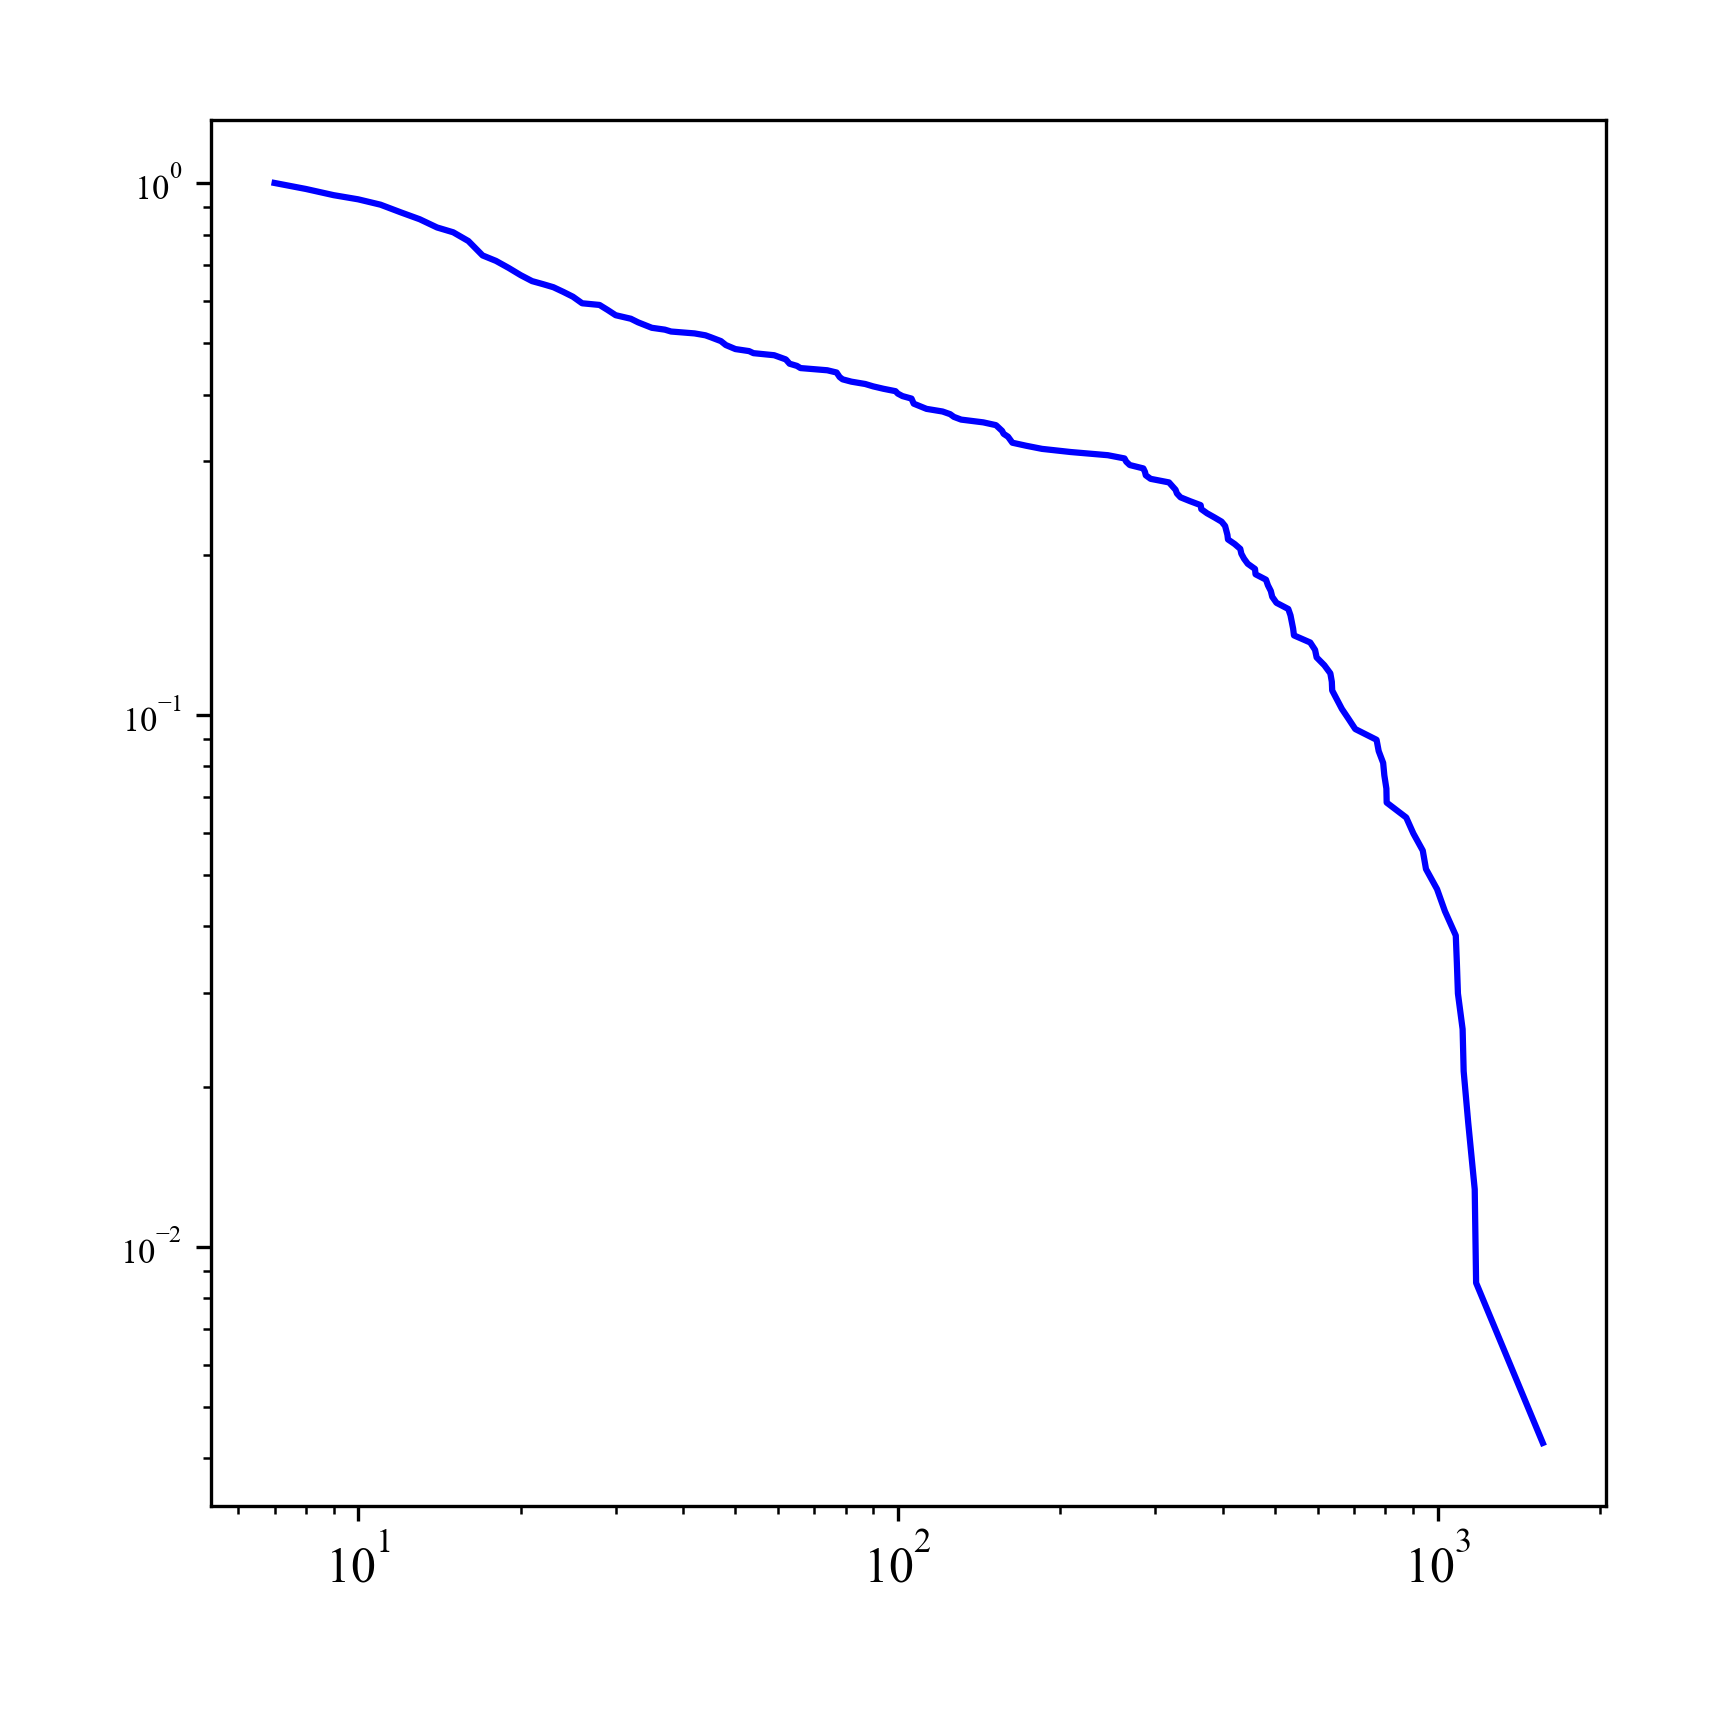

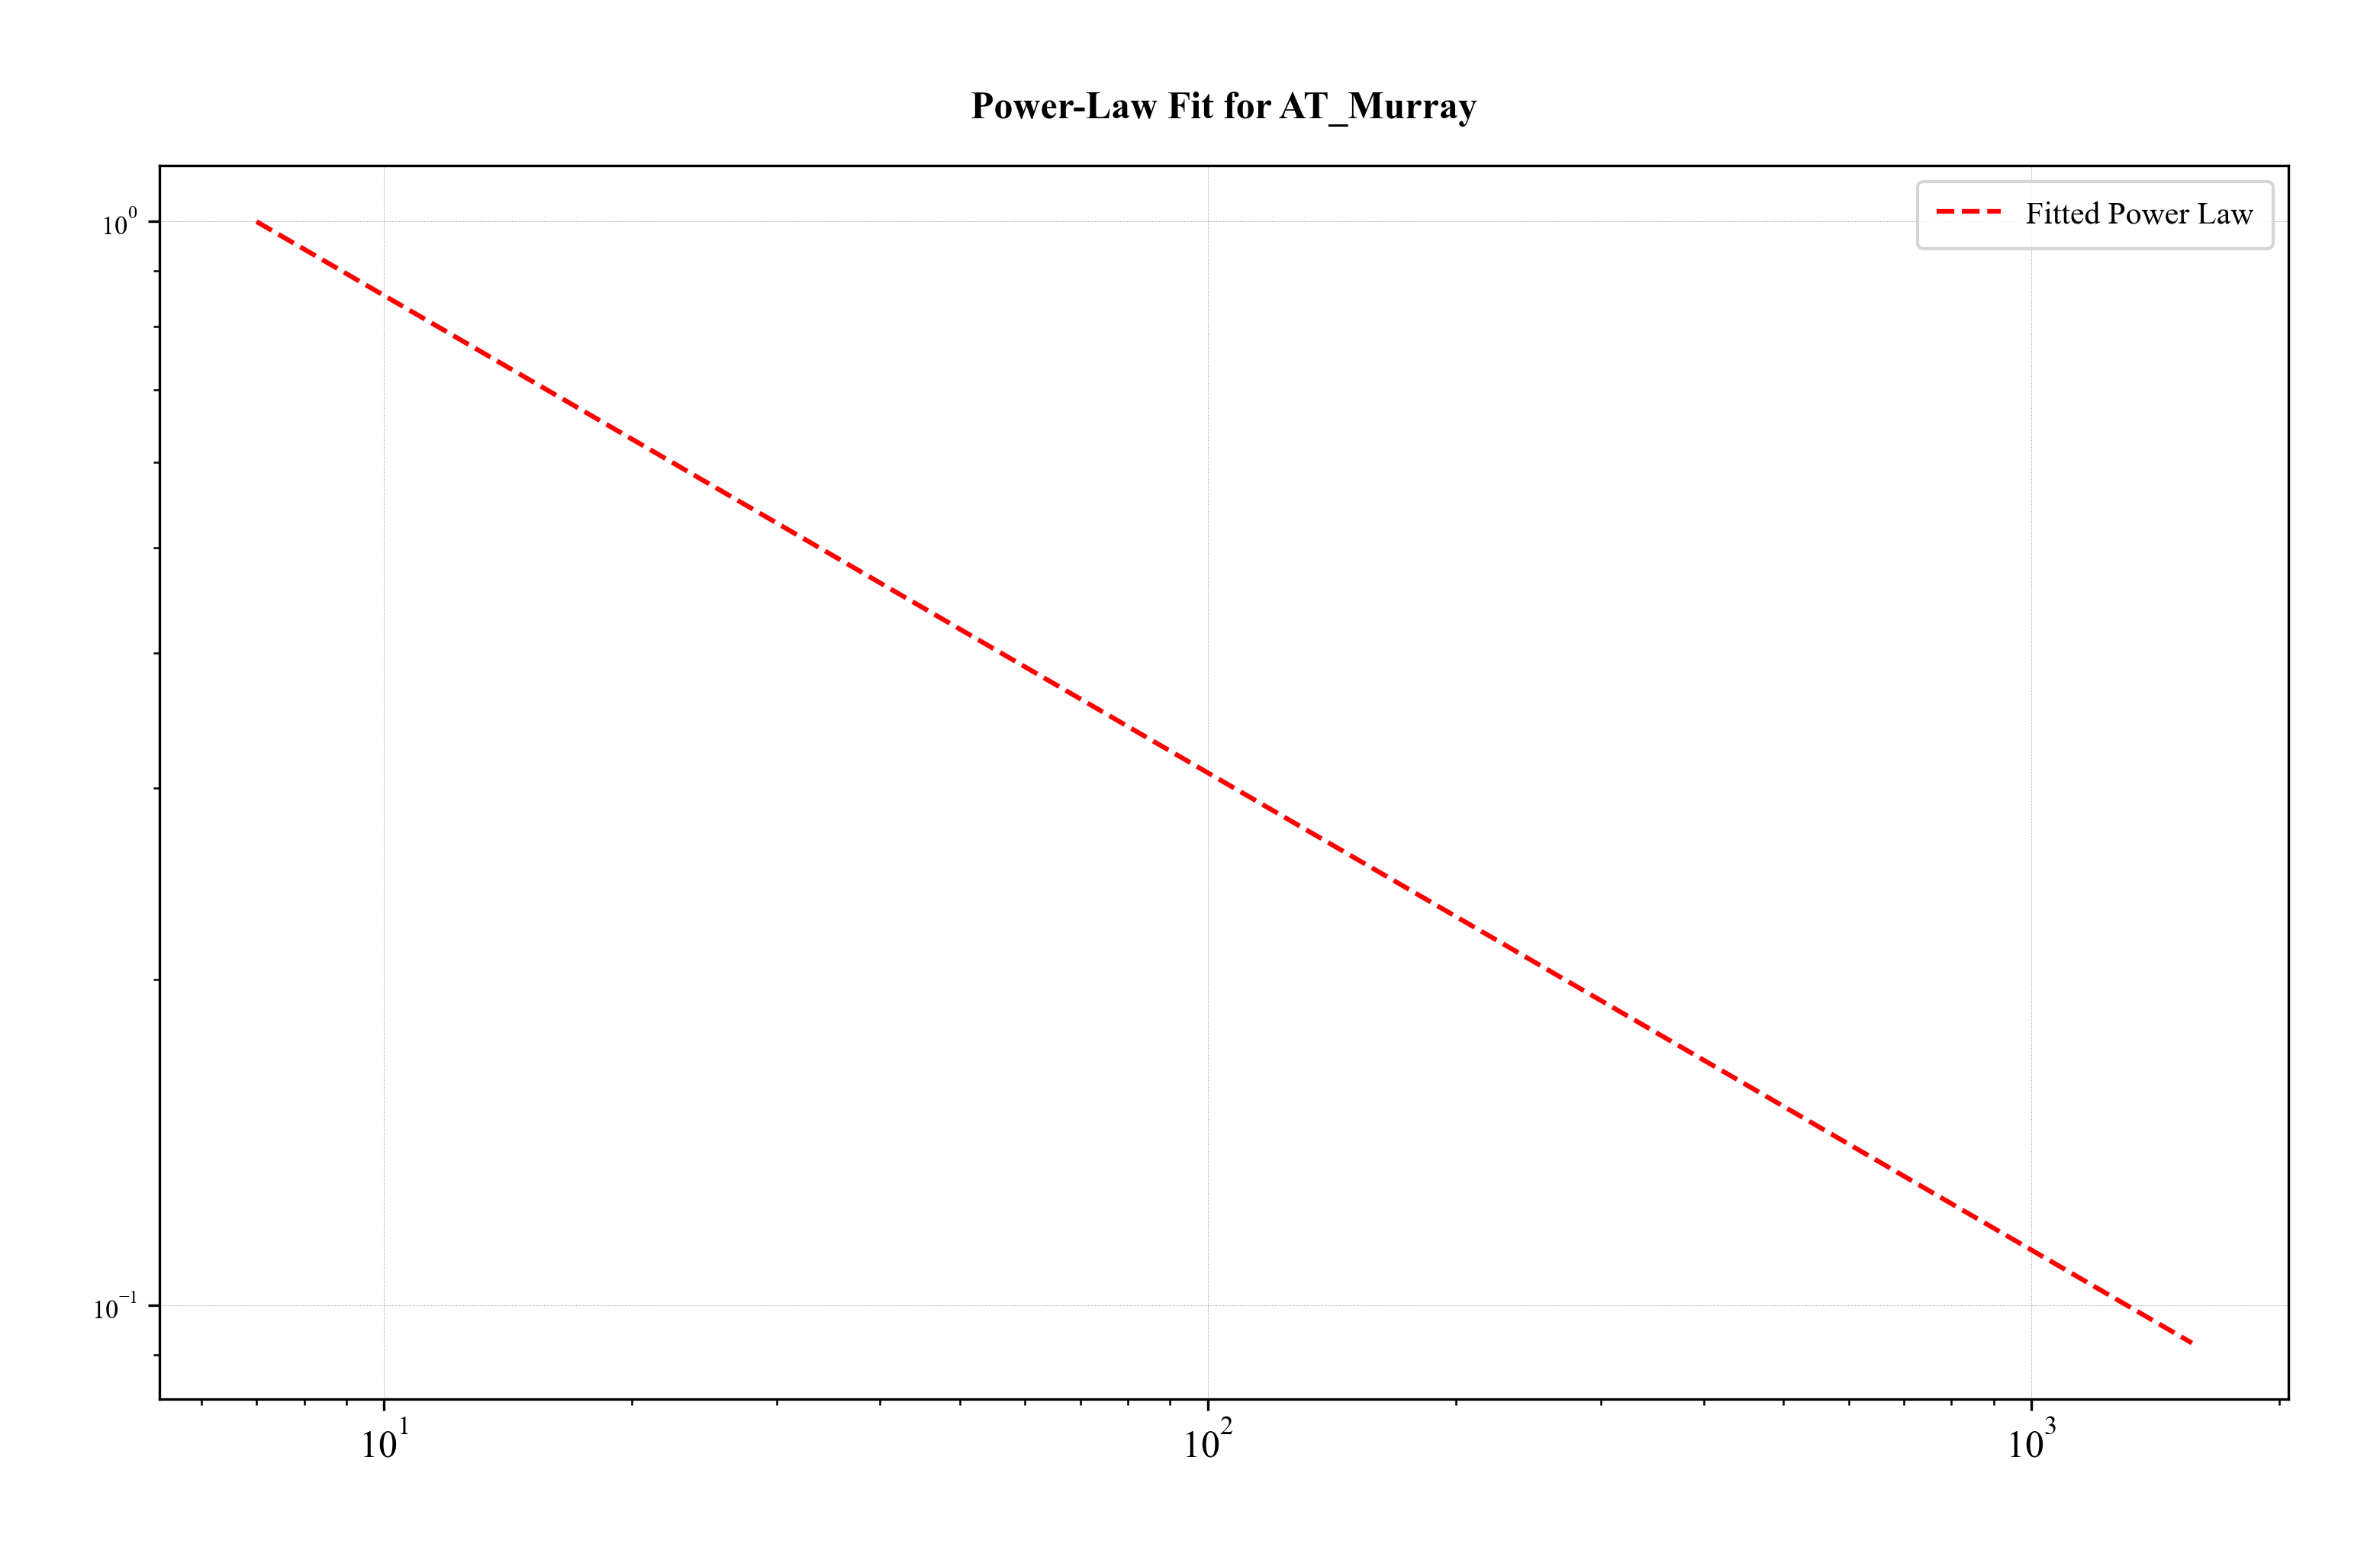


Translator: Fagles
Power-law alpha: 1.3949, xmin: 1.0
R (power-law vs log-normal): -3.6039, p-value: 0.1025


Calculating best minimal value for power law fit


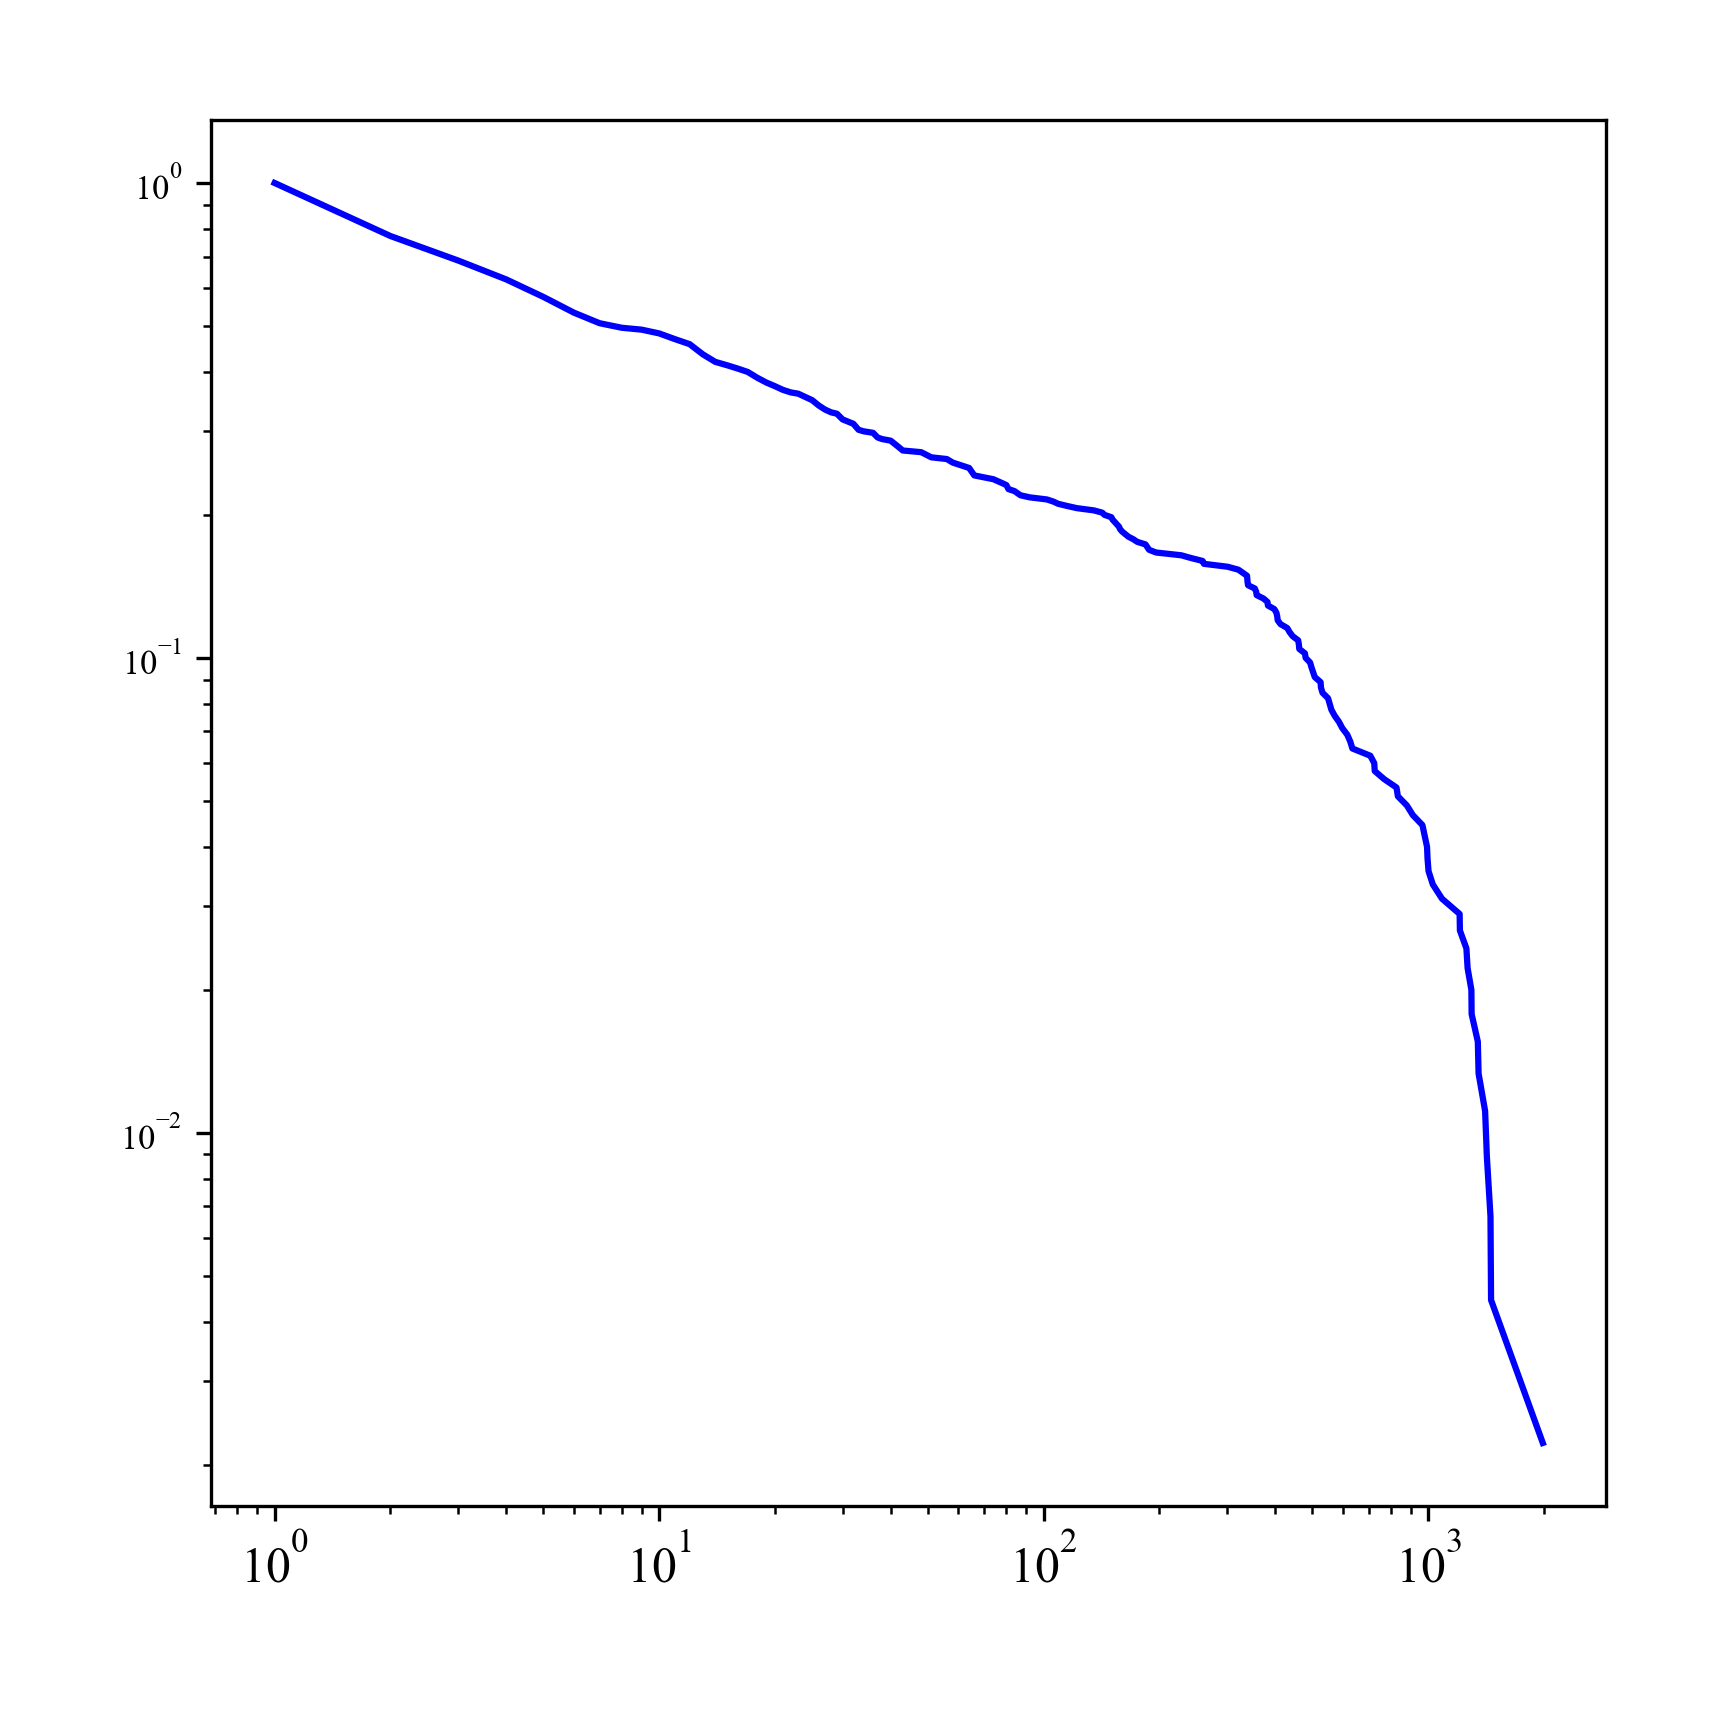

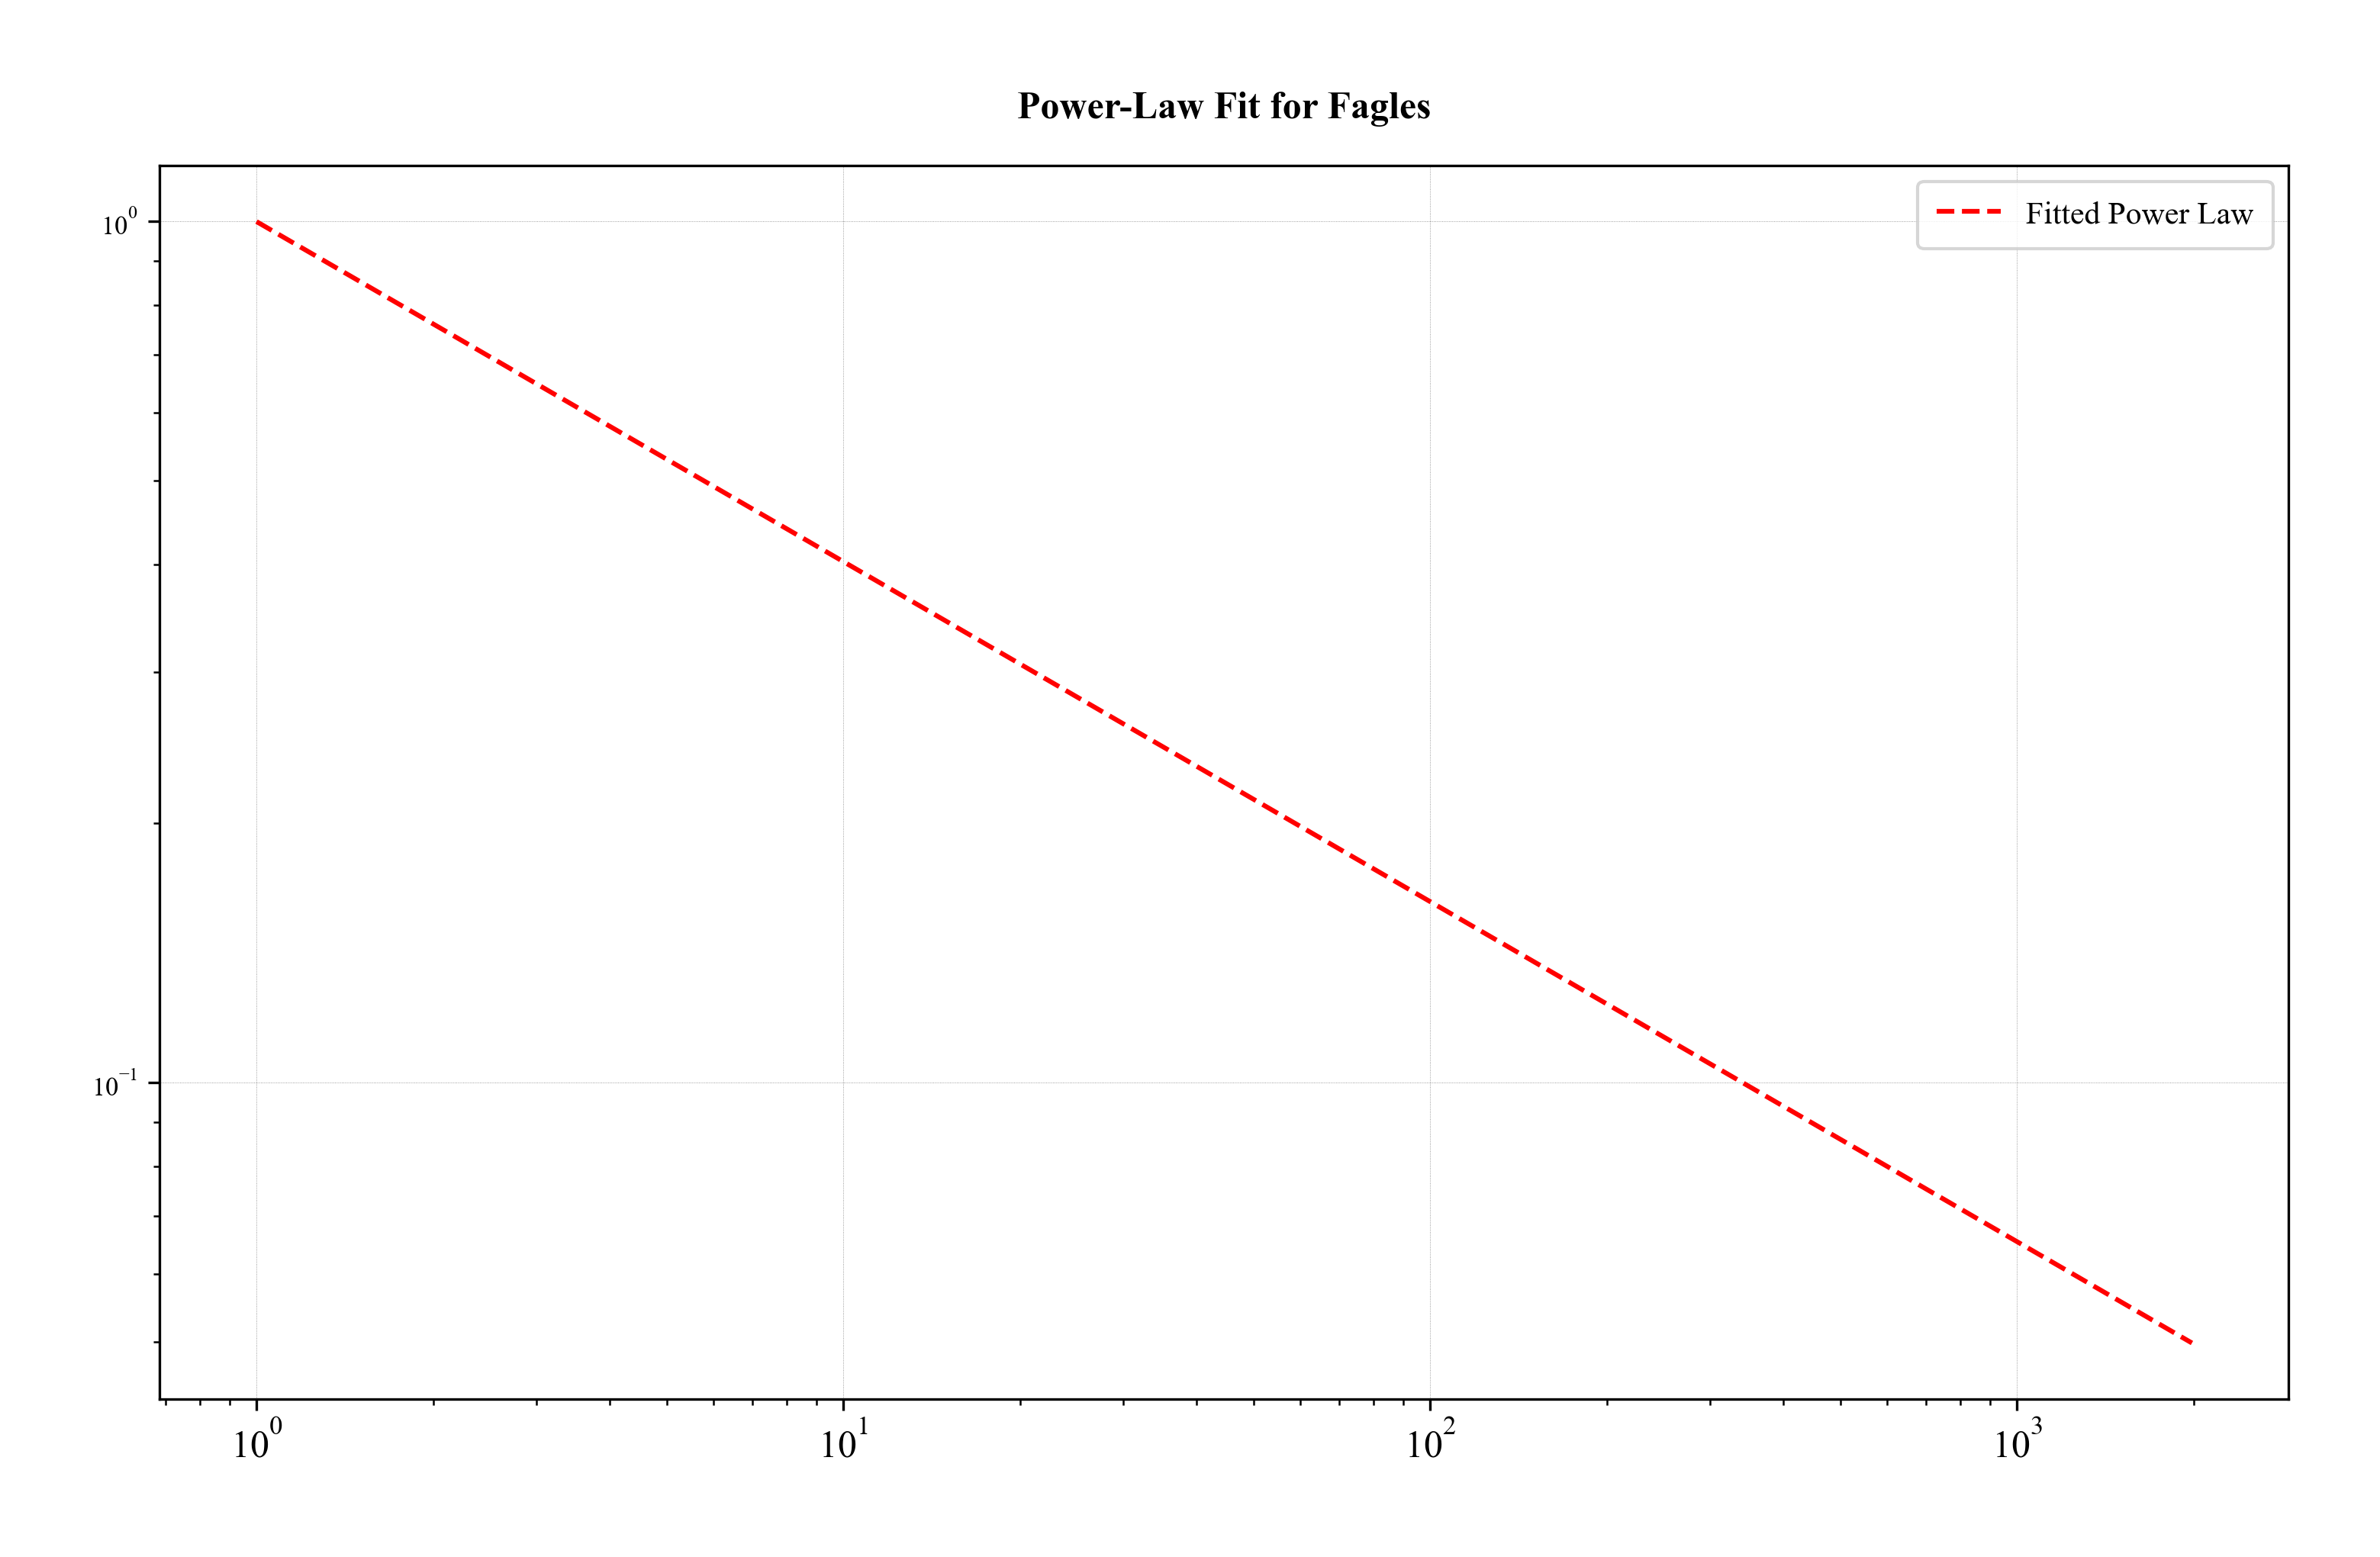

Calculating best minimal value for power law fit
'nan' in fit cumulative distribution values.
Likely underflow or overflow error: the optimal fit for this distribution gives values that are so extreme that we lack the numerical precision to calculate them.



Translator: Fitzgerald
Power-law alpha: 10.0192, xmin: 1313.0
R (power-law vs log-normal): 0.0012, p-value: 0.9098


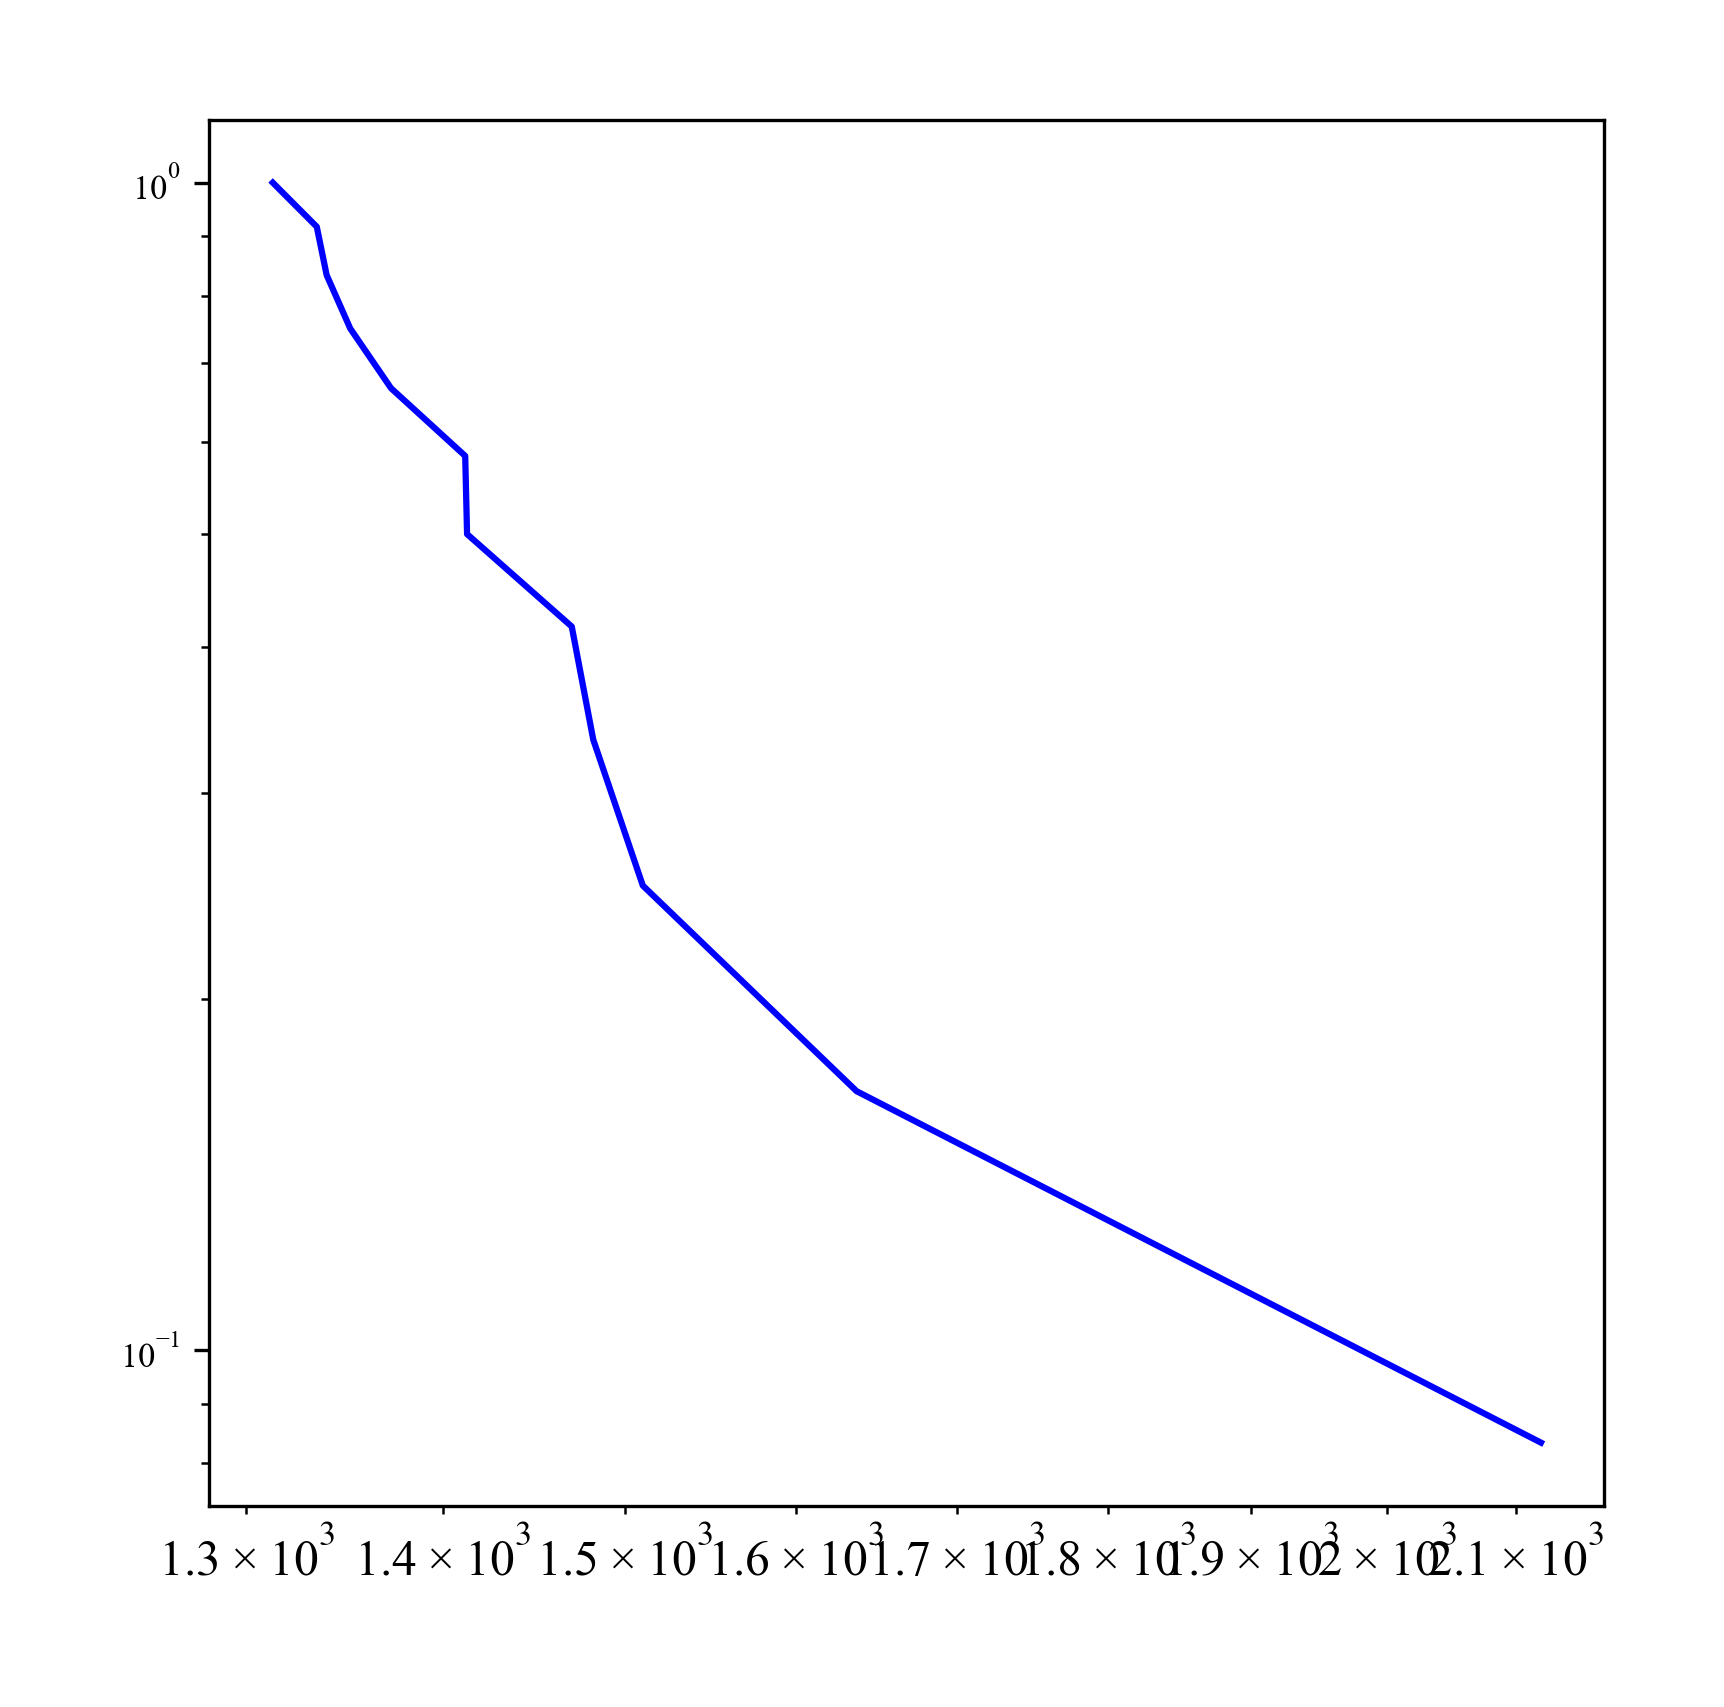

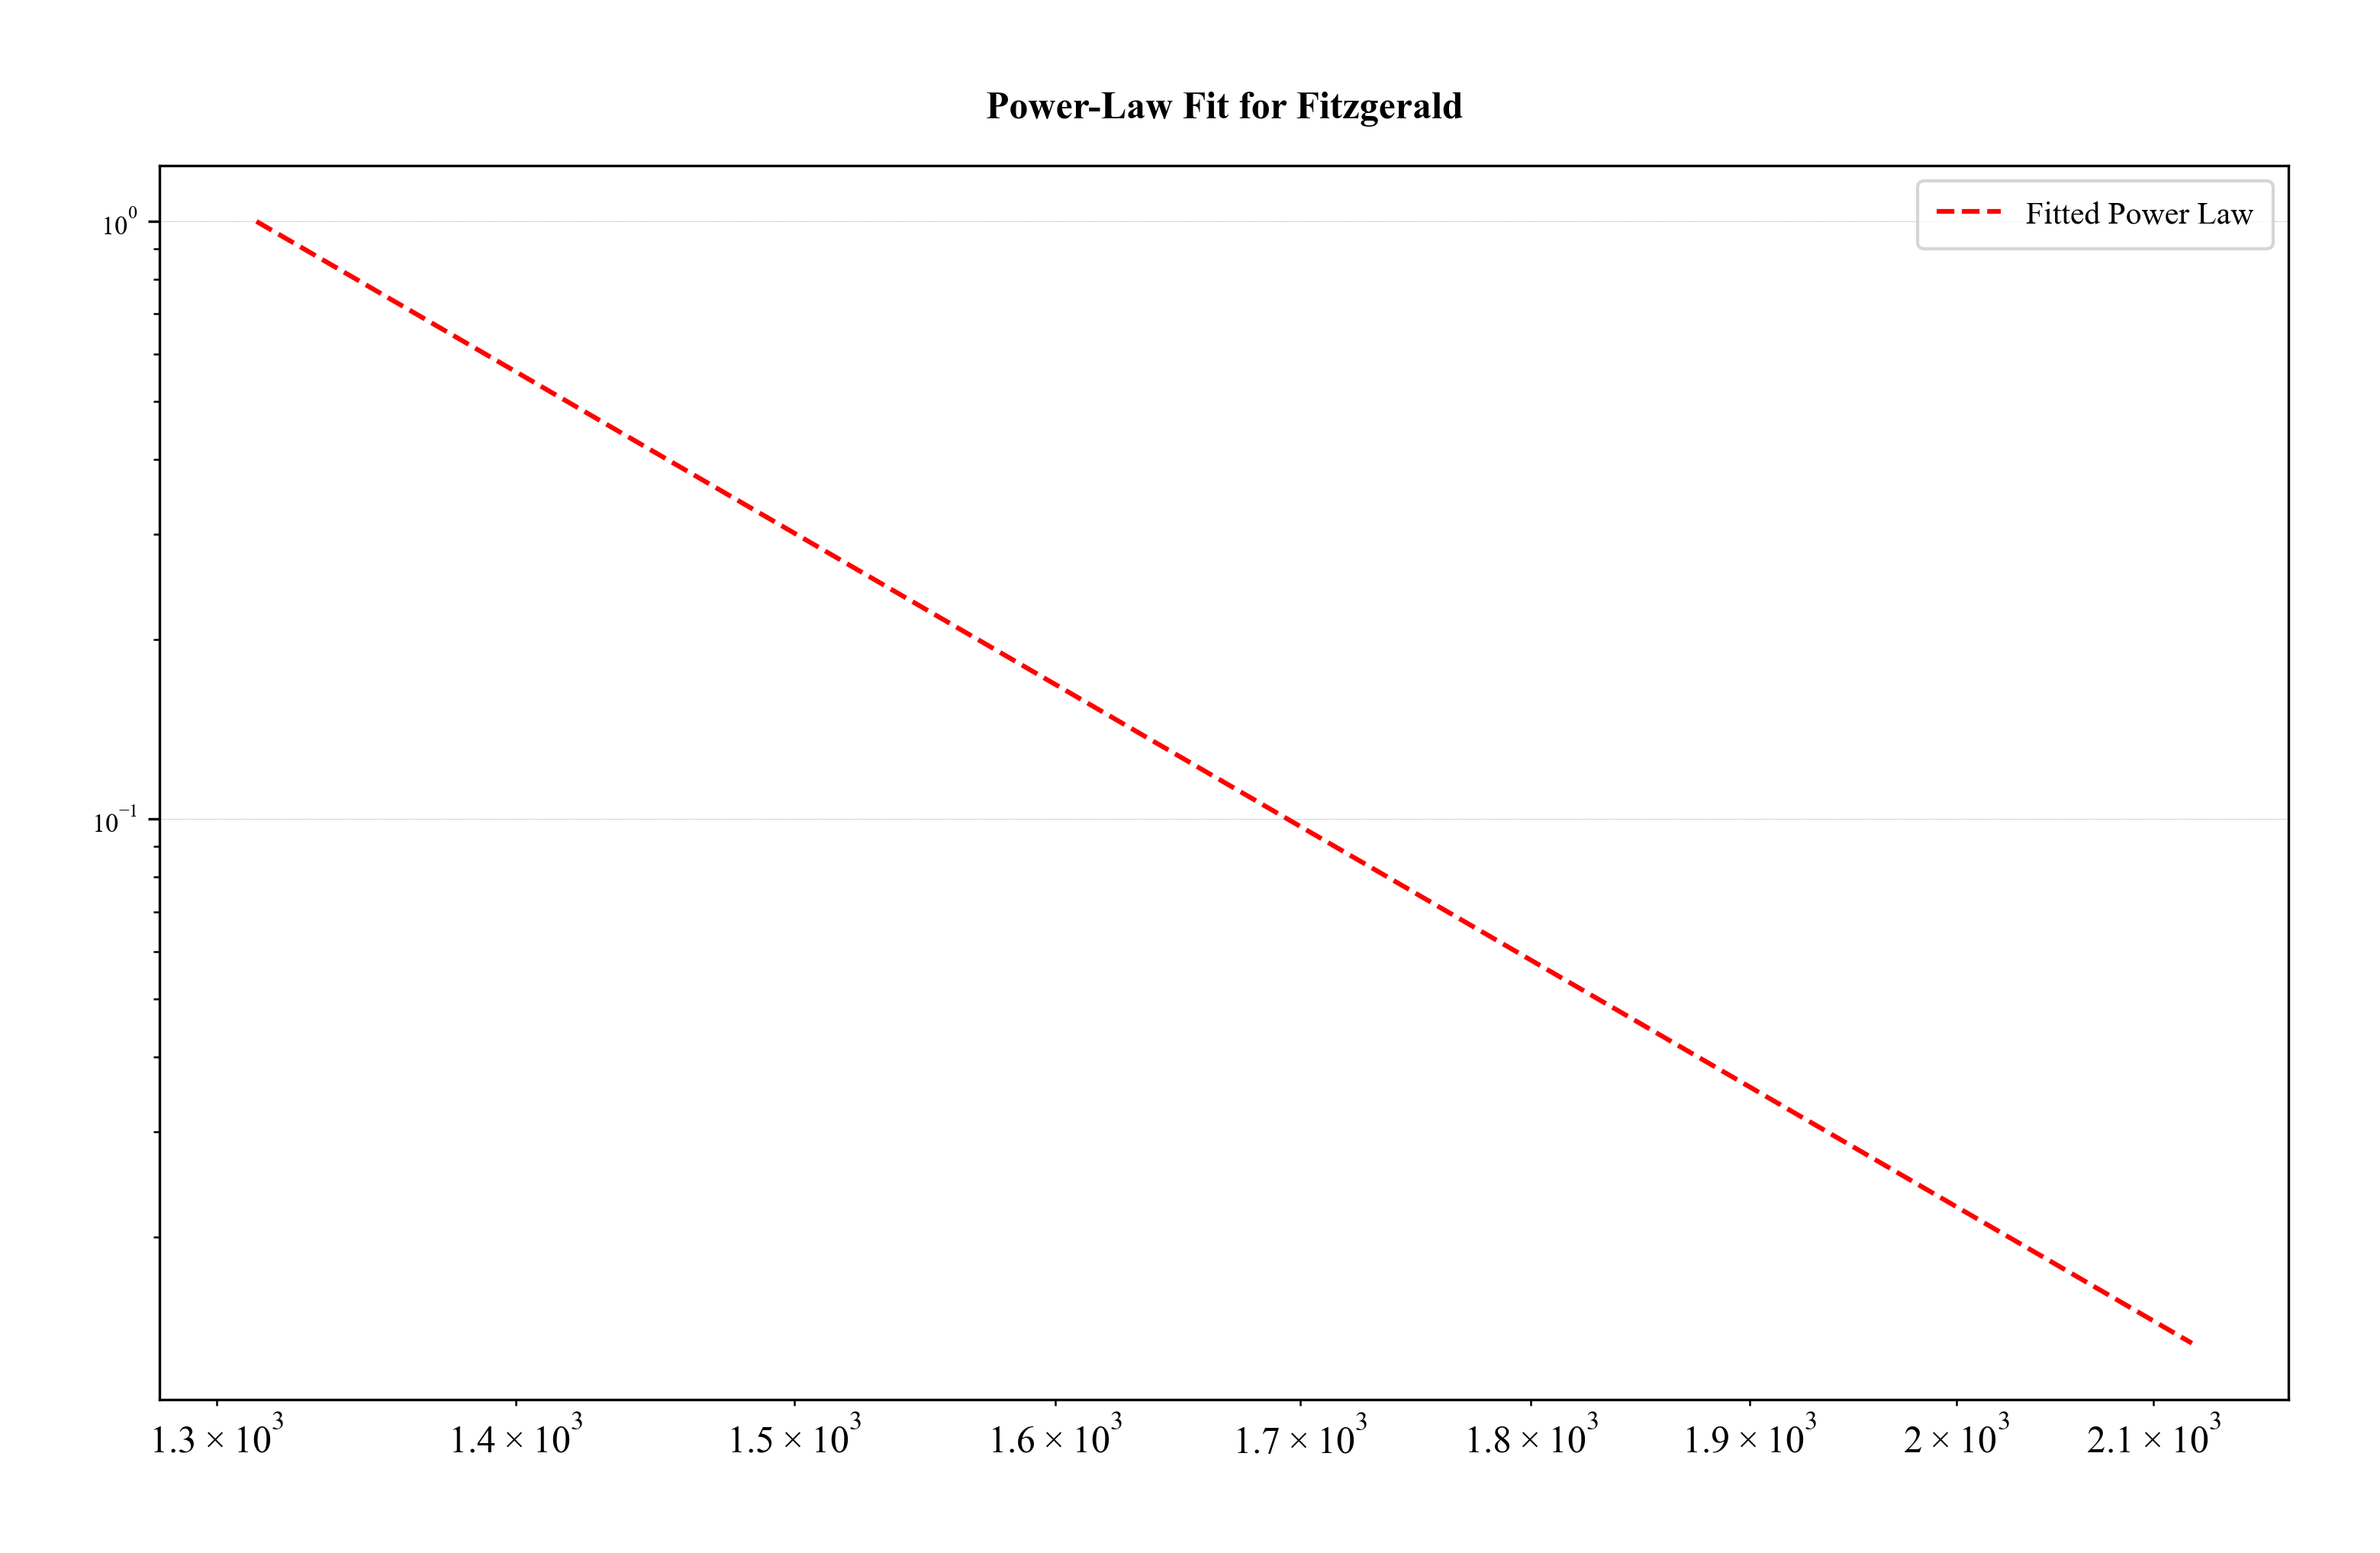


Translator: Green
Power-law alpha: 1.4053, xmin: 1.0
R (power-law vs log-normal): -2.7490, p-value: 0.1593


Calculating best minimal value for power law fit


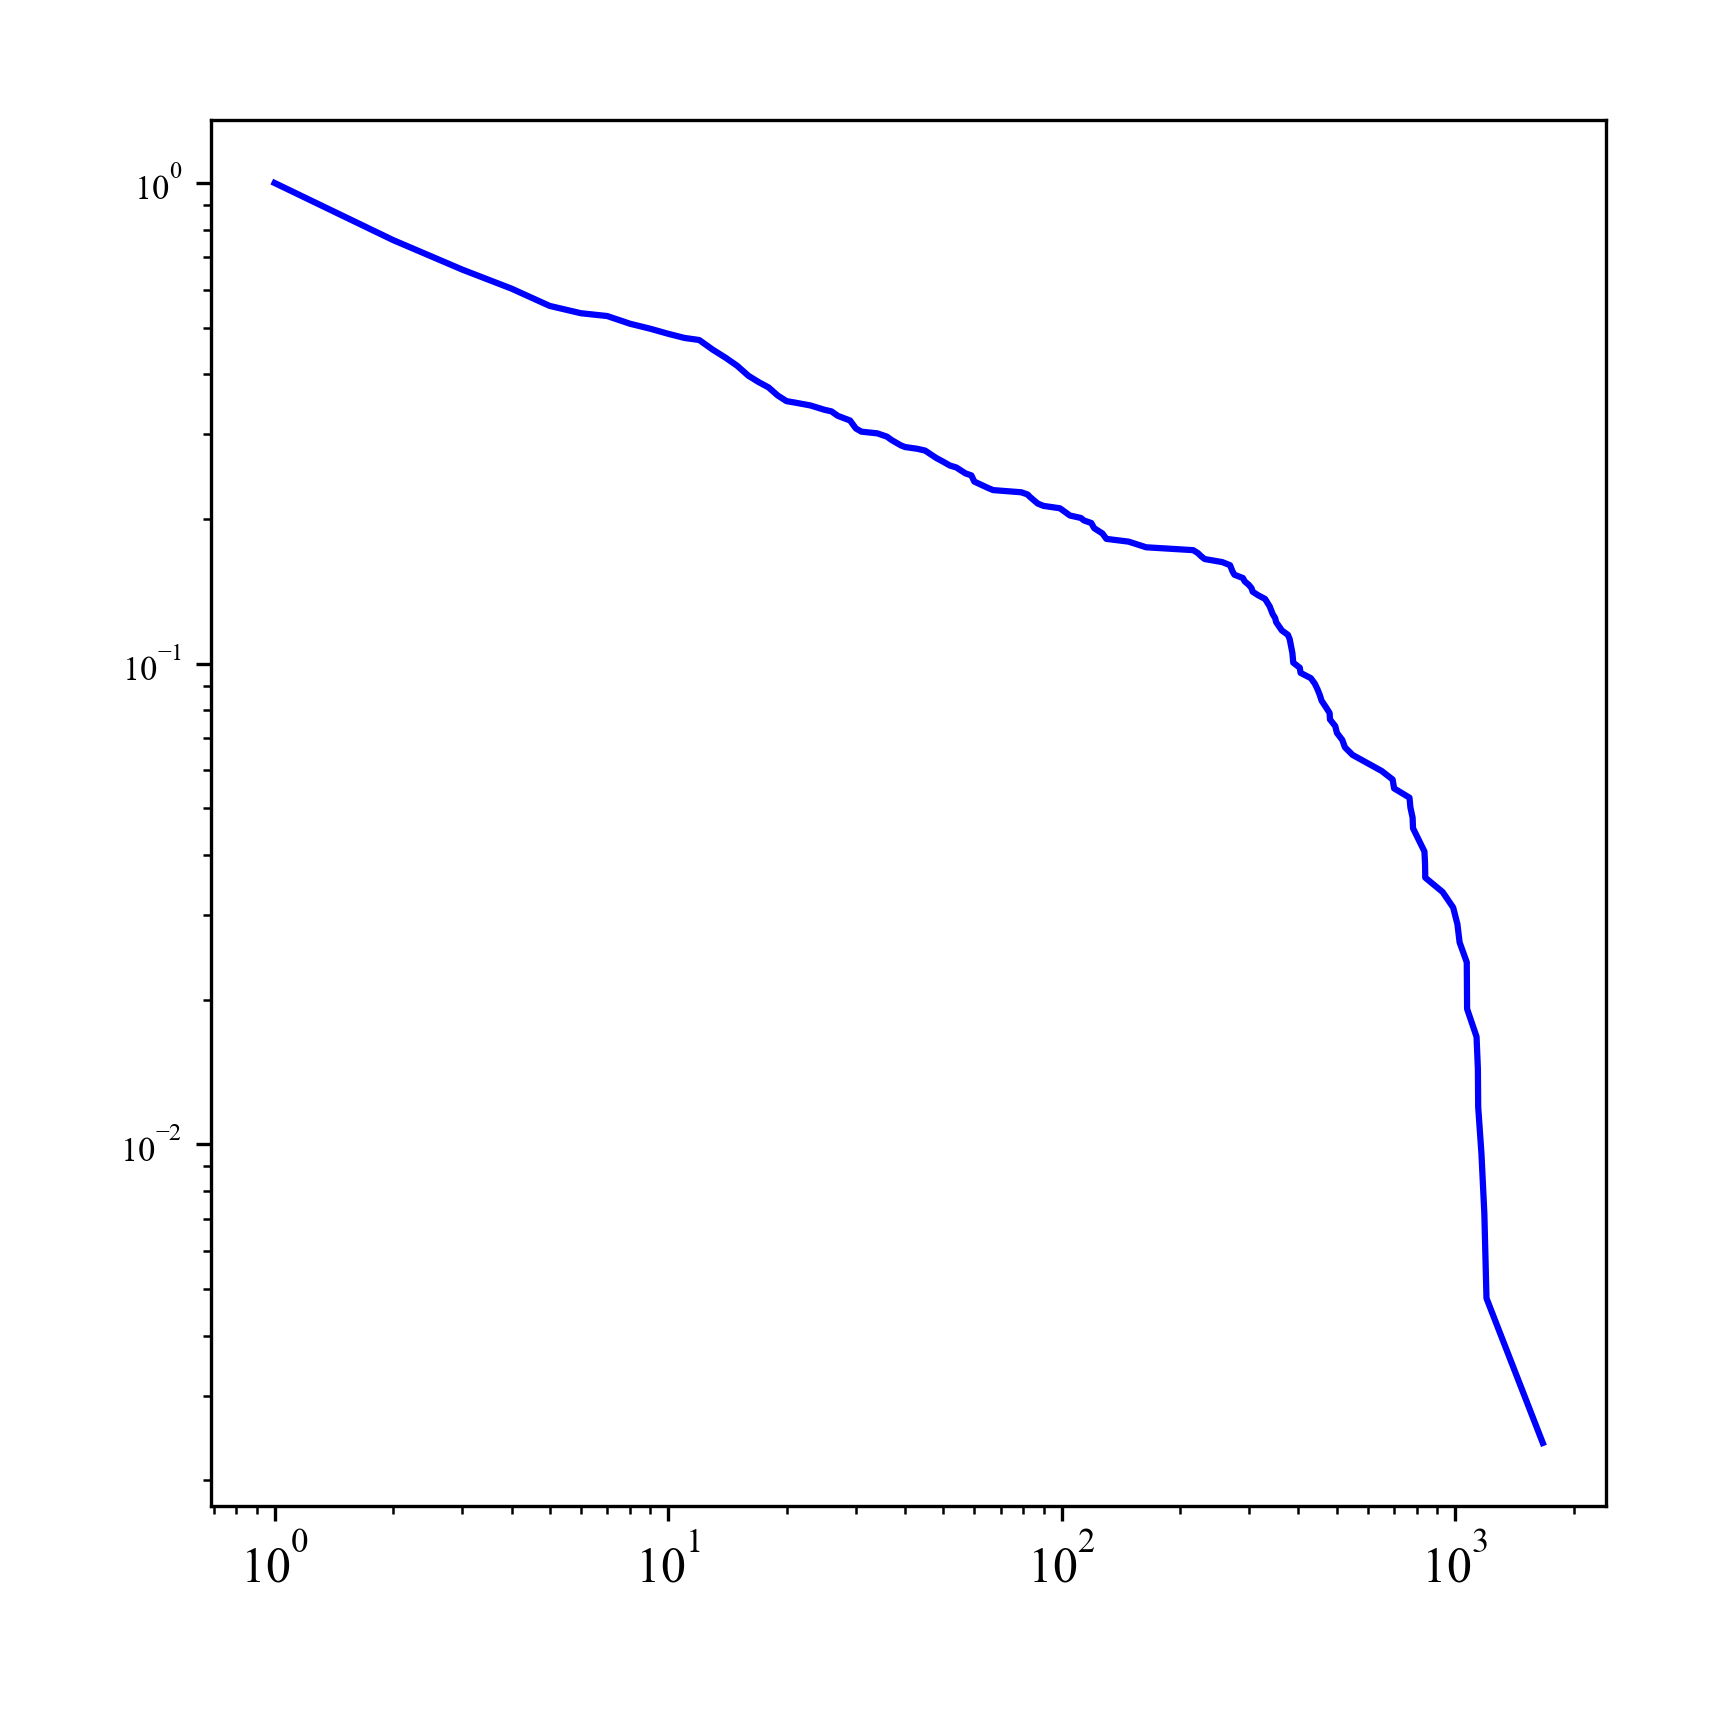

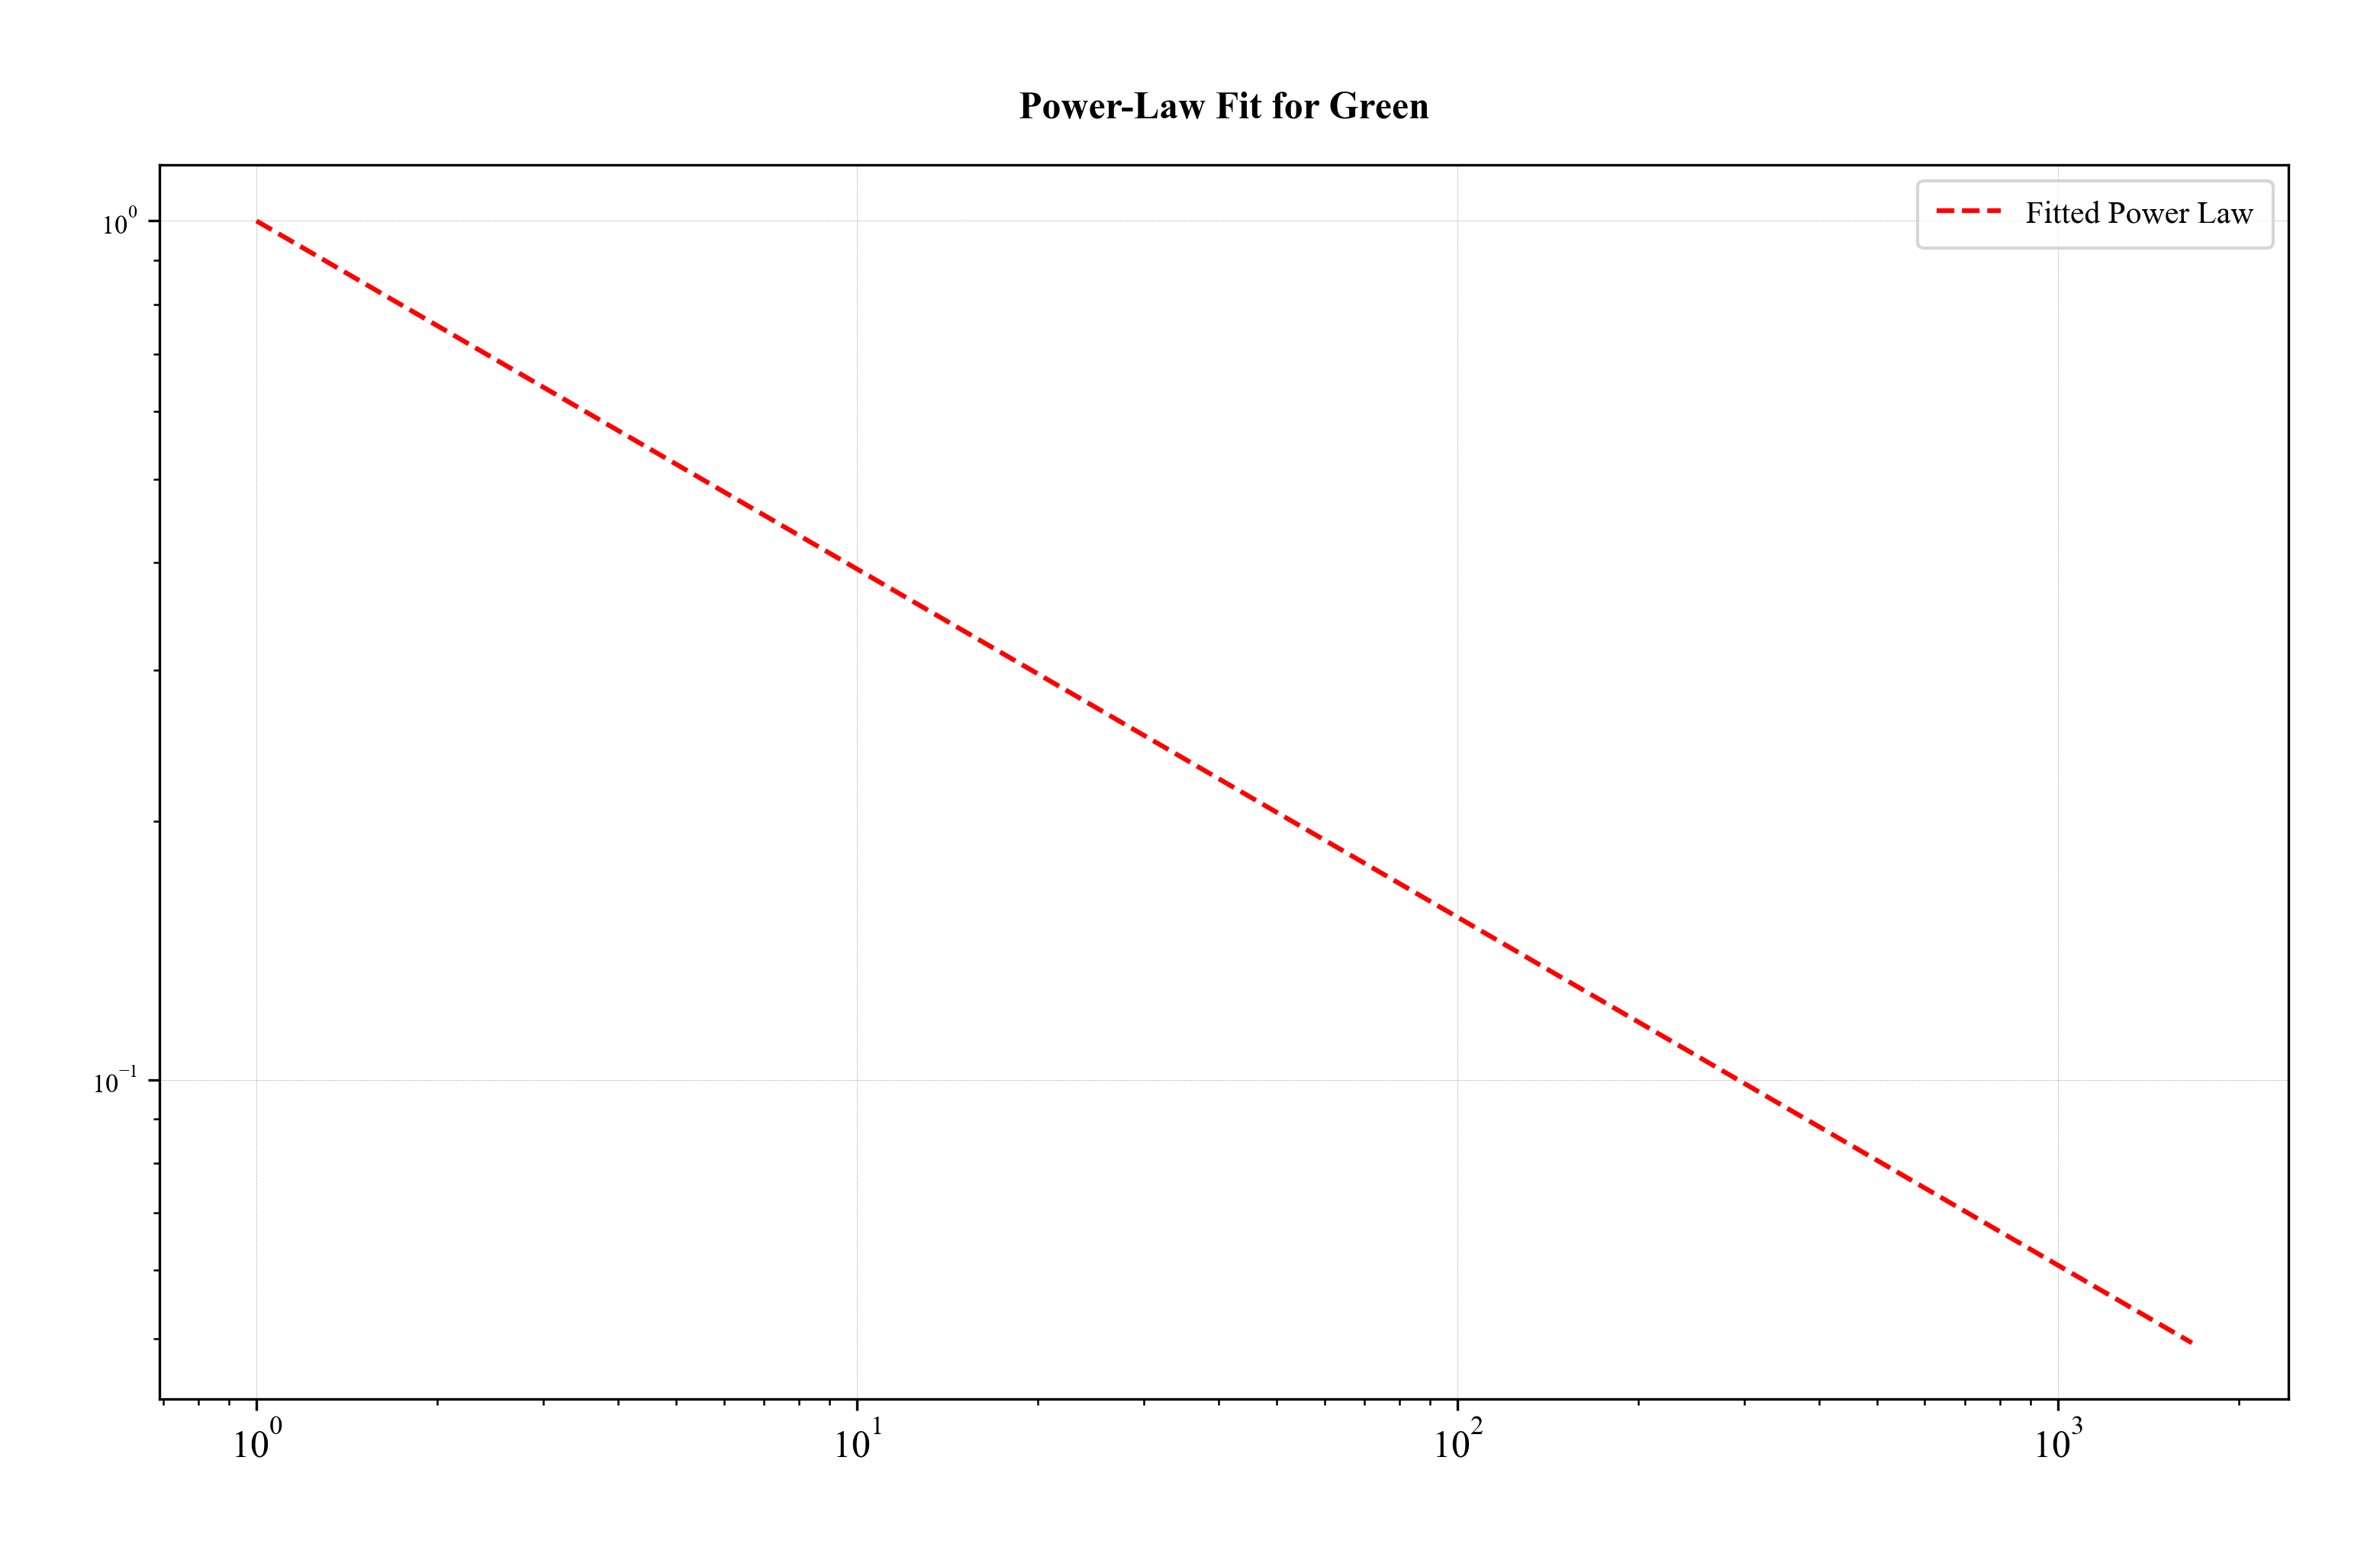


Translator: Lattimore
Power-law alpha: 10.5630, xmin: 1135.0
R (power-law vs log-normal): -0.0237, p-value: 0.4566


Calculating best minimal value for power law fit
'nan' in fit cumulative distribution values.
Likely underflow or overflow error: the optimal fit for this distribution gives values that are so extreme that we lack the numerical precision to calculate them.


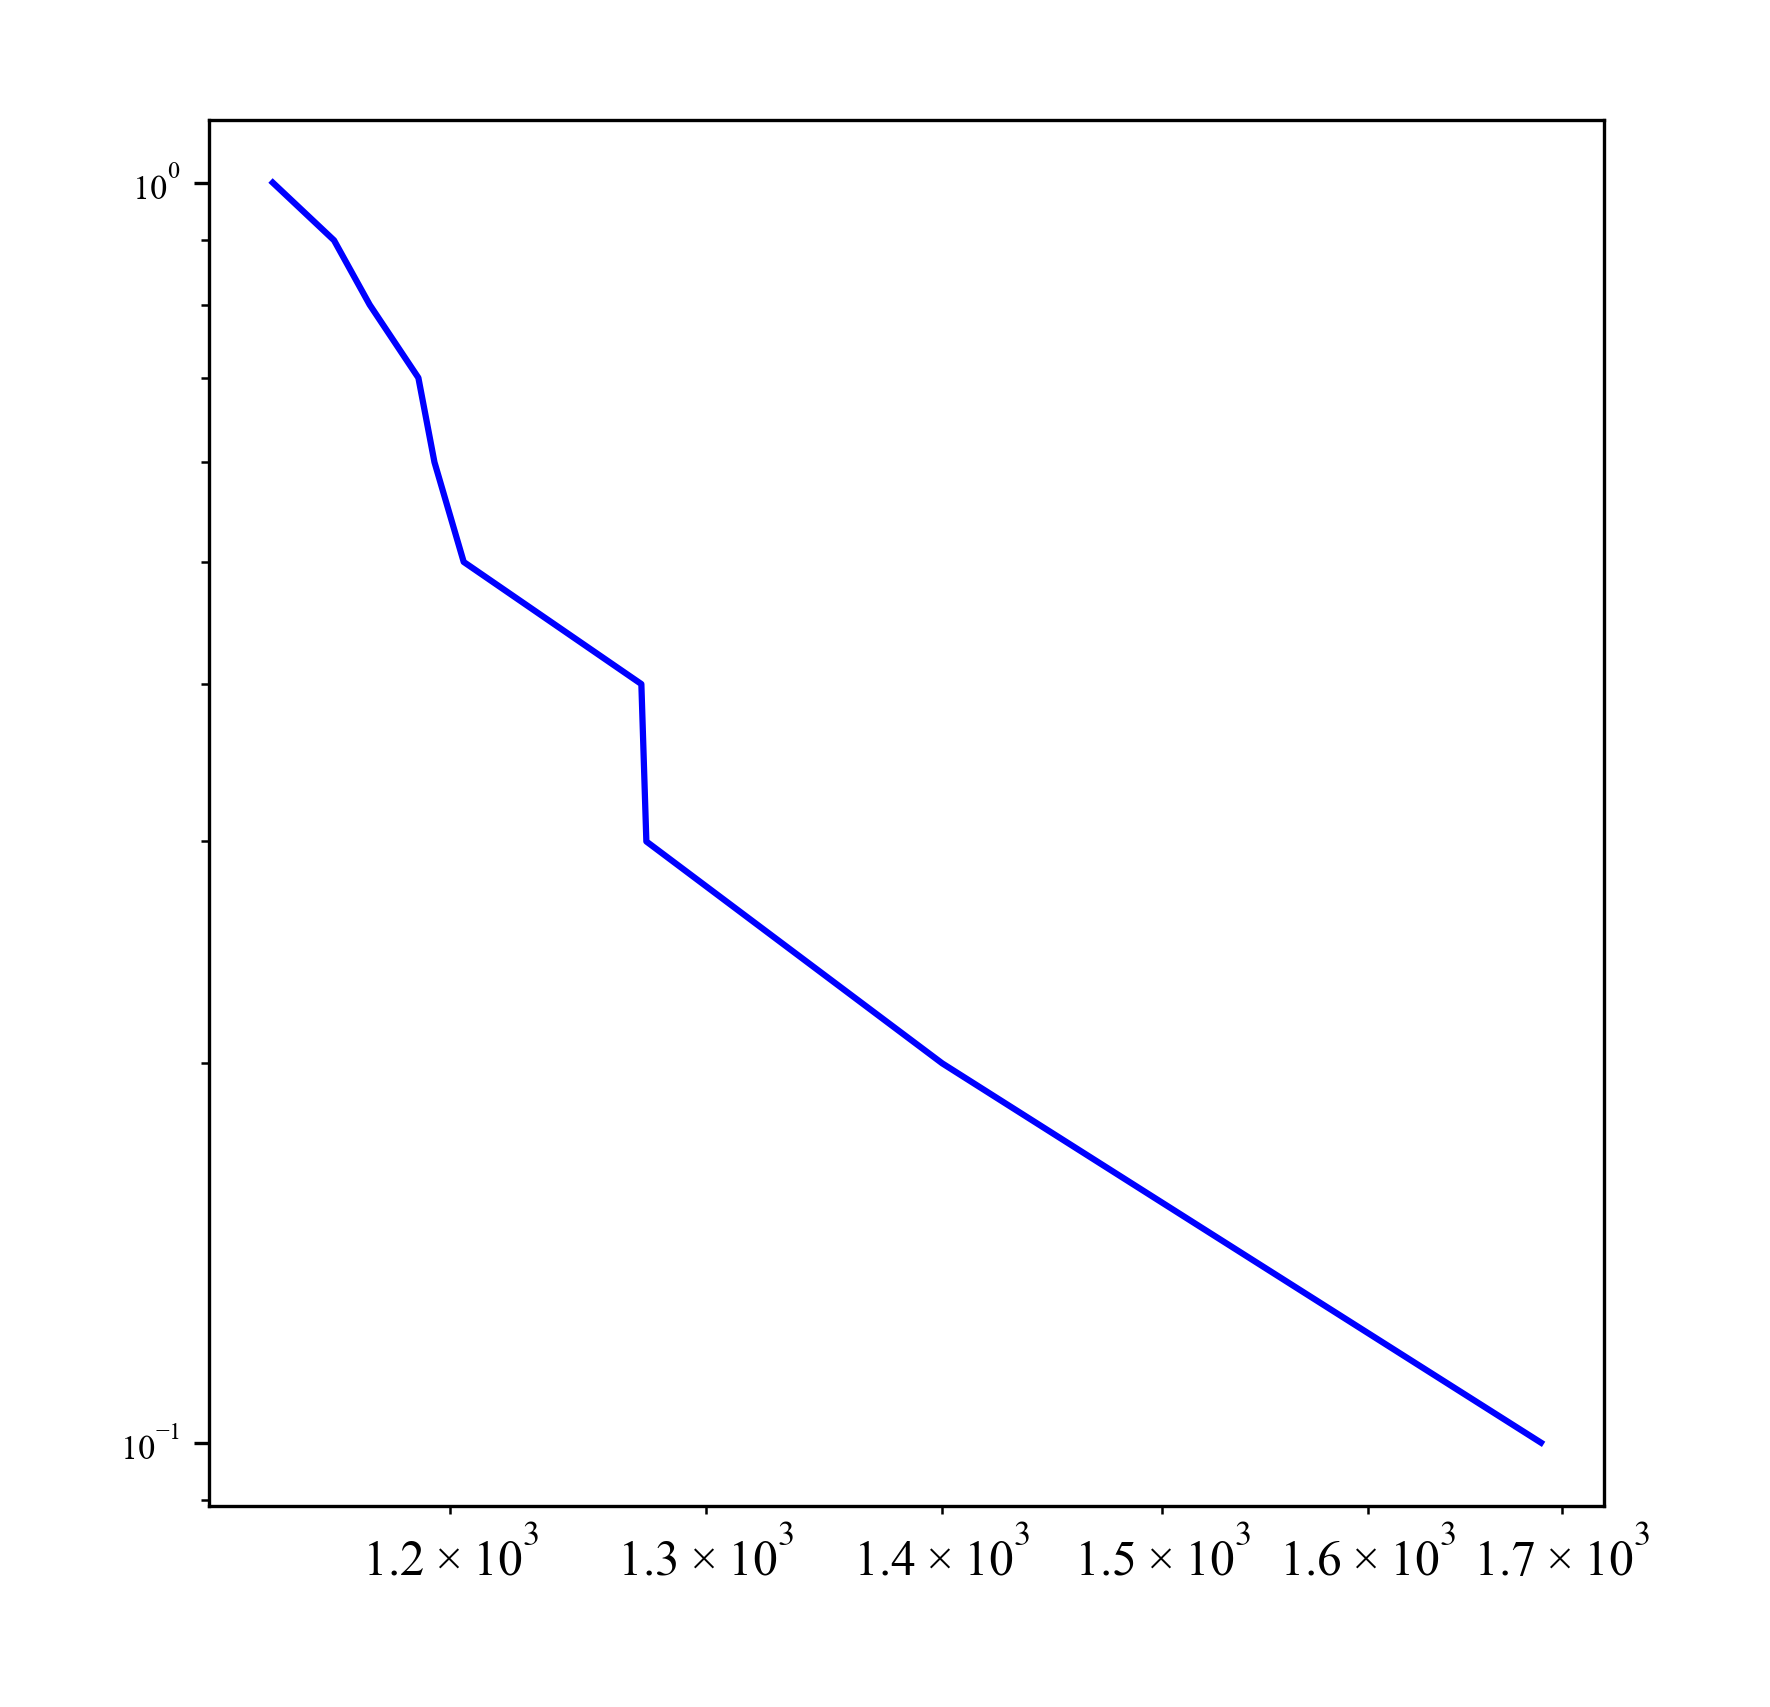

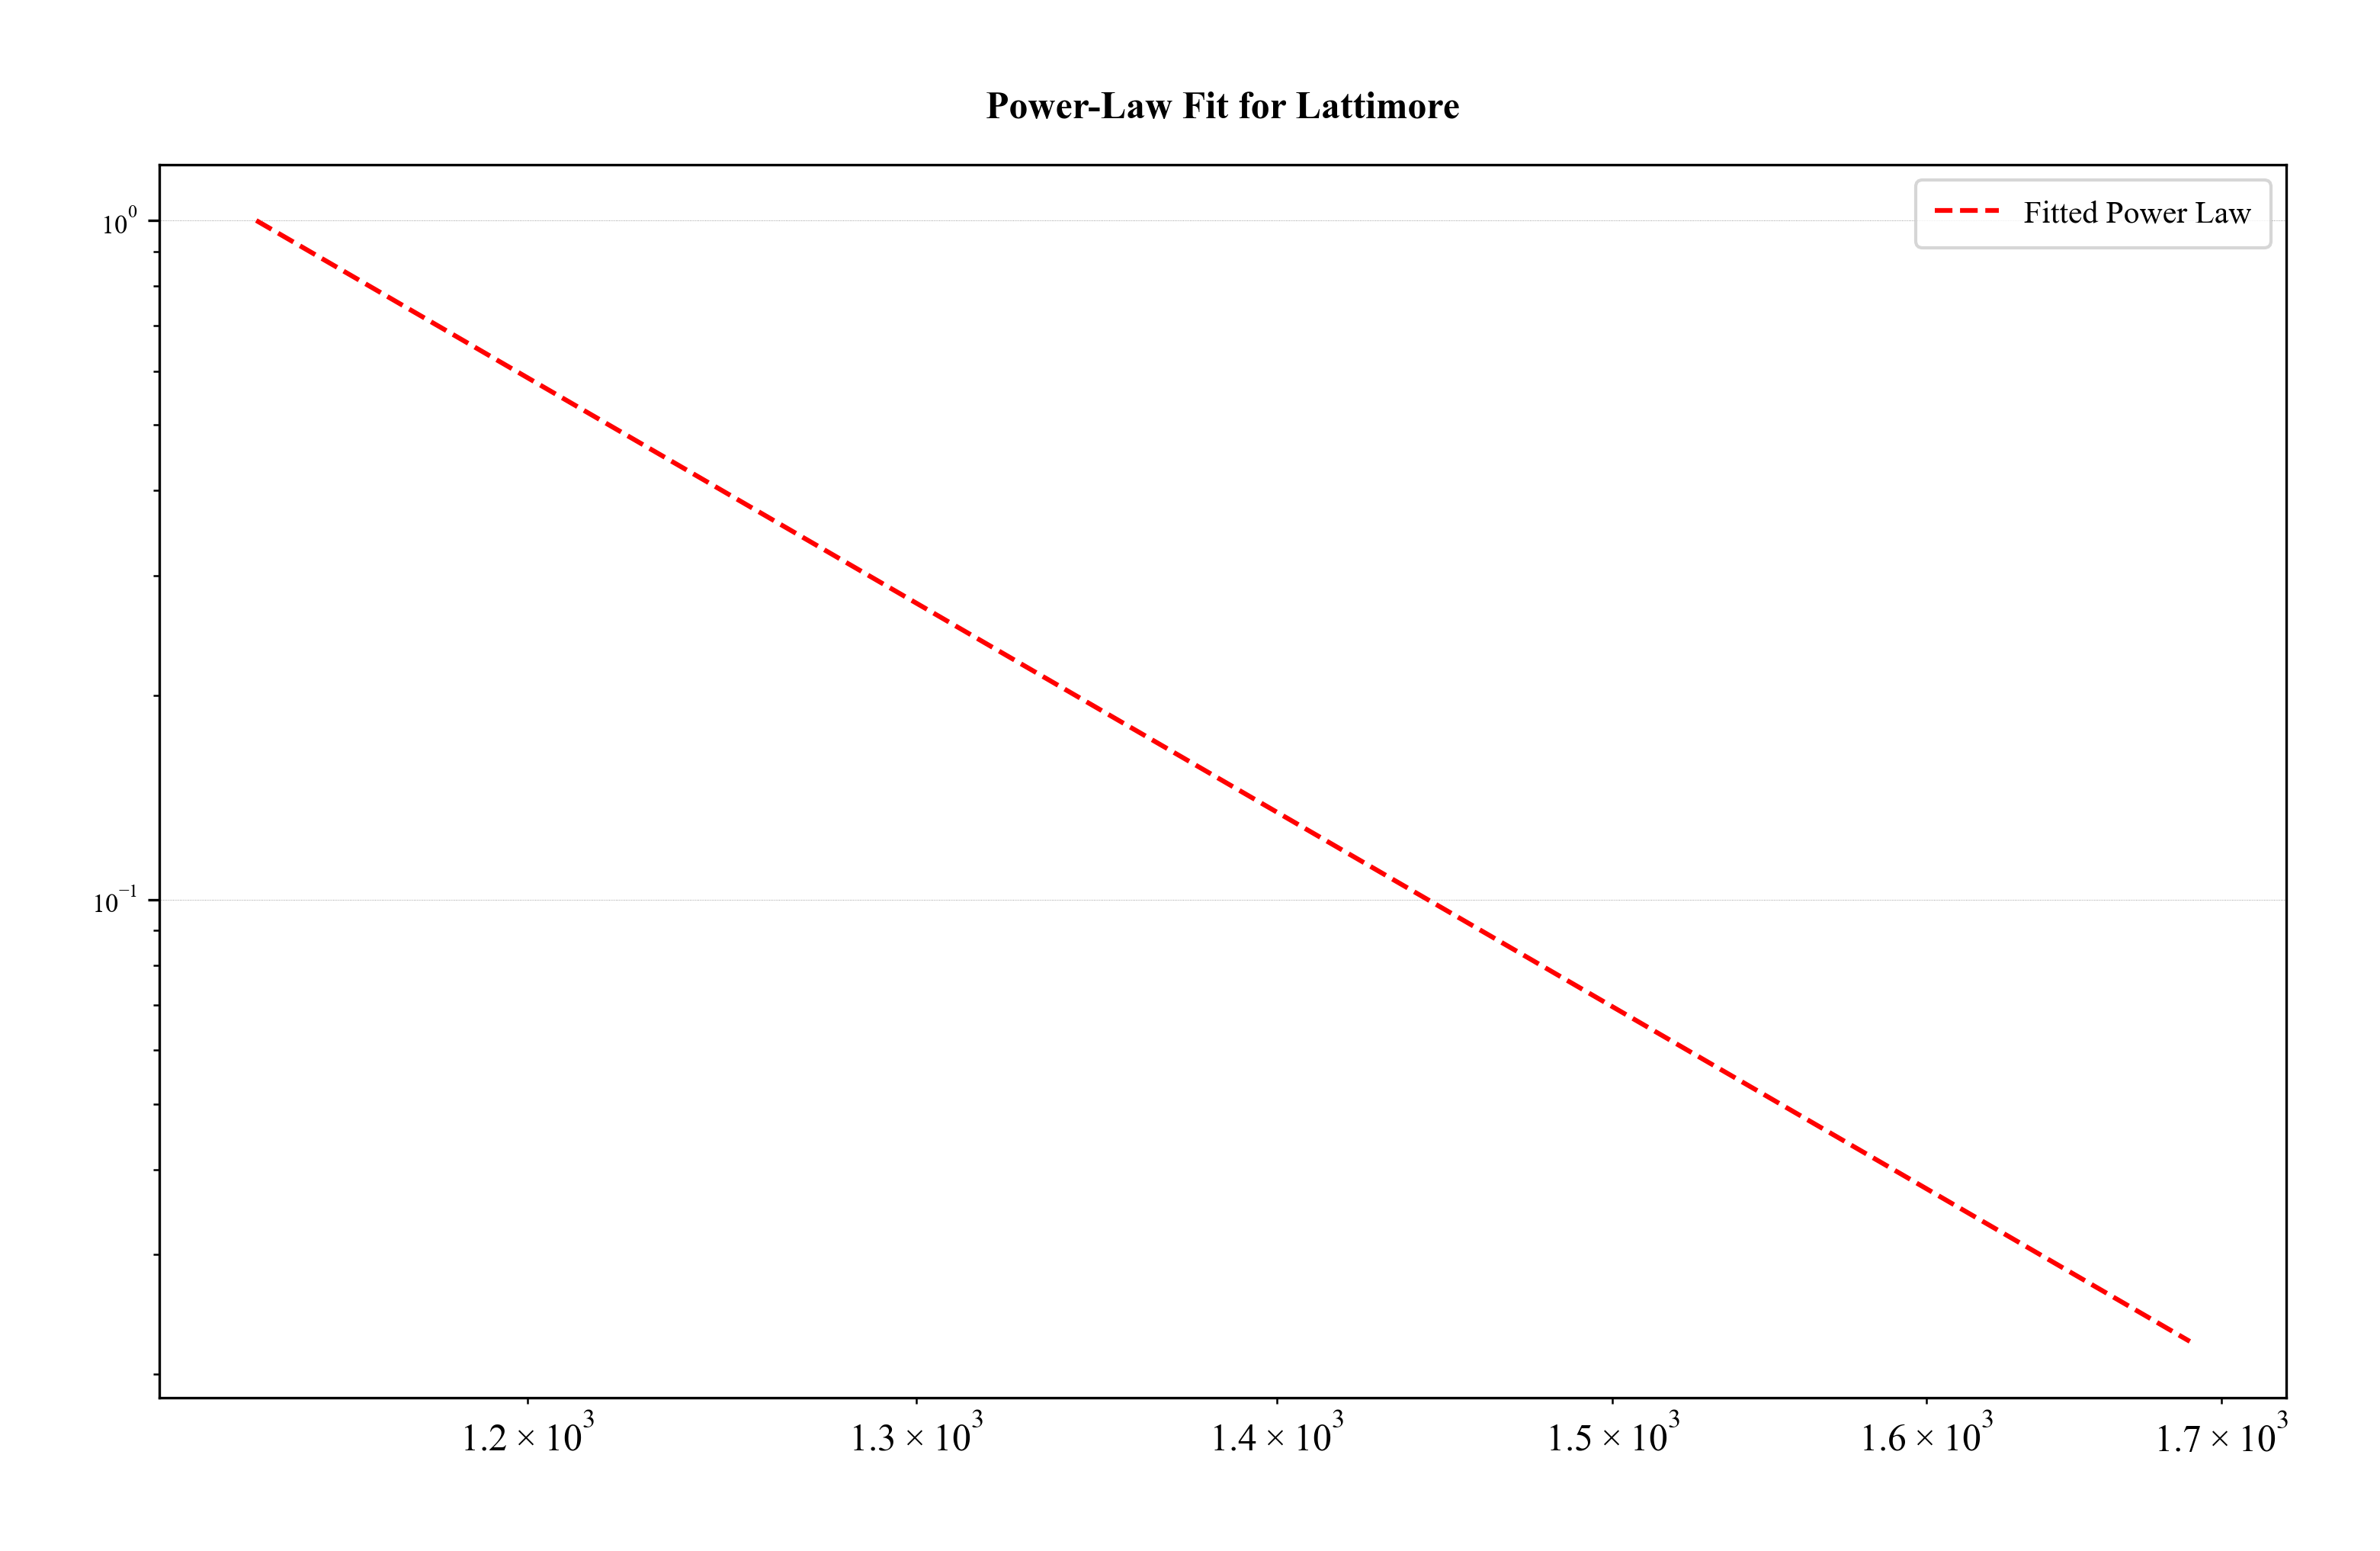


Translator: Wilson
Power-law alpha: 1.3749, xmin: 1.0
R (power-law vs log-normal): -4.8977, p-value: 0.0629


Calculating best minimal value for power law fit


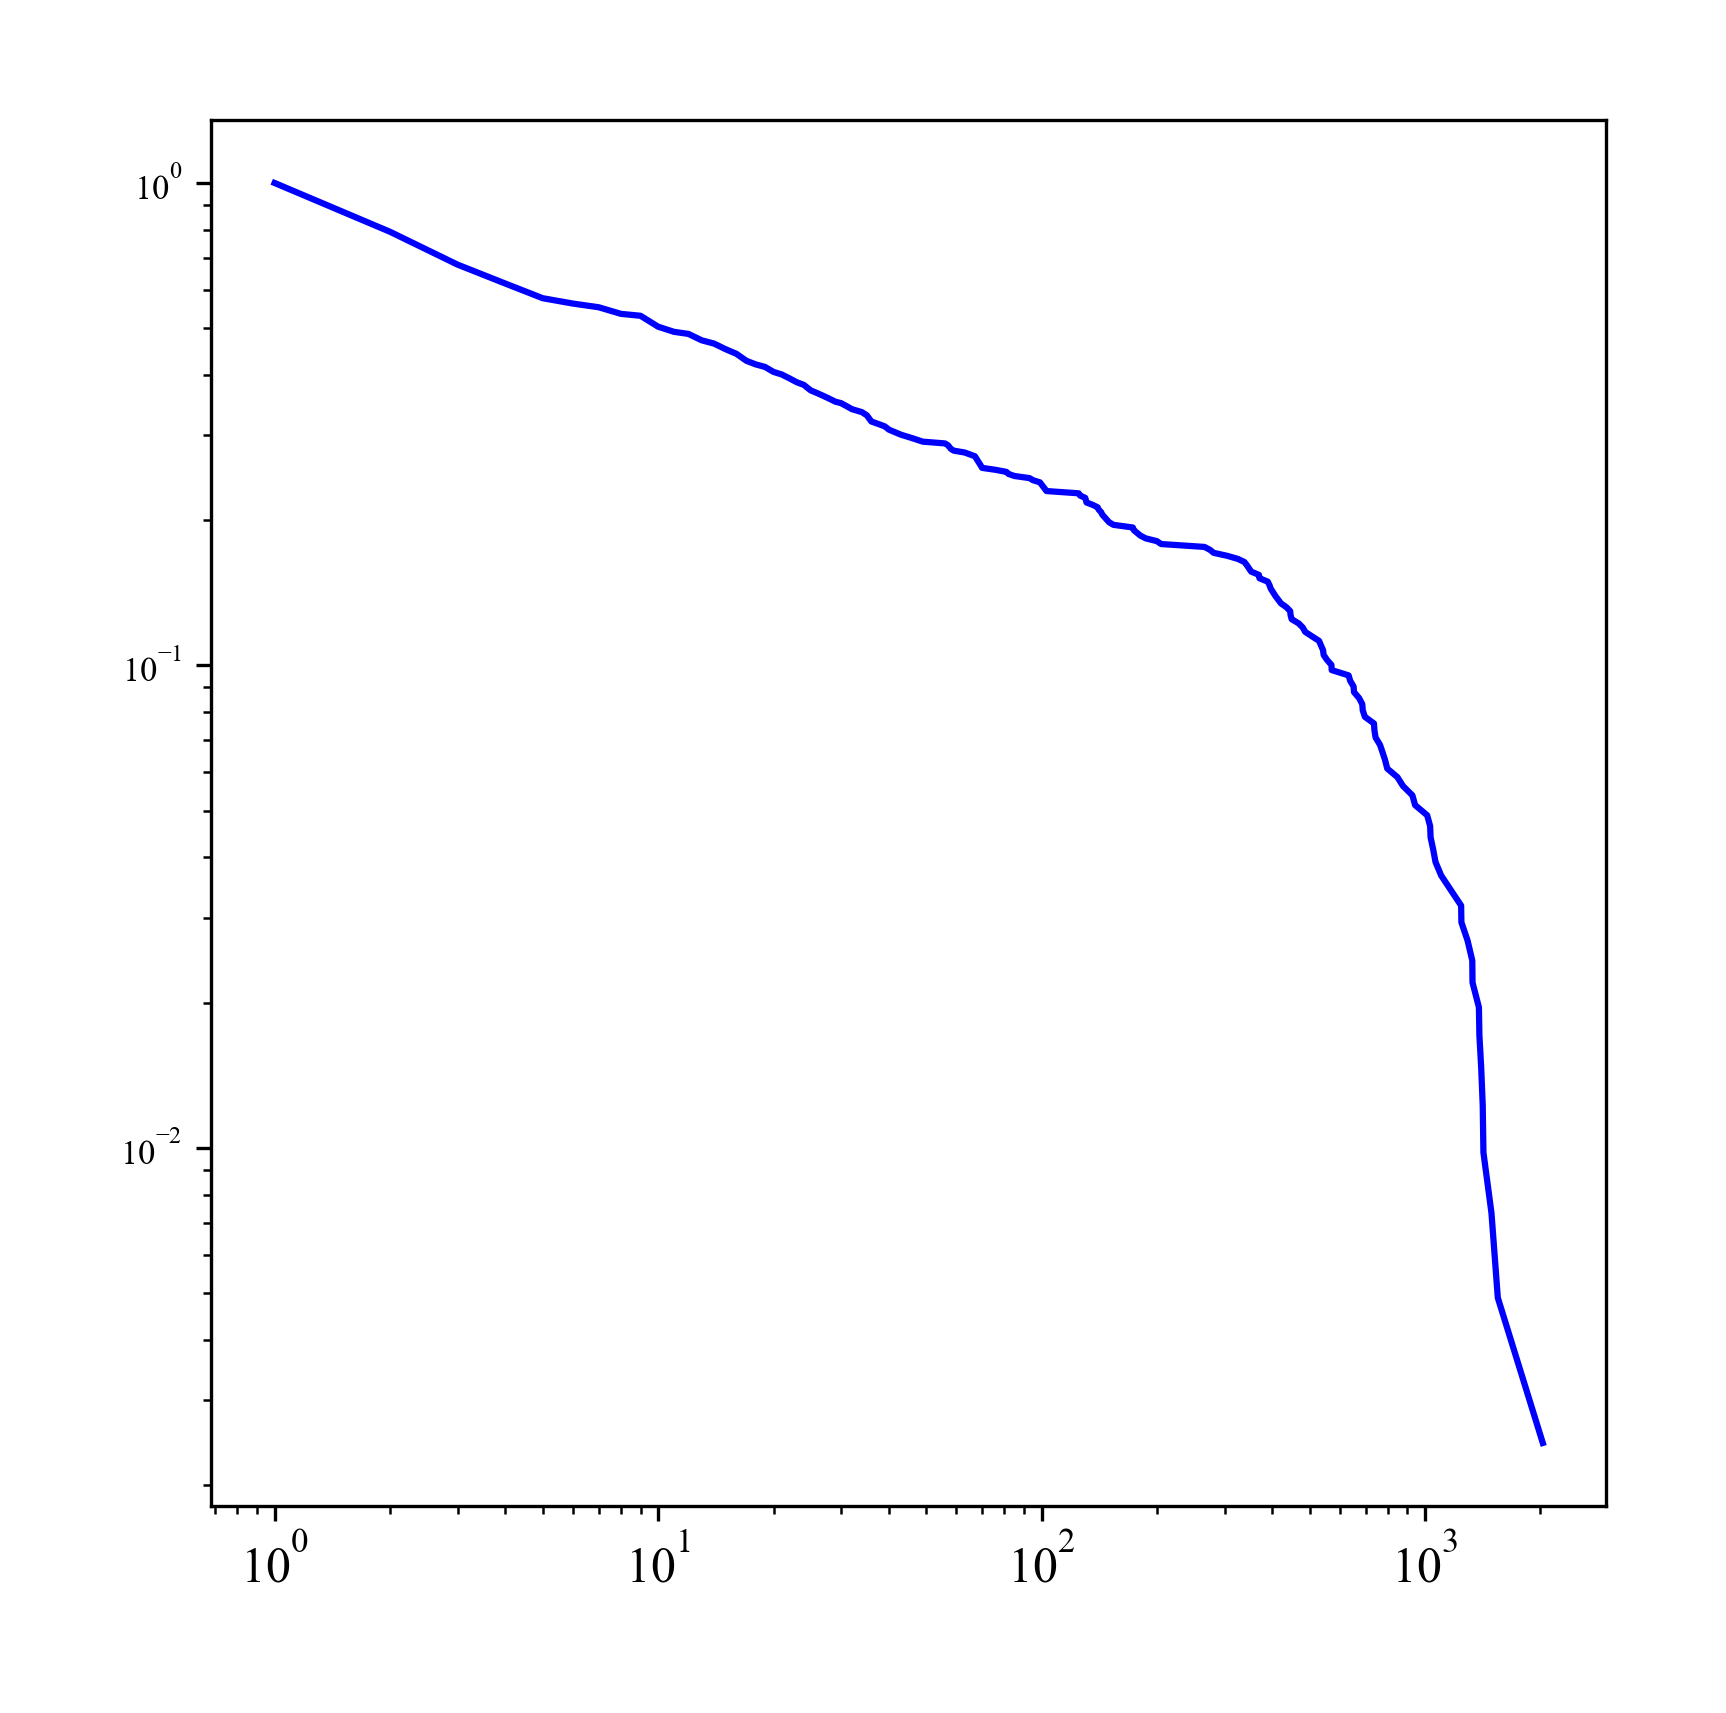

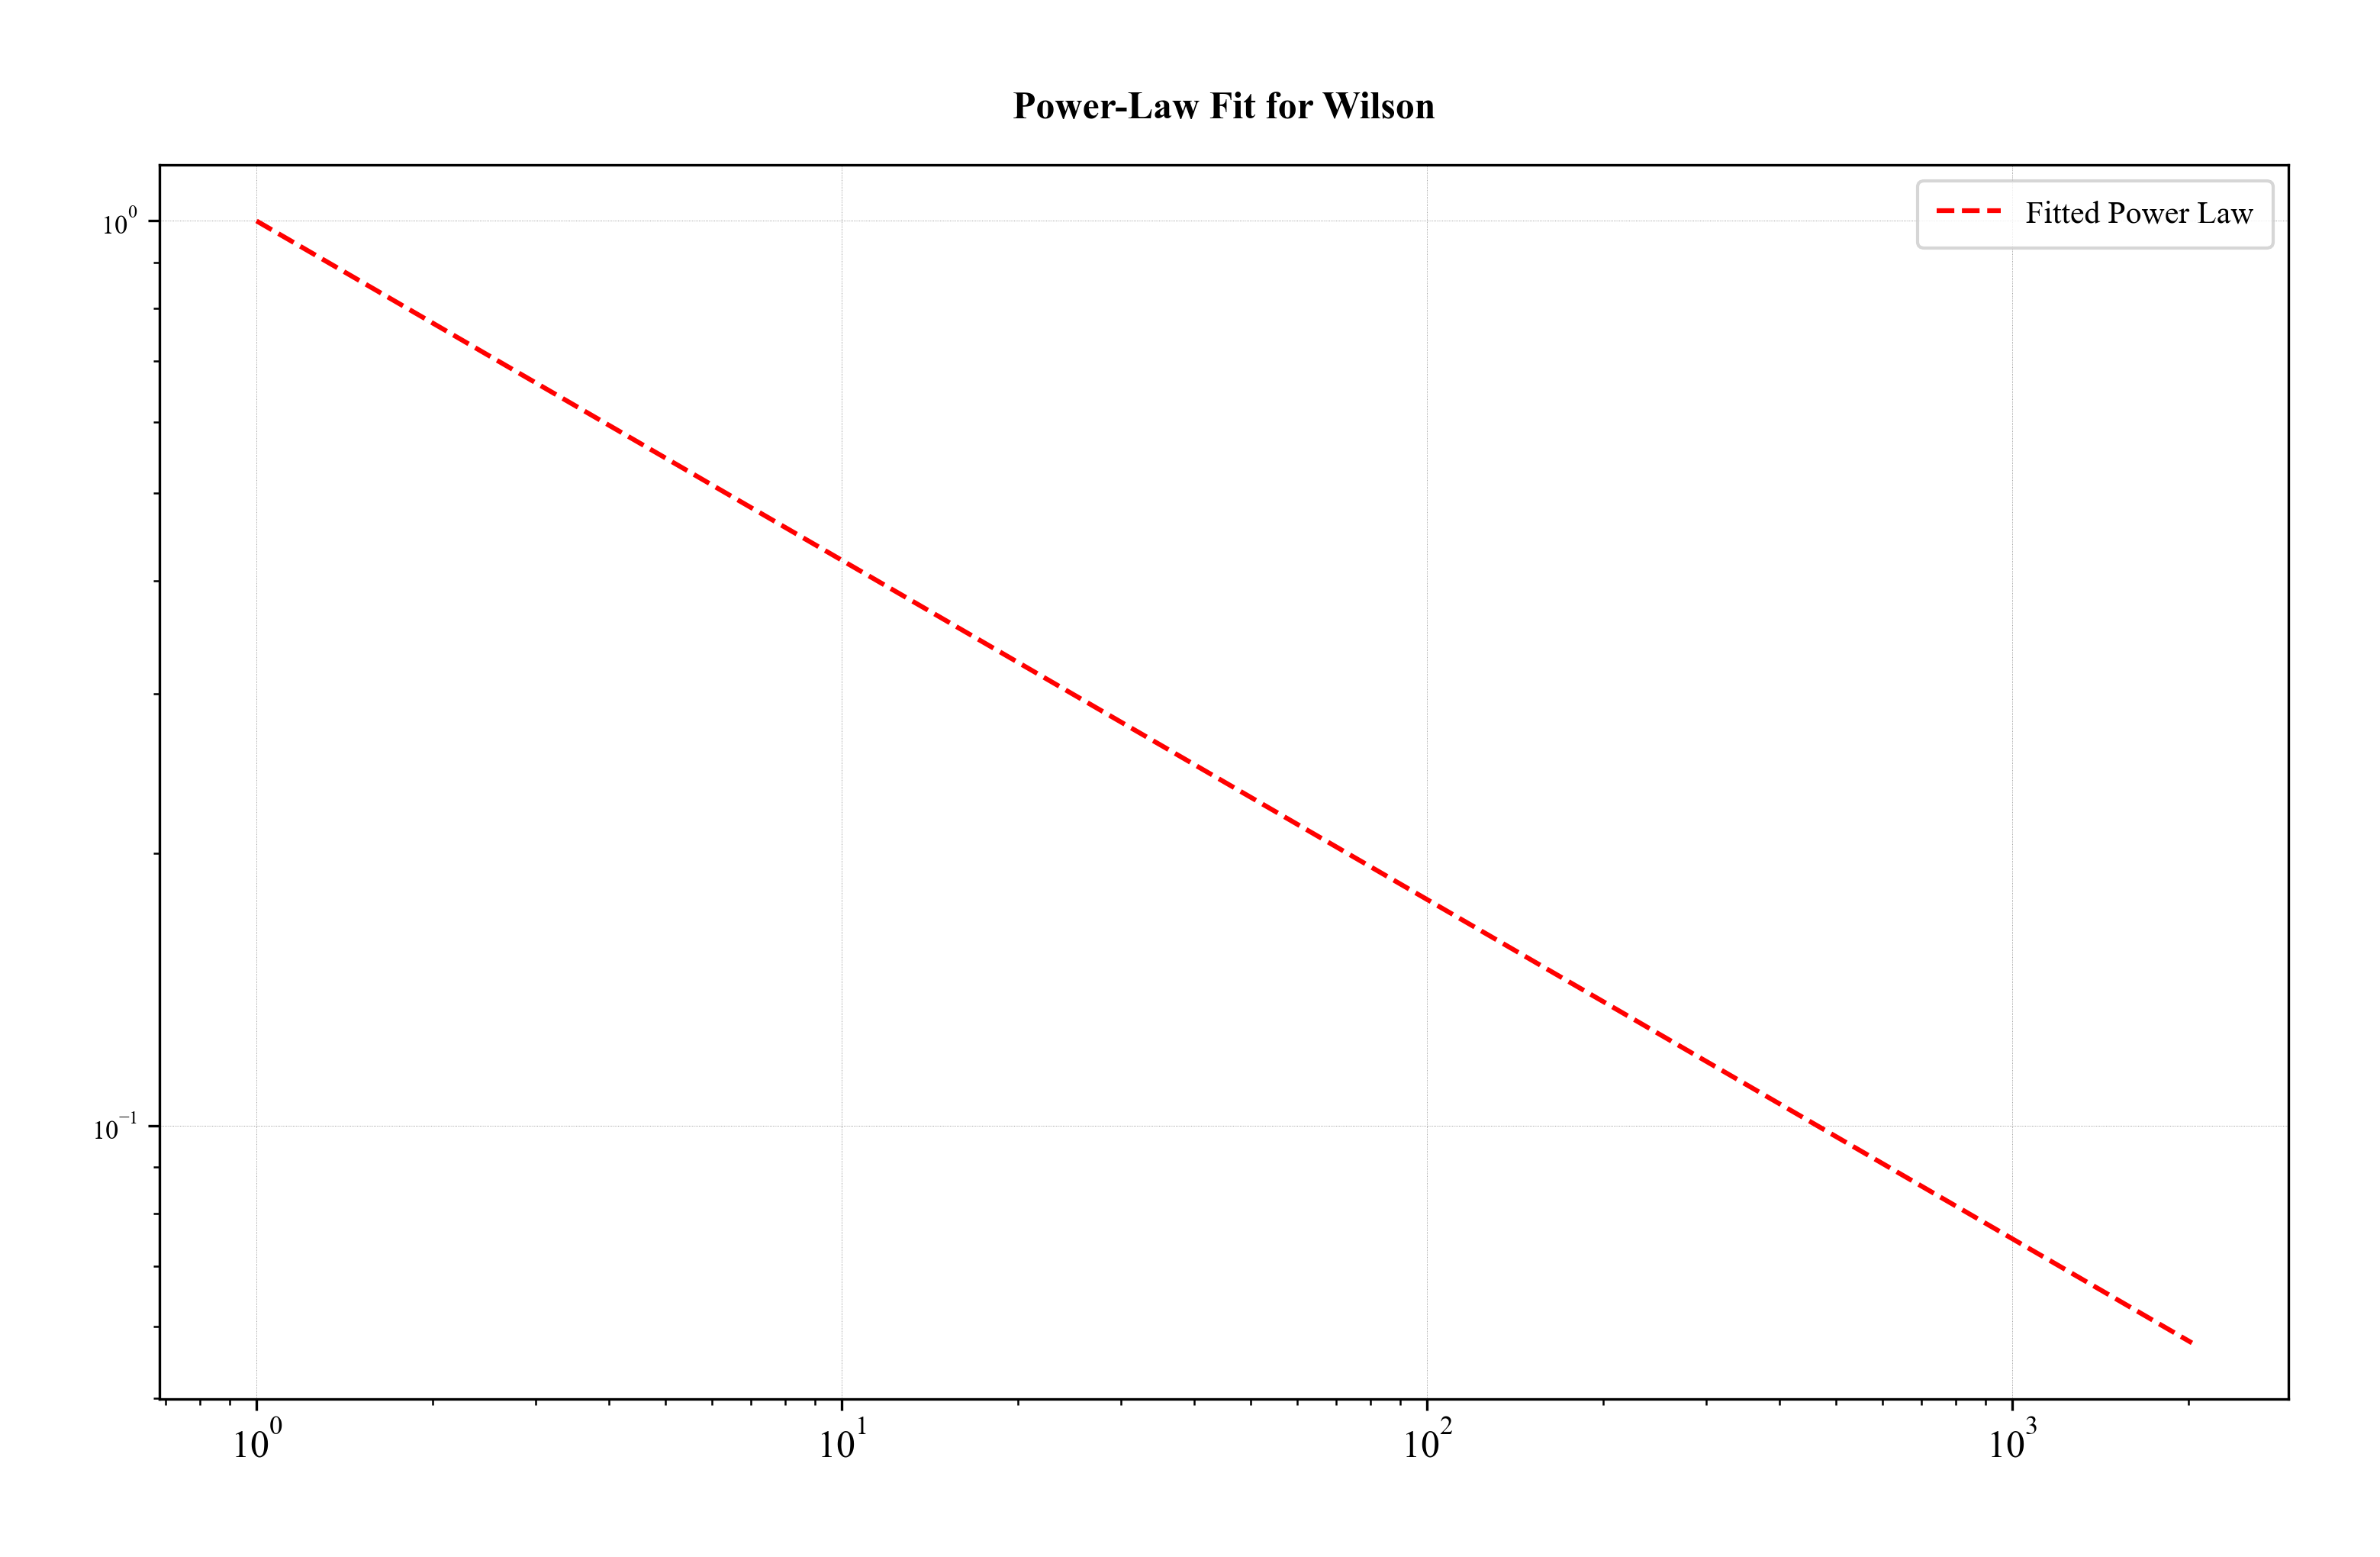

In [13]:
import numpy as np
import powerlaw
import matplotlib.pyplot as plt

def fit_power_law(odysseys_df):
    translator_groups = odysseys_df.groupby("translator")

    for translator, group in translator_groups:
        all_frequencies = []

        for counts_dict in group["ety_label_counts"]:
            all_frequencies.extend(counts_dict.values())

        all_frequencies = np.array(all_frequencies)
        all_frequencies = all_frequencies[all_frequencies > 0]  # Remove zero values

        if len(all_frequencies) > 10:
            # Fit a power-law distribution
            fit = powerlaw.Fit(all_frequencies)
            
            # Compare to other distributions
            R, p = fit.distribution_compare('power_law', 'lognormal')

            print(f"\nTranslator: {translator}")
            print(f"Power-law alpha: {fit.alpha:.4f}, xmin: {fit.xmin}")
            print(f"R (power-law vs log-normal): {R:.4f}, p-value: {p:.4f}")

            # Plot the empirical data vs fitted power-law
            plt.figure(figsize=(6, 6))
            fit.plot_ccdf(label="Empirical Data", color="blue")
            fit.power_law.plot_ccdf(label="Fitted Power Law", linestyle="dashed", color="red")
            plt.legend()
            plt.title(f"Power-Law Fit for {translator}")
            plt.grid()
            plt.show()

# Example usage:
fit_power_law(odysseys_df)

In [ ]:
import scipy.stats as stats  # Make sure we are using scipy.stats

def anova_test(odysseys_df, cat=['lat', 'ang']):
    """
    Perform ANOVA test on selected etymological categories across translators.
    Data is normalized to control for different token lengths.
    """
    translator_groups = odysseys_df.groupby("translator")
    results = {}

    for category in cat:
        category_data = []

        for translator, group in translator_groups:
            # Get total words for normalization
            total_words = group[category].sum()
            
            # Normalize to account for different token lengths
            normalized_frequencies = (group[category] / total_words).fillna(0).tolist()
            
            category_data.append(normalized_frequencies)

        # ANOVA test
        f_stat, p_value = stats.f_oneway(*category_data)

        results[category] = {  # Renamed from `stats` to `results[category]`
            "F-statistic": f_stat,
            "p-value": p_value
        }

    # Print results
    print("\nANOVA Results:")
    for category, res in results.items():  # Renamed `stats` to `res` here
        print(f"  Category: {category}")
        print(f"    F-statistic: {res['F-statistic']:.4f}")
        print(f"    p-value: {res['p-value']}")

        if res["p-value"] < 0.05:
            print("    🔴 Reject H₀: Significant difference detected!")
        else:
            print("    ✅ Fail to reject H₀: No significant difference.")

# Example usage:
anova_test(df_ety_freq, cat=['eng', 'lat', 'ang'])


ANOVA Results:
  Category: eng
    F-statistic: -4.2874085126346015e-31
    p-value: nan
    ✅ Fail to reject H₀: No significant difference.
  Category: lat
    F-statistic: 2.1166263481549108e-31
    p-value: 1.0
    ✅ Fail to reject H₀: No significant difference.
  Category: ang
    F-statistic: -9.832534211566578e-32
    p-value: nan
    ✅ Fail to reject H₀: No significant difference.


In [21]:
from scipy.stats import kruskal

def kruskal_test(odysseys_df, cat=['lat', 'ang']):
    """
    Perform Kruskal-Wallis test (non-parametric ANOVA alternative).
    """
    translator_groups = odysseys_df.groupby("translator")
    results = {}

    for category in cat:
        category_data = [group[category].dropna().tolist() for _, group in translator_groups]

        if all(len(data) > 1 for data in category_data):  # Ensure enough data
            H_stat, p_value = kruskal(*category_data)
            results[category] = {"H-statistic": H_stat, "p-value": p_value}

    # Print results
    print("\nKruskal-Wallis Test Results:")
    for category, res in results.items():
        print(f"  Category: {category}")
        print(f"    H-statistic: {res['H-statistic']:.4f}")
        print(f"    p-value: {res['p-value']}") 

        if res["p-value"] < 0.05:
            print("    🔴 Reject H₀: Significant difference detected!")
        else:
            print("    ✅ Fail to reject H₀: No significant difference.")

# Example usage:
kruskal_test(df_ety_freq, cat=['eng', 'enm', 'lat', 'ang', 'cym'])


Kruskal-Wallis Test Results:
  Category: eng
    H-statistic: 26.9141
    p-value: 5.9282989502531344e-05
    🔴 Reject H₀: Significant difference detected!
  Category: enm
    H-statistic: 16.7641
    p-value: 0.004969711788640016
    🔴 Reject H₀: Significant difference detected!
  Category: lat
    H-statistic: 34.3541
    p-value: 2.0241321586837036e-06
    🔴 Reject H₀: Significant difference detected!
  Category: ang
    H-statistic: 32.3935
    p-value: 4.964929810322901e-06
    🔴 Reject H₀: Significant difference detected!
  Category: cym
    H-statistic: 4.6476
    p-value: 0.46038339745539214
    ✅ Fail to reject H₀: No significant difference.


In [10]:
# # Single book analysis
# oz.plot_etymology_counts(my_df, "Murray", book_range=1)

# # Multiple books
# oz.plot_etymology_counts(my_df, "Murray", book_range=[1, 5, 9])

# # Range of books
# oz.plot_etymology_counts(my_df, "Butler", book_range=(1, 5))

# # Compare translators
# oz.plot_etymology_comparison(my_df, ["Murray", "Butler", "Pope"], book_num=1)

# # Create heatmap visualization
# oz.plot_etymology_heatmap(my_df, "Murray", book_range=(1, 24))

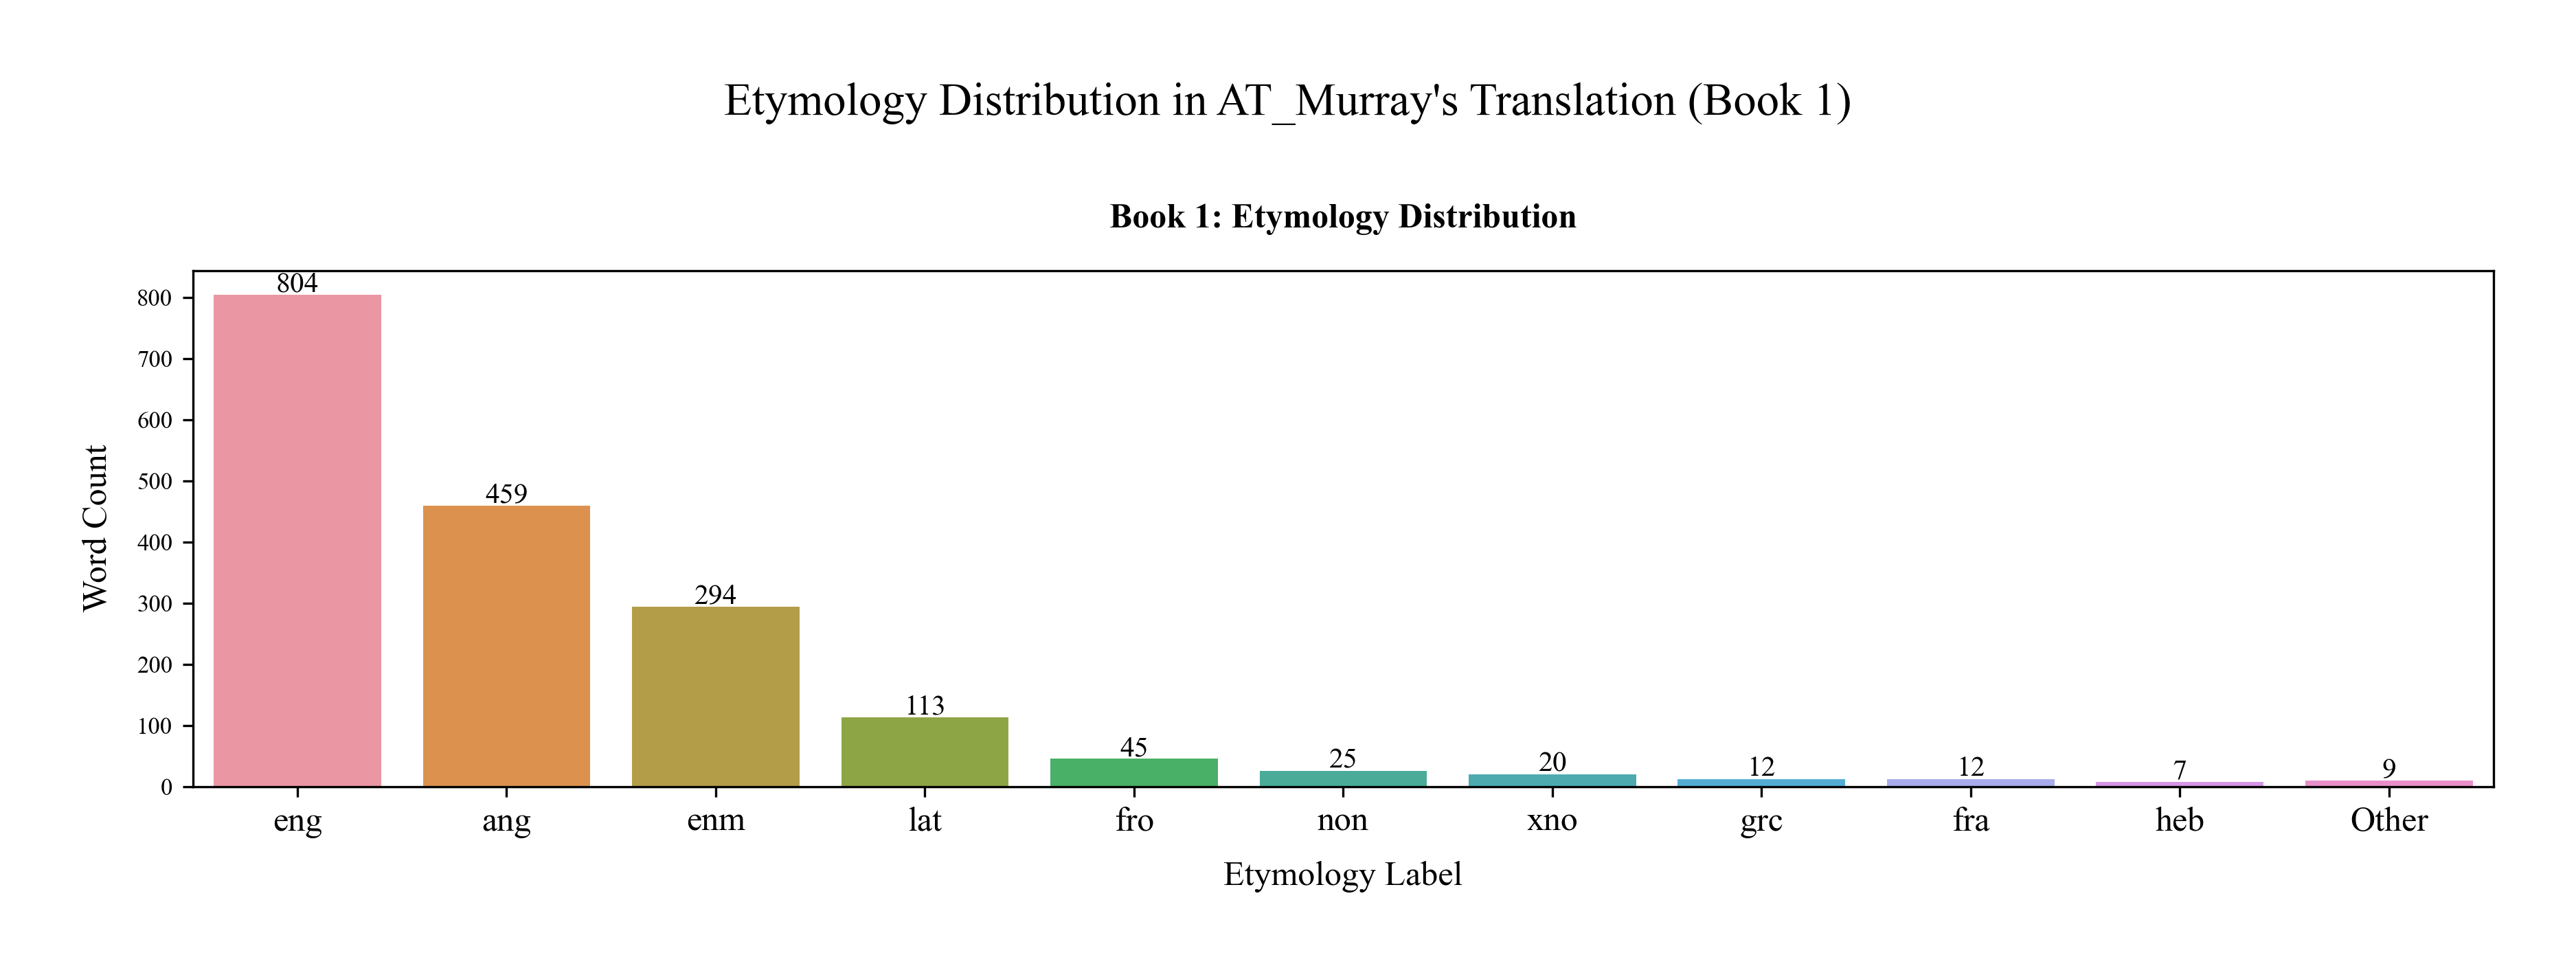

In [11]:
specific_colors = [chroma.color_palette["astroblue"], 
                   chroma.color_palette["orange"], 
                   chroma.color_palette["genoa"],
                   chroma.color_palette["carrot"], 
                   chroma.color_palette["tawny"],
                   chroma.color_palette["neptune"],
                   chroma.color_palette["jazzberry"],
                   chroma.color_palette["mako"]]

fig = oz.plot_etymology_counts(odysseys_df, "AT_Murray", 
                               book_range=1)

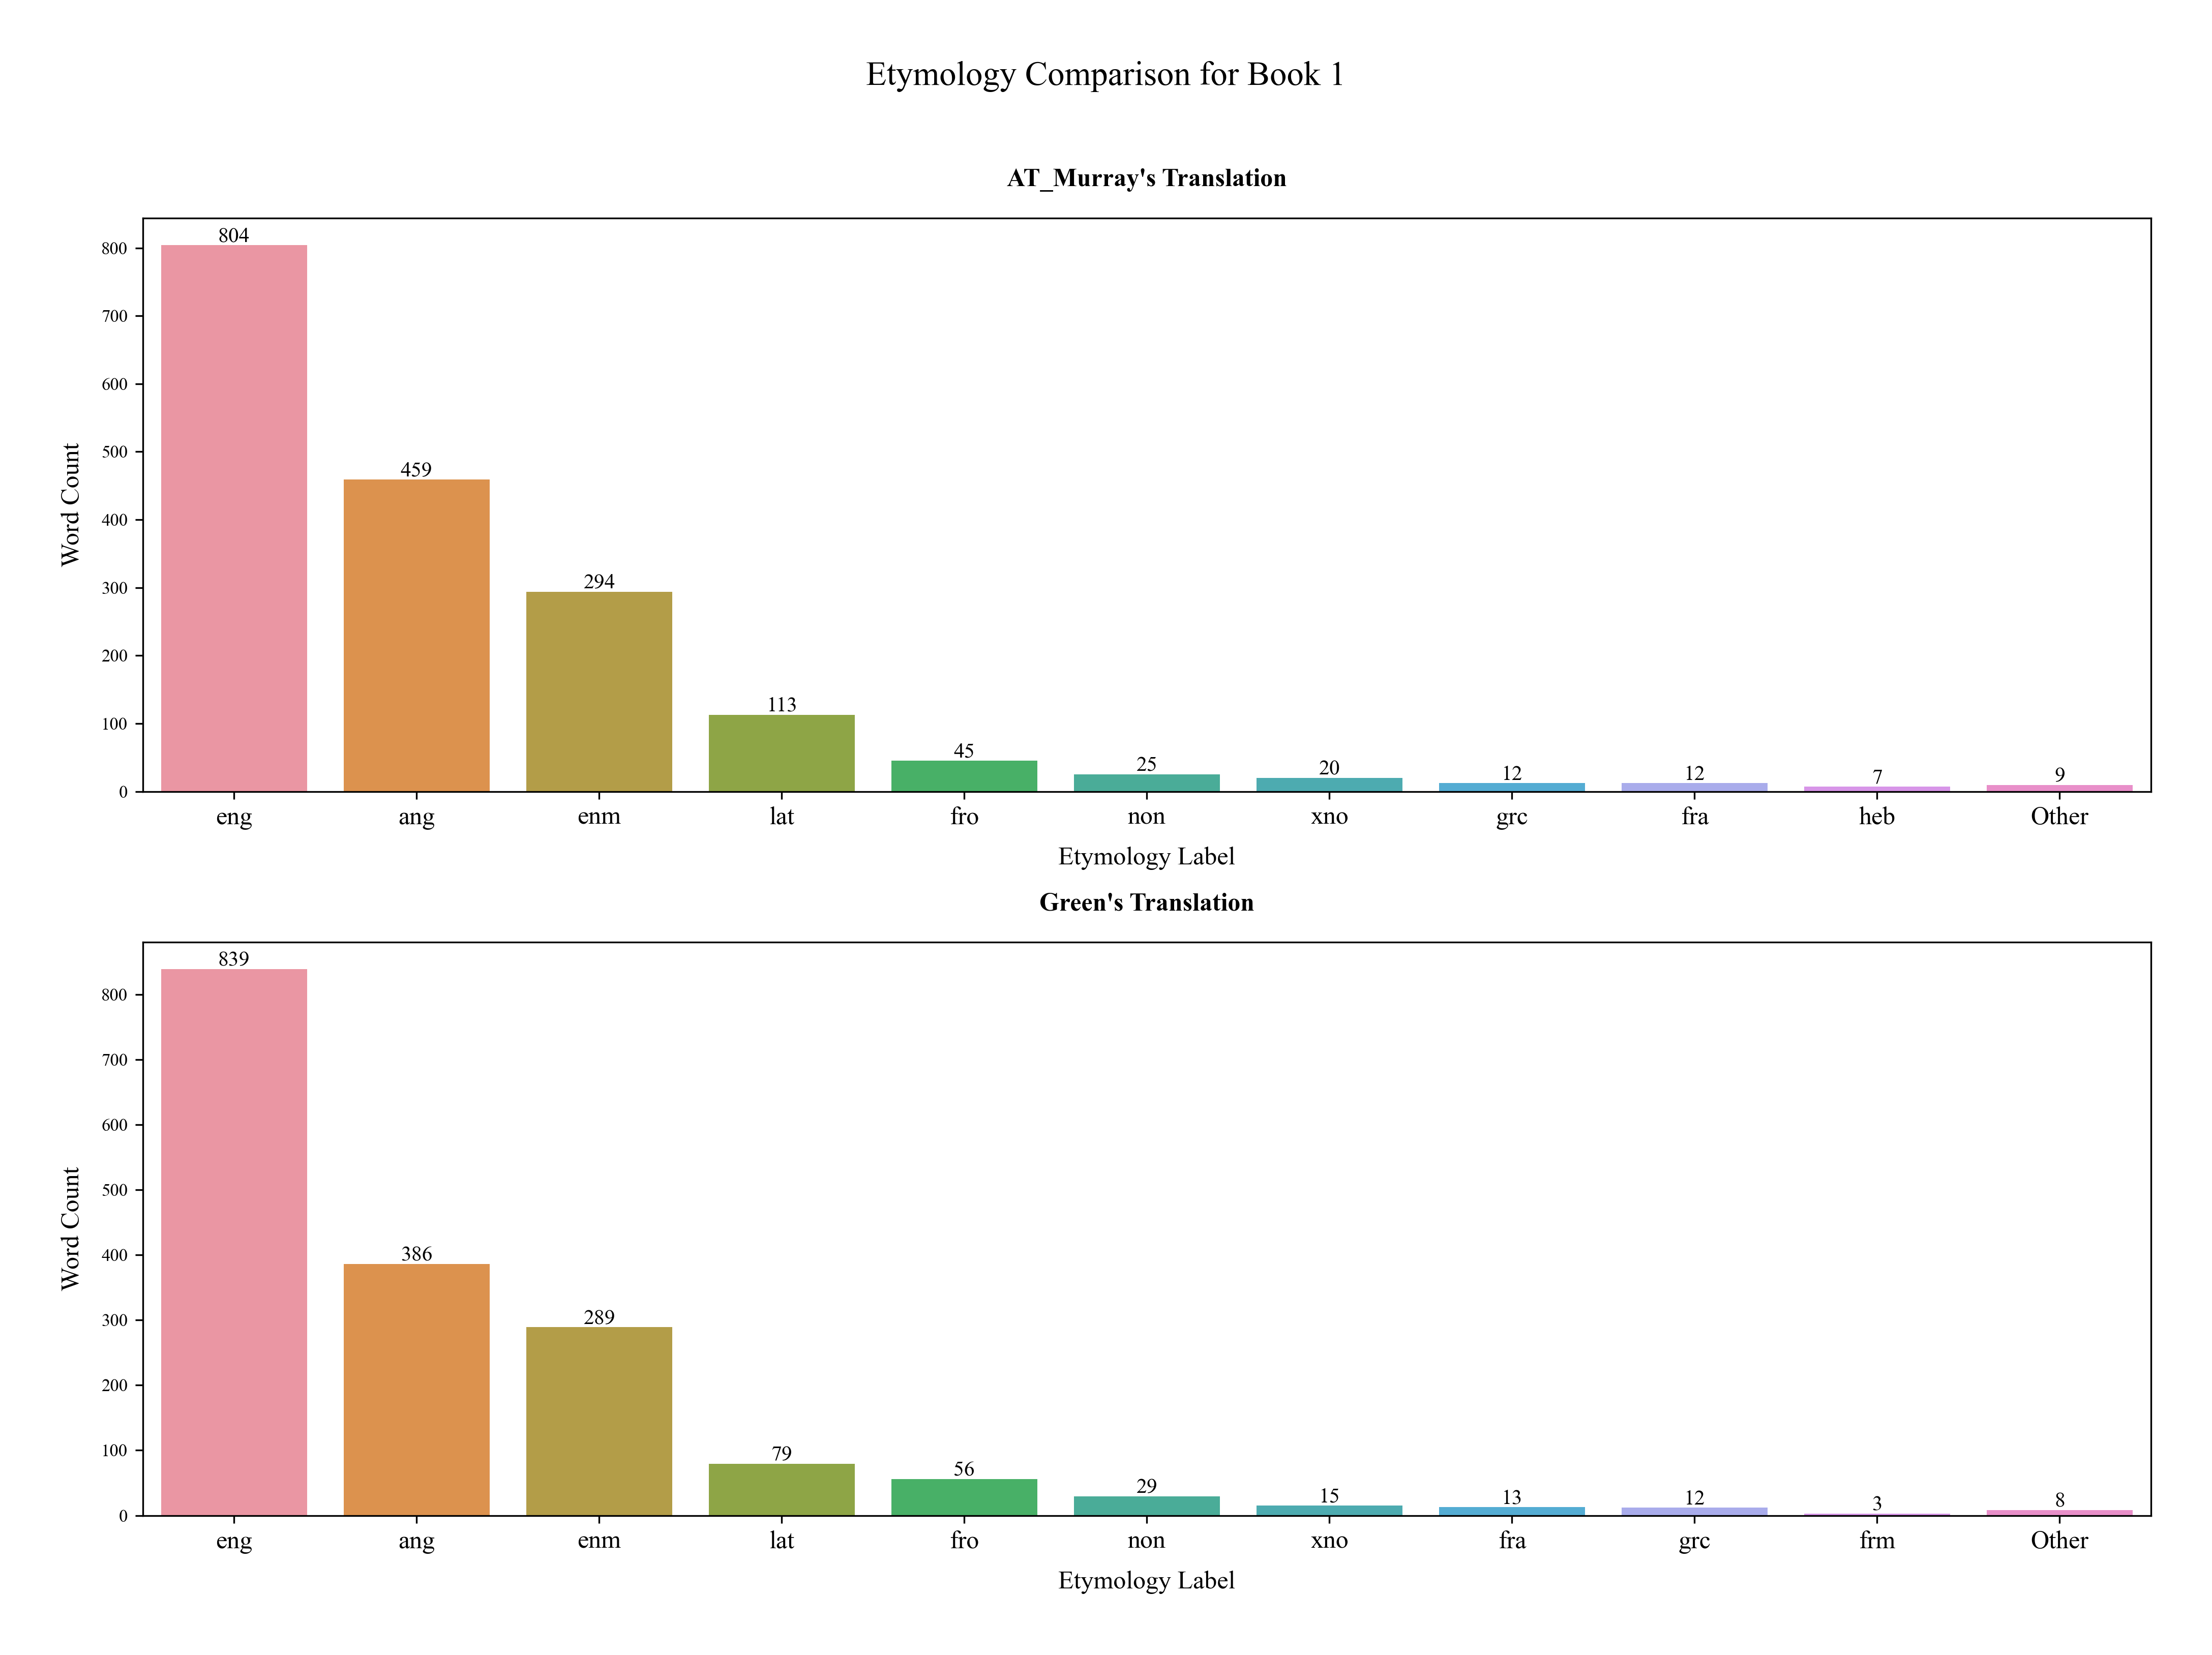

In [12]:

fig = oz.plot_etymology_comparison(odysseys_df, ["AT_Murray", "Green"], book_num=1)
fig.savefig(f"{output_path_plots}/ety_comparison_Murray_Butler_Pope_Book_1.png", dpi=300)


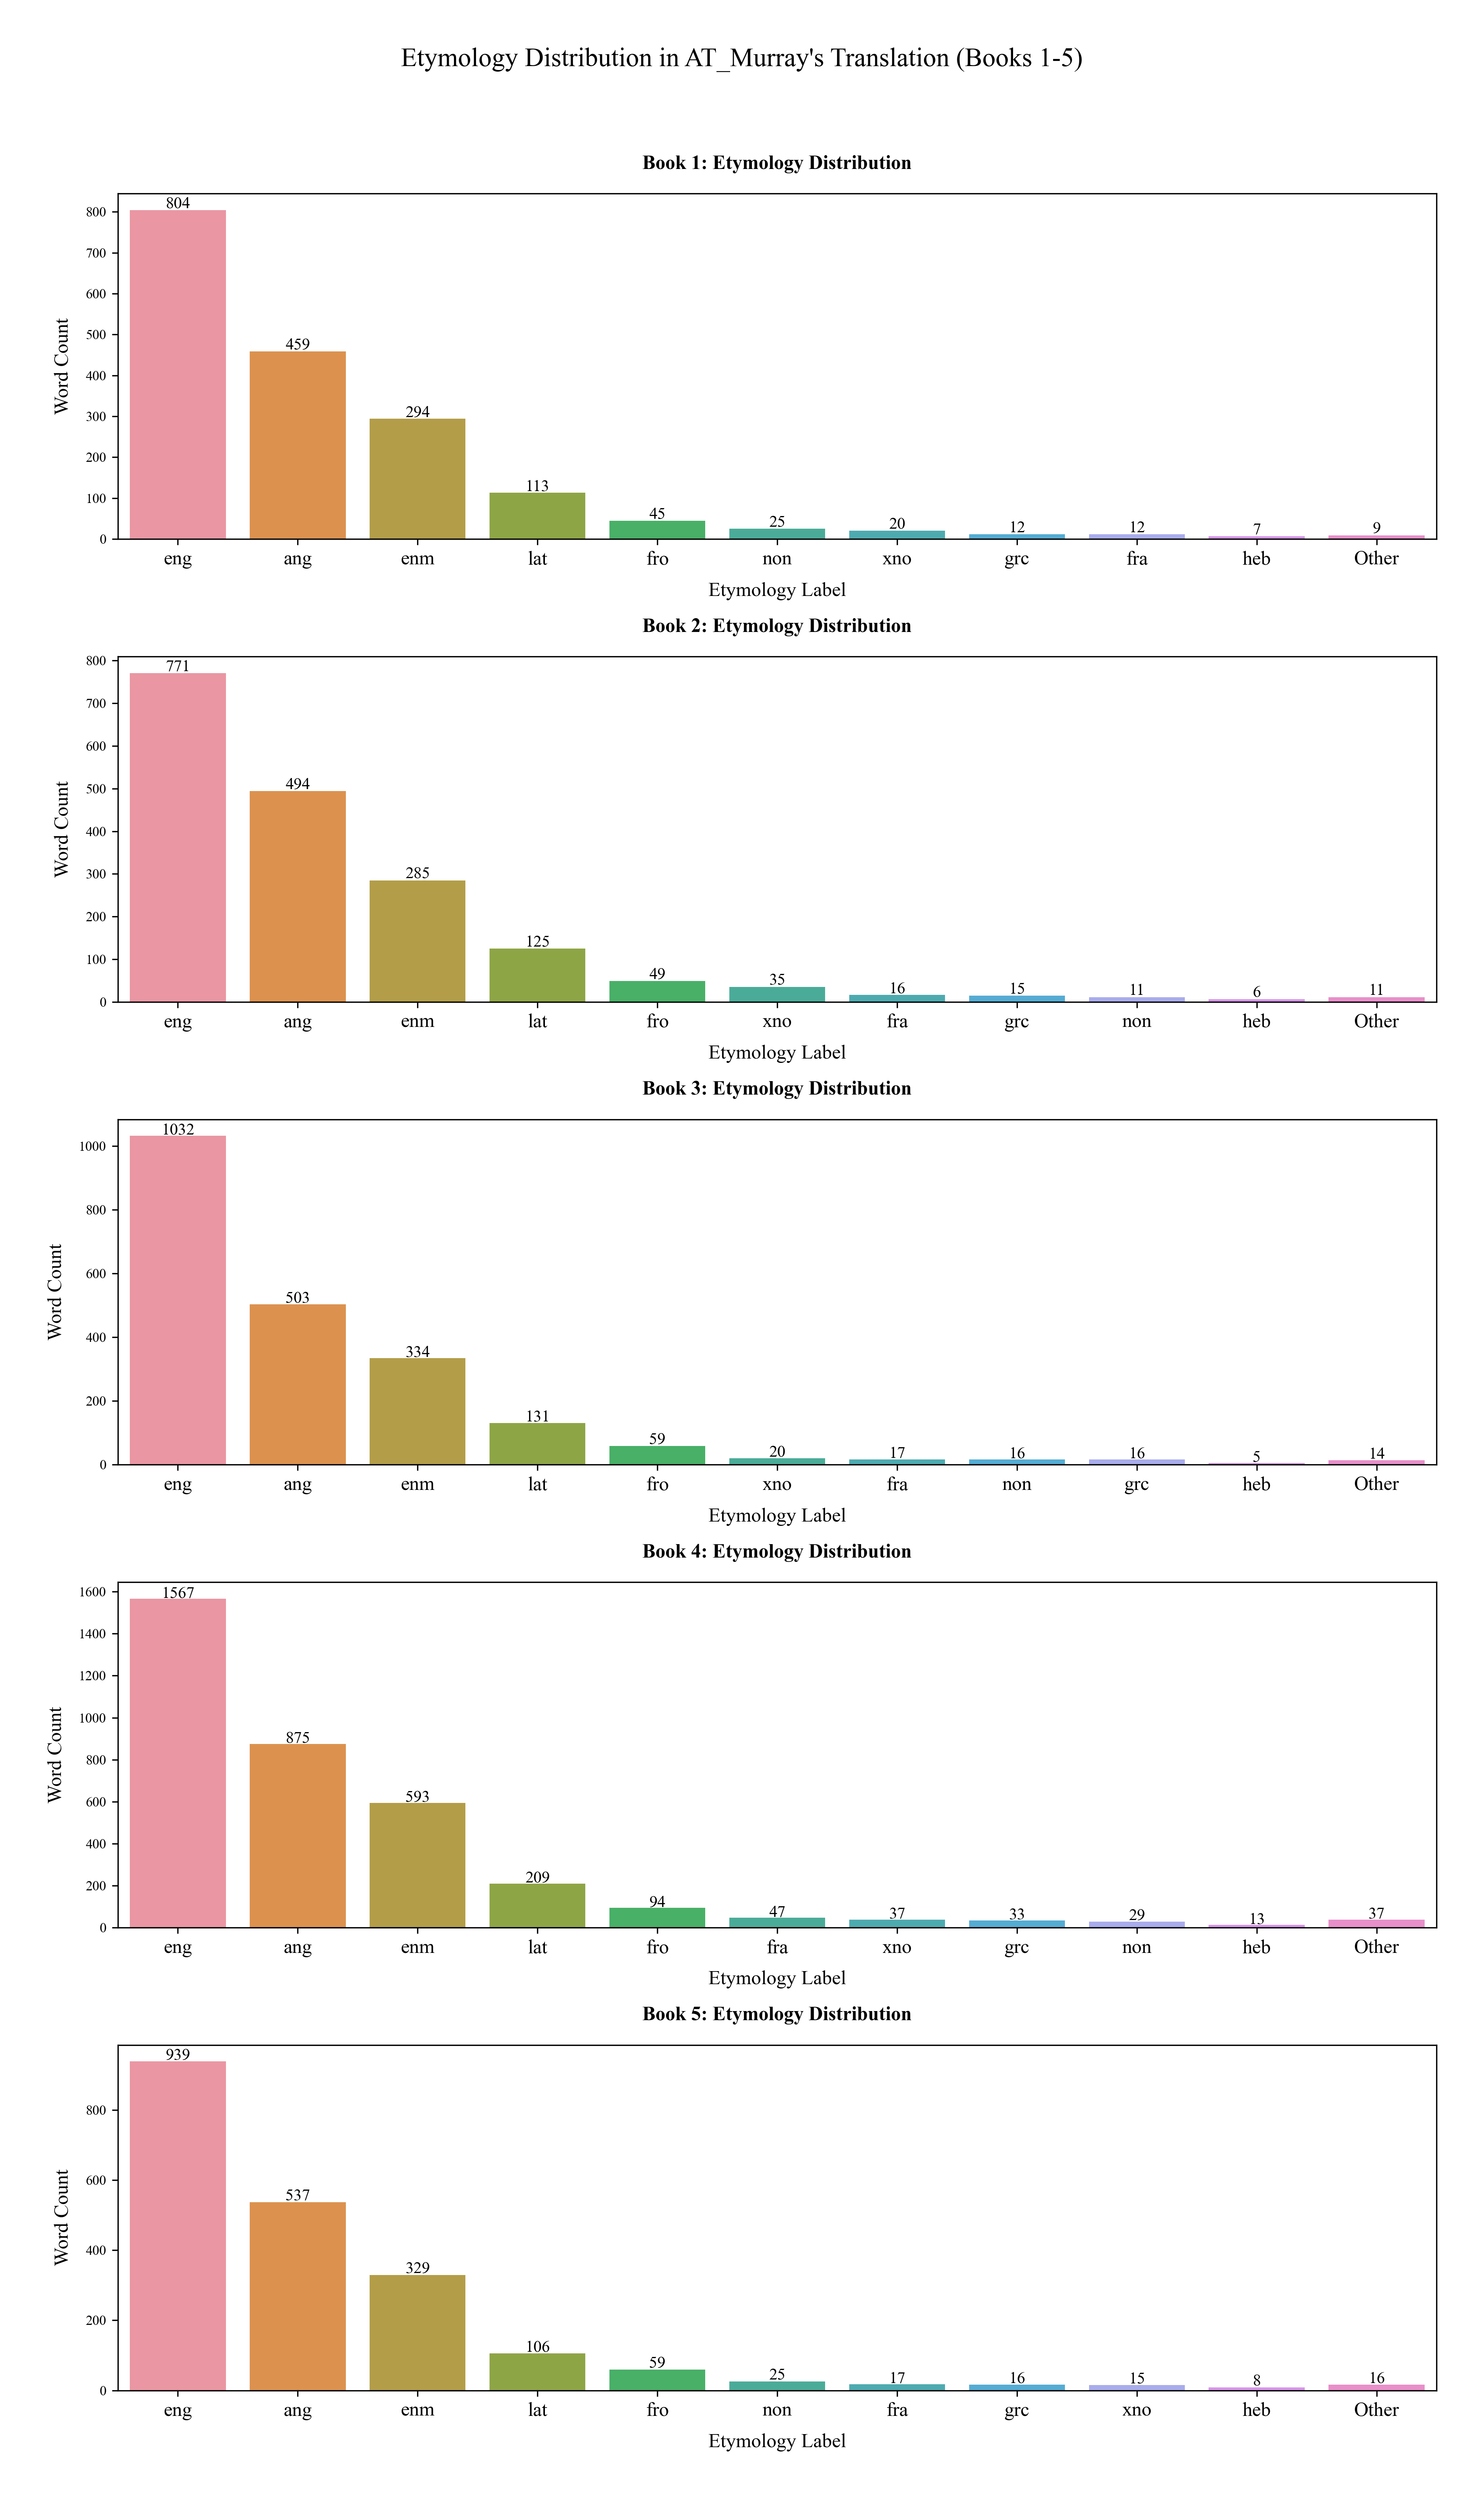

In [13]:
fig = oz.plot_etymology_counts(odysseys_df, "AT_Murray", book_range=(1, 5))

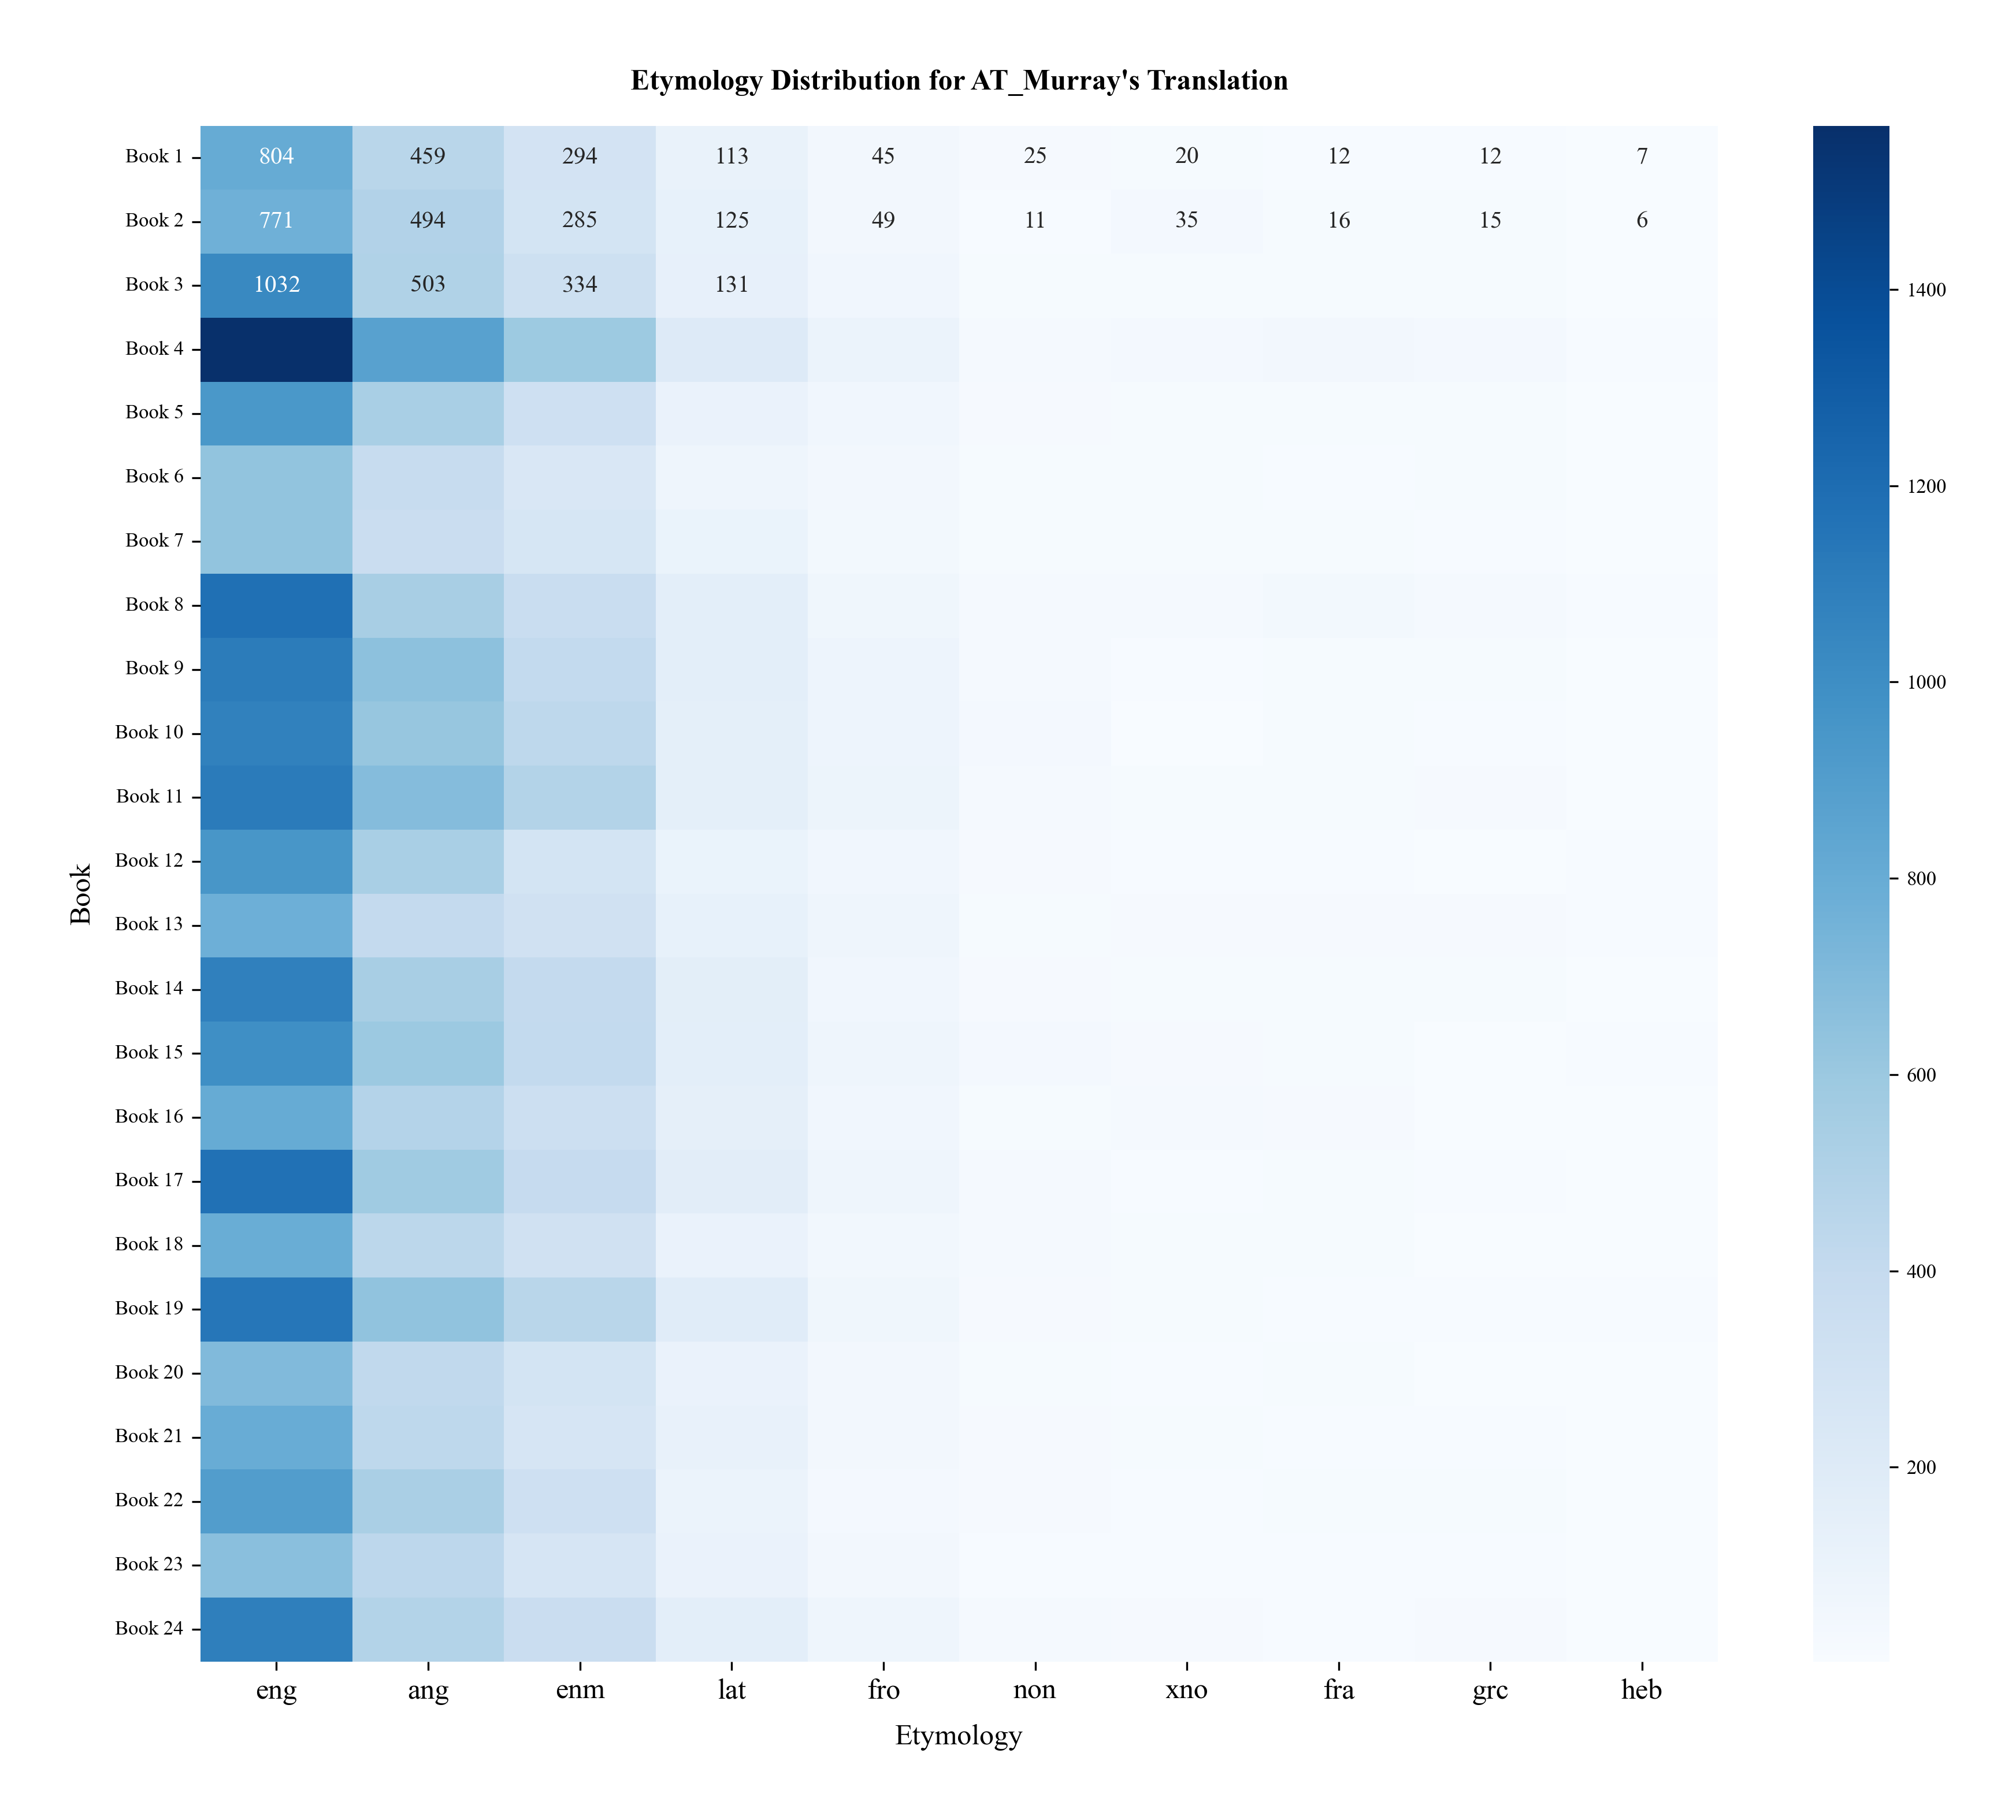

In [14]:
fig = oz.plot_etymology_heatmap(odysseys_df, "AT_Murray", book_range=(1, 24))

In [15]:
at_murray = odysseys_df[odysseys_df['translator'] == 'AT_Murray']
#at_murray_count = at_murray['ety_label_counts'].sum()
e.check_df(at_murray)

Mr righteous here has no missing values!

* df columns: Index(['translator', 'book_num', 'tokens', 'ety_labels', 'ety_label_counts'], dtype='object') 

* Shape: (24, 5) 

* Total memory in MB: 0.863103


In [16]:
Fitzgerald = odysseys_df[odysseys_df['translator'] == 'Fitzgerald']
plot_etymology_counts(Fitzgerald, translator_name='Fitzgerald', book_num=23, top_n=10)

NameError: name 'plot_etymology_counts' is not defined

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

def plot_aggregated_etymologies(df, translator_name='murray', top_n=20):
    """
    Aggregate etymology counts across all books for a specific translator
    and plot the top N most frequent etymologies.
    
    Parameters:
    df (DataFrame): The DataFrame containing the data
    translator_name (str): The name of the translator to filter by
    top_n (int): Number of top etymologies to display
    """
    # Filter for the specific translator
    translator_data = df[df['translator'] == translator_name]
    
    if len(translator_data) == 0:
        print(f"No data found for translator: {translator_name}")
        print(f"Available translators: {df['translator'].unique()}")
        return
    
    # Aggregate counts across all books
    aggregated_counts = Counter()
    
    for _, row in translator_data.iterrows():
        ety_counts = row['ety_label_counts']
        aggregated_counts.update(ety_counts)
    
    # Convert the aggregated counter to a DataFrame
    agg_df = pd.DataFrame(list(aggregated_counts.items()), columns=['Etymology', 'Count'])
    
    # Sort by count in descending order and get top N
    agg_df = agg_df.sort_values('Count', ascending=False).head(top_n)
    
    # Create the plot
    plt.figure(figsize=(14, 8))
    bar_plot = sns.barplot(x='Etymology', y='Count', data=agg_df, palette='viridis')
    
    # Customize the plot
    plt.title(f'Top {top_n} Etymologies in {translator_name.capitalize()}\'s Translation (All Books Combined)')
    plt.xlabel('Etymology Label')
    plt.ylabel('Word Count')
    plt.xticks(rotation=45, ha='right')
    
    # Add count labels on top of bars
    for i, v in enumerate(agg_df['Count']):
        plt.text(i, v + (max(agg_df['Count']) * 0.01), f'{v:,}', ha='center')
    
    # Add percentage labels
    total_words = agg_df['Count'].sum()
    for i, v in enumerate(agg_df['Count']):
        percentage = (v / total_words) * 100
        plt.text(i, v/2, f'{percentage:.1f}%', ha='center', color='white', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    return aggregated_counts

# Example usage
aggregated_counts = plot_aggregated_etymologies(at_murray, translator_name='AT_Murray', top_n=20)

# Optional: Print the total number of words analyzed
if aggregated_counts:
    total_words = sum(aggregated_counts.values())
    print(f"Total words analyzed: {total_words:,}")
    
    # Calculate and display etymology diversity metrics
    print(f"Number of distinct etymologies: {len(aggregated_counts)}")
    
    # Calculate percentage of words from the top 3 etymologies
    top_3 = sum(count for _, count in aggregated_counts.most_common(3))
    print(f"Percentage of words from top 3 etymologies: {(top_3/total_words)*100:.2f}%")